In [44]:
import os
import sys
import flavio
import flavio.plots
import flavio.statistics.likelihood
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import logging
from mpl_toolkits.axes_grid1 import make_axes_locatable
from flavio.physics.bdecays.bvll import observables, observables_bs
from flavio.physics.bdecays.bvll.observables_bs import definite_int_cosh, definite_int_cos, definite_int_sinh, definite_int_sin
from numpy.typing import NDArray
emtf_dir = os.path.expandvars('$BSTOPHIMUMUTD')
disk_dir = os.path.expandvars('$DISKEMTF')
sys.path.append(emtf_dir)
mpl.rc_file('schmitse-rc.rc')
logging.getLogger('matplotlib.texmanager').setLevel(logging.WARNING)

## observables class in flavio has method jfunc, which expects a function of the J, J_bar obs we want to access, make dummy function to do this
def get_vector_of_all_Js(J,J_bar):
    return J,J_bar
def get_vector_of_all_Js_h_and_s(y, x, gamma, J, J_bar, J_h, J_s):
    return y, x, J, J_bar, J_h, J_s

## function that does all the work
def S_funcs(num):
    return lambda wc_obj, par, q2min, q2max: flavio.physics.bdecays.bvll.observables.BVll_int_ratio(
        lambda J, J_bar: flavio.physics.bdecays.bvll.observables.S_experiment_num(J, J_bar, num),
        flavio.physics.bdecays.bvll.observables.SA_den,
        q2min, q2max, B, V, l, wc_obj, par)()
def A_funcs(num):
    return lambda wc_obj, par, q2min, q2max: flavio.physics.bdecays.bvll.observables.BVll_int_ratio(
        lambda J, J_bar: flavio.physics.bdecays.bvll.observables.A_experiment_num(J, J_bar, num),
        flavio.physics.bdecays.bvll.observables.SA_den,
        q2min, q2max, B, V, l, wc_obj, par)()
    
def S_bs_funcs(num):
    return lambda wc_obj, par, q2min, q2max: flavio.physics.bdecays.bvll.observables_bs.BsVll_int_ratio(
        lambda J, J_bar, J_h, J_s: flavio.physics.bdecays.bvll.observables_bs.S_experiment_num_Bs(par['DeltaGamma/Gamma_'+B]/2., par['DeltaM/Gamma_'+B], J, J_bar, J_h, J_s, num),
        lambda J, J_bar, J_h, J_s: flavio.physics.bdecays.bvll.observables_bs.SA_den_Bs(par['DeltaGamma/Gamma_'+B]/2., par['DeltaM/Gamma_'+B], J, J_bar, J_h, J_s),
        q2min, q2max, B, V, l, wc_obj, par)()
def A_bs_funcs(num):
    return lambda wc_obj, par, q2min, q2max: flavio.physics.bdecays.bvll.observables_bs.BsVll_int_ratio(
        lambda J, J_bar, J_h, J_s: flavio.physics.bdecays.bvll.observables_bs.A_experiment_num_Bs(par['DeltaGamma/Gamma_'+B]/2., par['DeltaM/Gamma_'+B], J, J_bar, J_h, J_s, num),
        lambda J, J_bar, J_h, J_s: flavio.physics.bdecays.bvll.observables_bs.SA_den_Bs(par['DeltaGamma/Gamma_'+B]/2., par['DeltaM/Gamma_'+B], J, J_bar, J_h, J_s),
        q2min, q2max, B, V, l, wc_obj, par)()

INFO:matplotlib:
*****************************************************************
You have the following UNSUPPORTED LaTeX preamble customizations:
\
u
s
e
p
a
c
k
a
g
e
{
a
m
s
m
a
t
h
}
Please do not ask for support with these customizations active.
*****************************************************************



In [2]:
###bootstrap parameters and set wilson coefficients, for now SM
debug = False
td = True
par_orig = flavio.default_parameters.get_central_all()
wc_obj = flavio.WilsonCoefficients()
nbs = 100
N_bootstrap = 1 if debug else int(nbs)
par_random = flavio.default_parameters.get_random_all(size=N_bootstrap)
par_random = [{k: v[i] for k, v in par_random.items()} for i in range(N_bootstrap)]
B = "Bs"
V = "phi"
l = "mu"
channel = 'B0ToKpKmMuMu'

### Comparison between BVLL  ans BsVLL when setting x and y to zero
The two approaches should provide the same result

/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/qcdf_interpolate.py:33: UserWarning: The QCDF corrections should not be trusted for q2 above 6 GeV^2
  warnings.warn("The QCDF corrections should not be trusted for q2 above 6 GeV^2")
/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/amplitudes.py:74: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/amplitudes.py:83: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/schmitse/flavio-bsphimumu-fork/flavio/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imagina

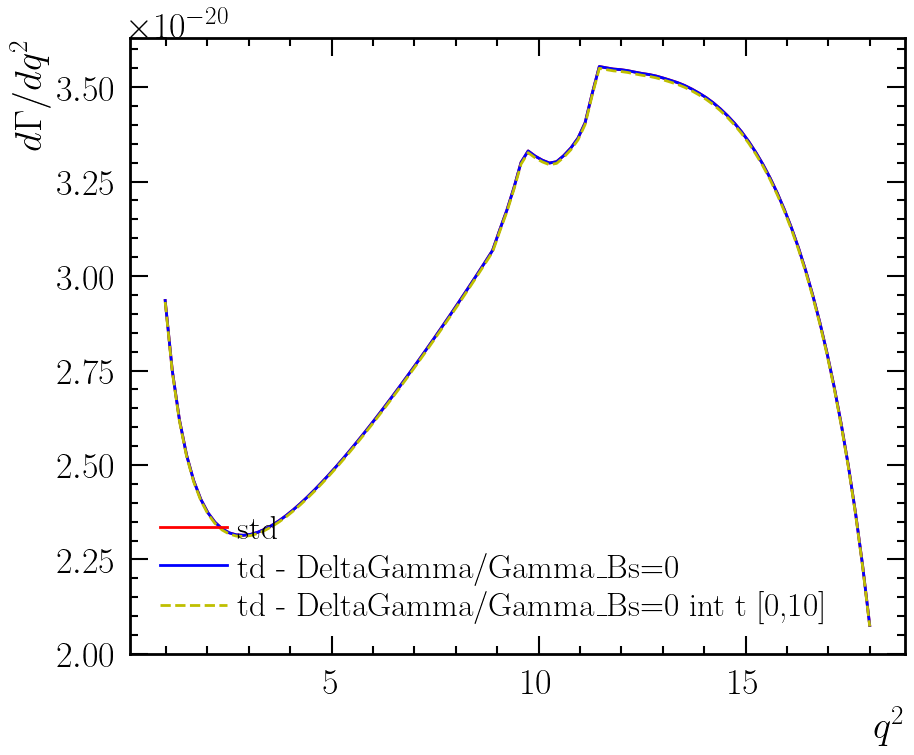

In [3]:
#start studying it in an unbinned way using test_bvll as an example
par_y0 = par_orig.copy()
par_y0['DeltaGamma/Gamma_Bs']=0
par_y0['DeltaM/Gamma_Bs']=0
q2_min, q2_max = 0.98, 18
npoints = 100
q2_arr = np.linspace(q2_min, q2_max, npoints)

dGd2_ave_std = np.array([observables.BVll_obs(observables.dGdq2_ave, q2, B, V, l, wc_obj, par_y0)() for q2 in q2_arr])
dGd2_ave_td = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_ave_Bs, q2, wc_obj, par_y0, B, V, l) for q2 in q2_arr])
tmin, tmax = 0, 10
dGd2_ave_int_t_td = np.array([observables_bs.bsvll_obs_int_t(observables_bs.dGdq2_ave_int_t_Bs, tmin, tmax, q2, wc_obj, par_y0, B, V, l) for q2 in q2_arr])

plt.close('all')
plt.plot(q2_arr, dGd2_ave_std, label='std', color='r')
plt.plot(q2_arr, dGd2_ave_td, label='td - DeltaGamma/Gamma_Bs=0', color='b')
plt.plot(q2_arr, dGd2_ave_int_t_td, label=f'td - DeltaGamma/Gamma_Bs=0 int t [{tmin},{tmax}]', color='y', linestyle='dashed')
plt.legend(frameon=False)
plt.xlabel(r'$q^2$')
plt.ylabel(r'$d\Gamma/dq^2$')
plt.show()


/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/qcdf_interpolate.py:33: UserWarning: The QCDF corrections should not be trusted for q2 above 6 GeV^2
  warnings.warn("The QCDF corrections should not be trusted for q2 above 6 GeV^2")
/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/amplitudes.py:74: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/amplitudes.py:83: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")


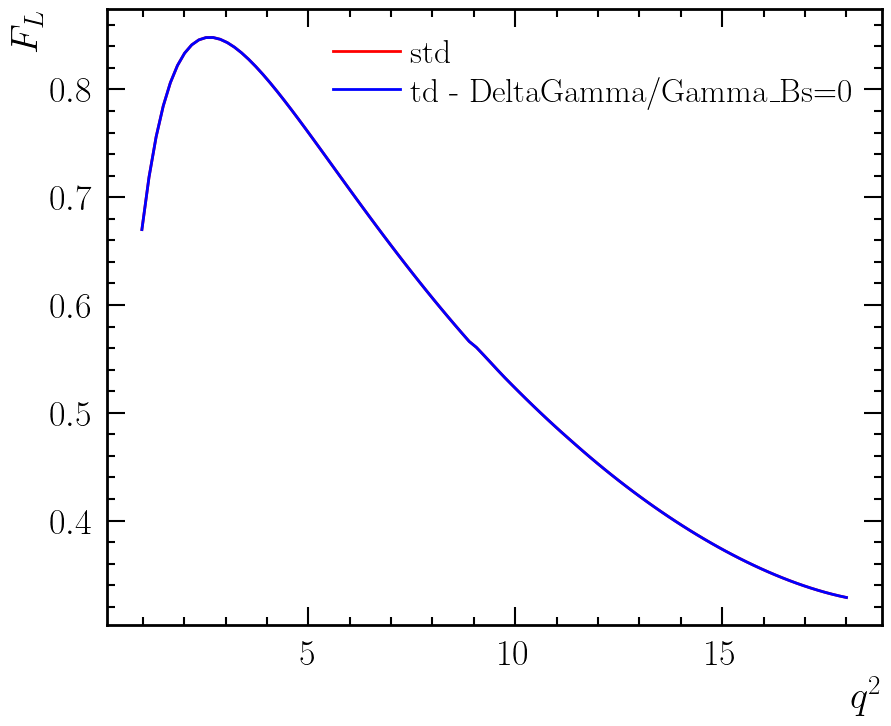

In [4]:
FL_std = np.array([observables.BVll_obs(observables.FL, q2, B, V, l, wc_obj, par_y0)() for q2 in q2_arr])
FL_td = np.array([observables_bs.bsvll_obs( observables_bs.FL_Bs, q2, wc_obj, par_y0, B, V, l) for q2 in q2_arr])

plt.close('all')
plt.plot(q2_arr, FL_std, label='std', color='r')
plt.plot(q2_arr, FL_td, label='td - DeltaGamma/Gamma_Bs=0', color='b')
plt.legend(frameon=False)
plt.xlabel(r'$q^2$')
plt.ylabel(r'$F_L$')
plt.show()

#### S-observables

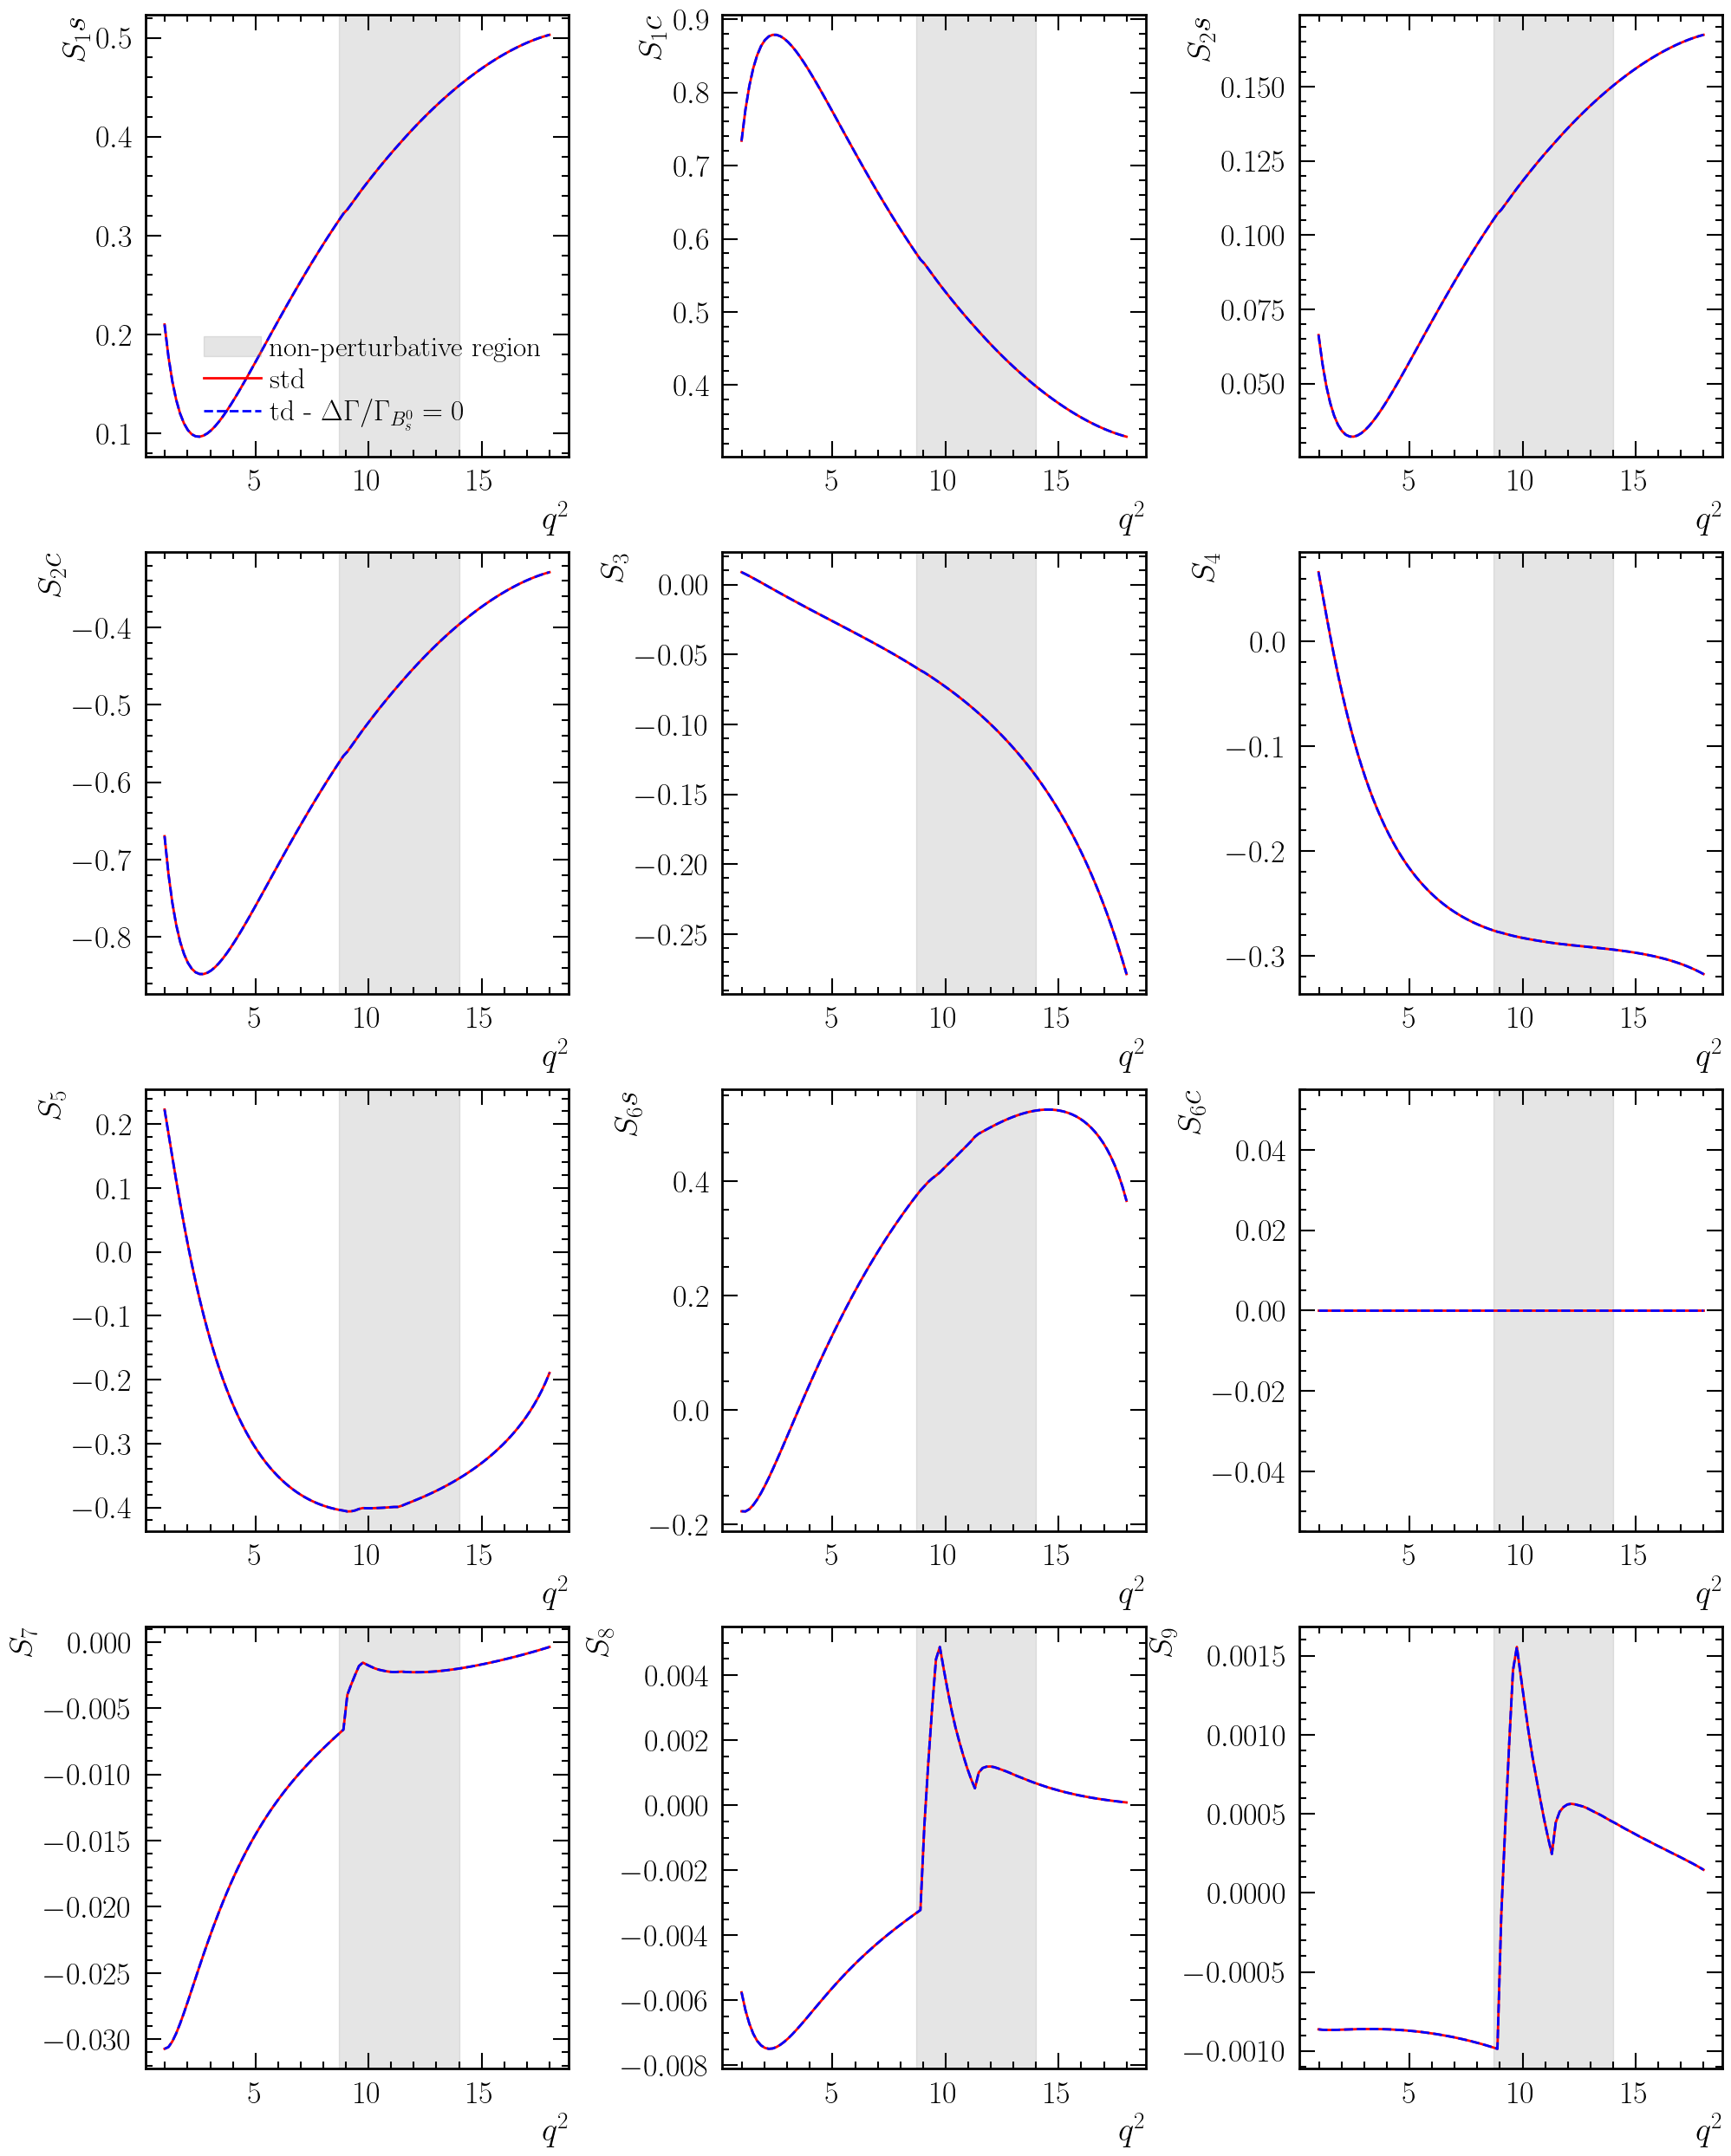

In [5]:
fig, axs = plt.subplots(4, 3, figsize=(20, 25))
for j, iobs in enumerate(['1s','1c','2s','2c',3,4,5,'6s','6c',7,8,9]):
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.S_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_y0)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_y0, B, V, l) for q2 in q2_arr])
    ax = axs[j//3, j%3]
    #plt.close('all')
    ax.axvspan(8.7, 14, color='gray', alpha=0.2, label='non-perturbative region')
    ax.plot(q2_arr, FL_std, label='std', color='r')
    ax.plot(q2_arr, FL_td, label='td - $\Delta\Gamma/\Gamma_{B_s^0}=0$', color='b', linestyle='dashed')
    if not j:
        ax.legend()
    ax.set_xlabel(r'$q^2$')
    ax.set_ylabel(f'$S_{iobs}$')
plt.tight_layout()
plt.show()

#### A-observables

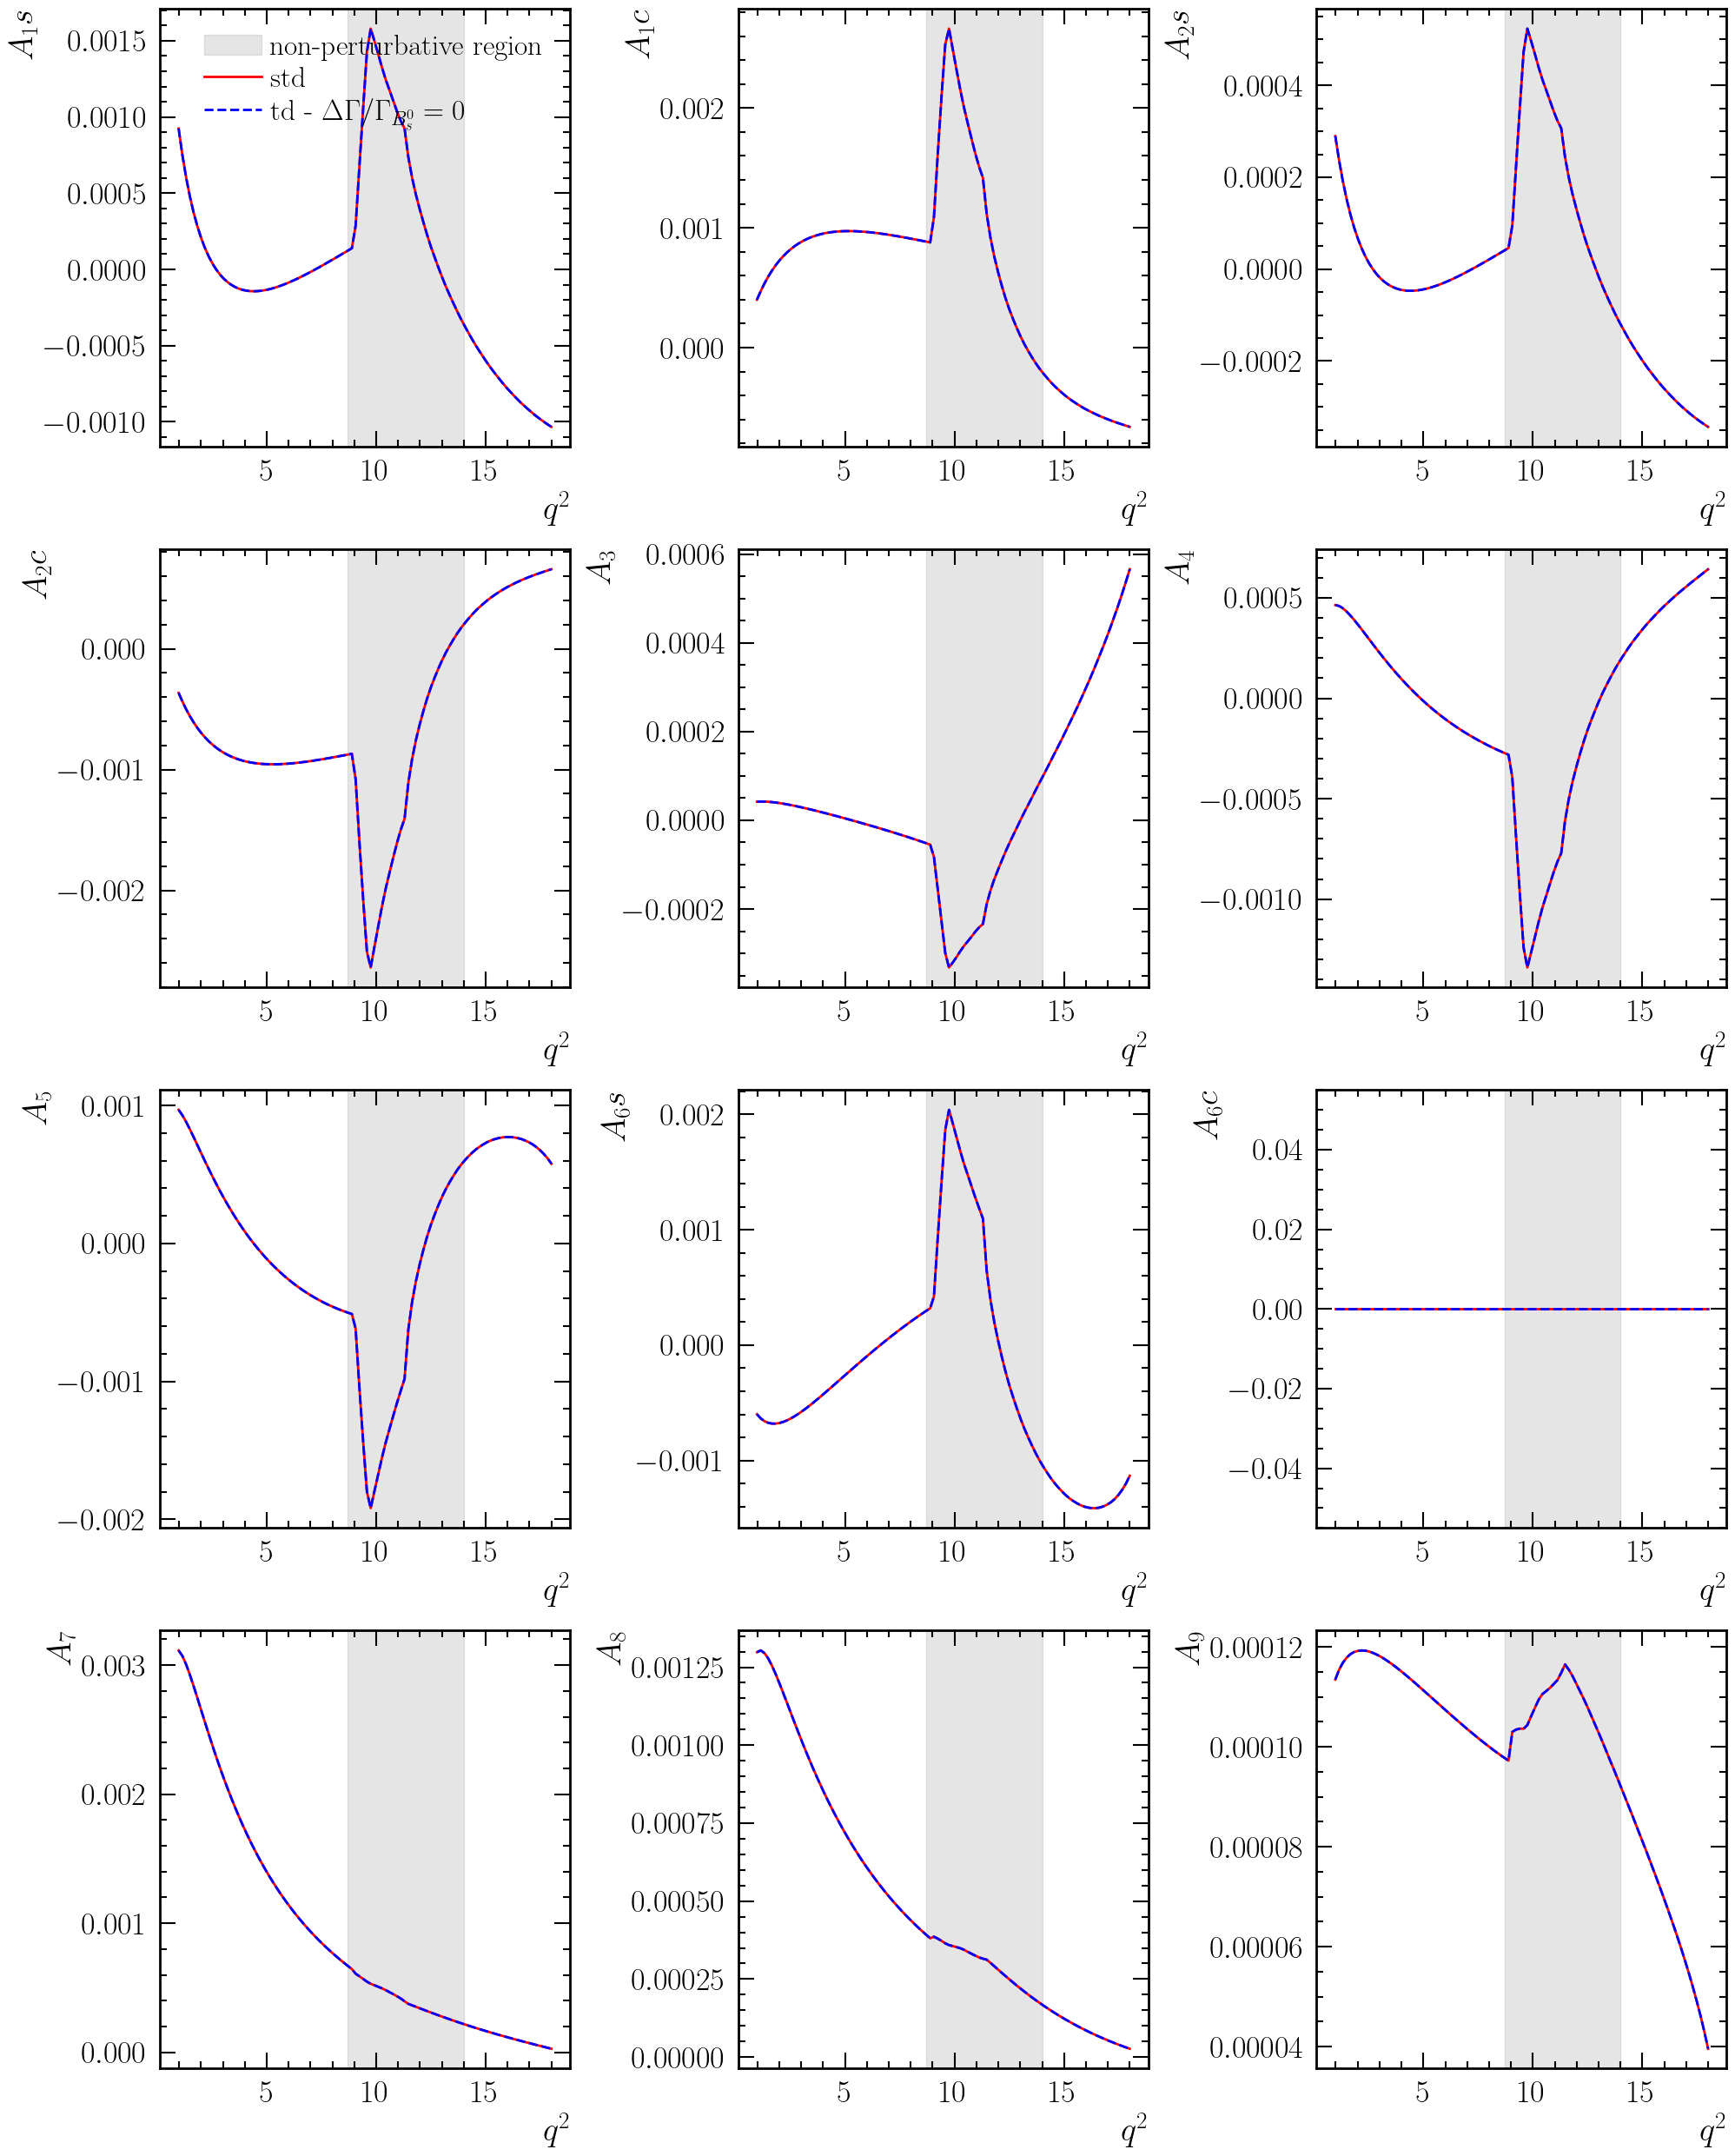

In [6]:
fig, axs = plt.subplots(4, 3, figsize=(20, 25))
for j, iobs in enumerate(['1s','1c','2s','2c',3,4,5,'6s','6c',7,8,9]):
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.A_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_y0)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_y0, B, V, l) for q2 in q2_arr])

    ax = axs[j//3, j%3]
    ax.axvspan(8.7, 14, color='gray', alpha=0.2, label='non-perturbative region')
    ax.plot(q2_arr, FL_std, label='std', color='r')
    ax.plot(q2_arr, FL_td, label='td - $\Delta\Gamma/\Gamma_{B_s^0}=0$', color='b', linestyle='dashed')
    if not j:
        ax.legend()
    ax.set_xlabel(r'$q^2$')
    ax.set_ylabel(f'$A_{iobs}$')
plt.tight_layout()
plt.show()

In [7]:
#par_phi0 = par_orig.copy()
#par_phi0
#2*M12-1j*G12 = 0
#[i for i in par_phi0.items() if "Gamma12" in i[0]]
#[i for i in par_phi0.items() if "CVLL" in i[0]]

### What would happen if q/p would be real - WIP

In [7]:
test = True
if test:
    par_phi0 = par_orig.copy()
    par_phi0['Gamma12_Bs_c']=-0.9373957776777209*1e4
    par_phi0['Gamma12_Bs_a']=-2/0.01798378912034765*1e4
    q_over_p = flavio.physics.mesonmixing.observables.q_over_p(wc_obj, par_phi0, B)
    print(q_over_p)
    M12, G12 = flavio.physics.mesonmixing.observables.get_M12_G12(wc_obj, par_phi0, B)
    print(M12, 1j*G12)
    print(2*M12-1j*G12)

(-2151608.5414372273+118844224.1942178j)
(5.7027480156310755e-12-2.0655786206282665e-13j) (1.1405496031262153e-11-4.131157241256533e-13j)
(-1.6155871338926322e-27+0j)


/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/qcdf_interpolate.py:33: UserWarning: The QCDF corrections should not be trusted for q2 above 6 GeV^2
  warnings.warn("The QCDF corrections should not be trusted for q2 above 6 GeV^2")
/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/amplitudes.py:74: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/amplitudes.py:83: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/qcdf_interpolate.py:33: UserWarning: The QCDF corrections should not be trusted for q2 above 6 GeV^2

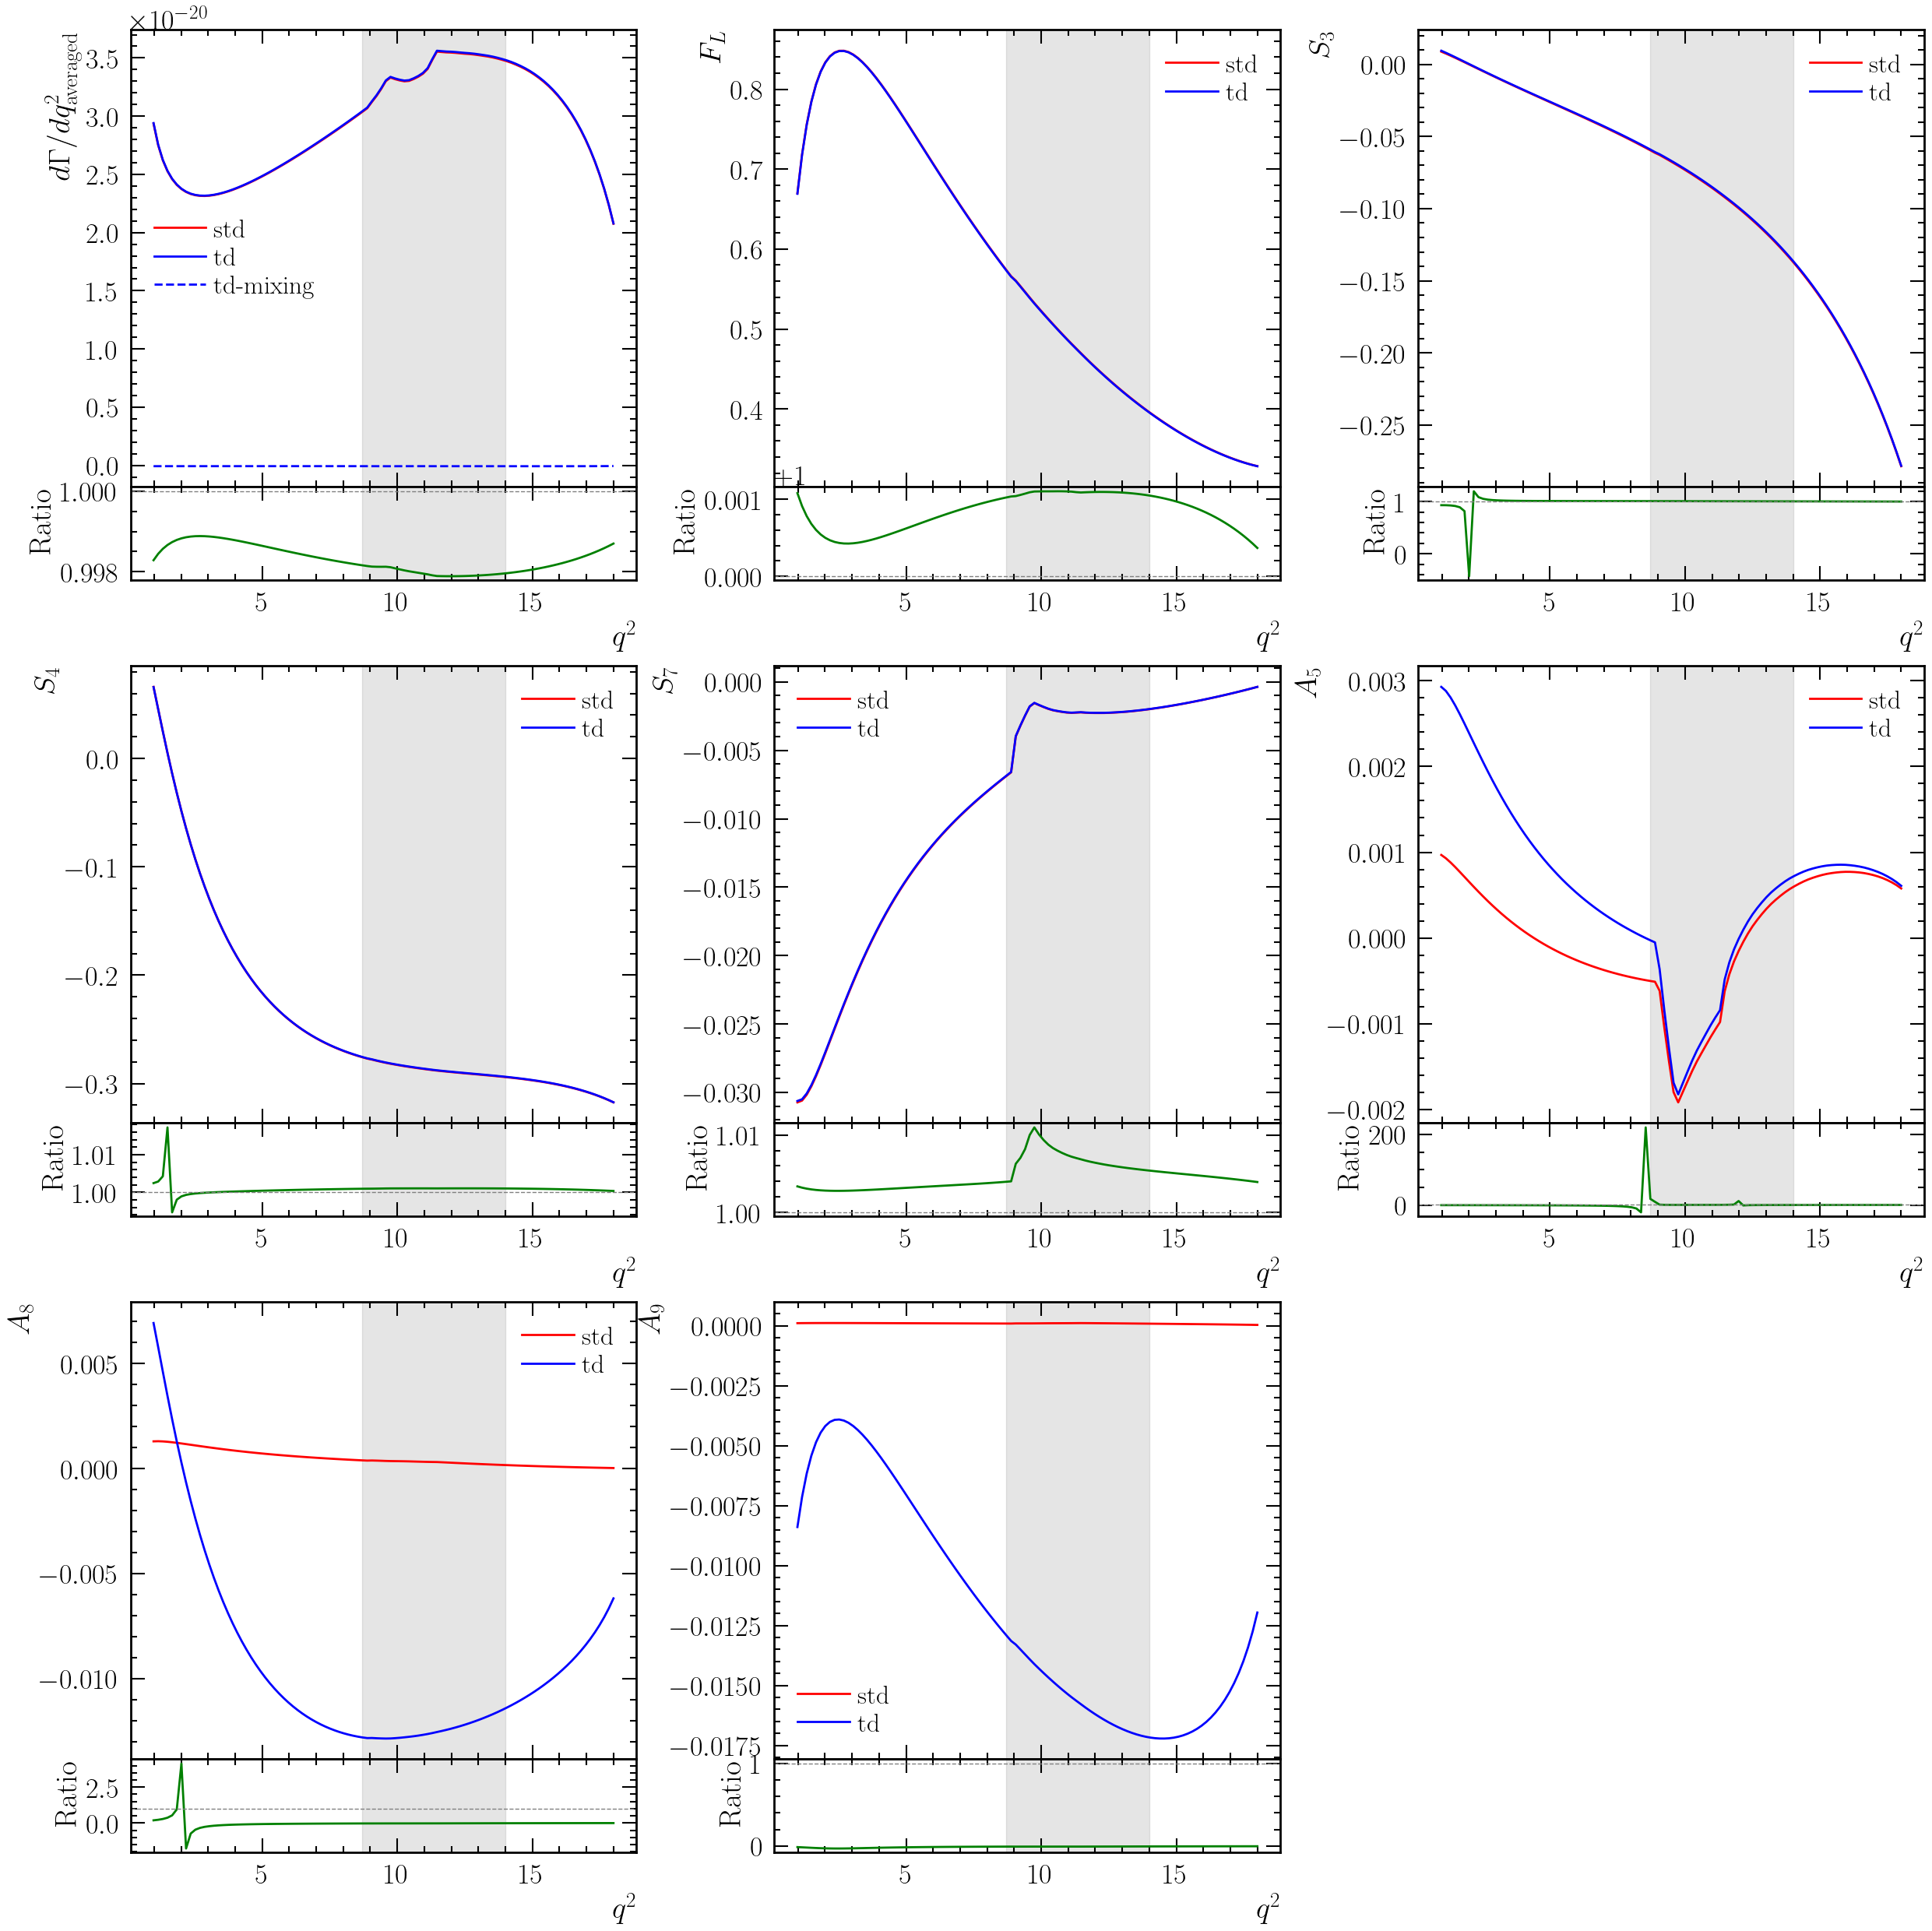

In [39]:
def plot_qsq_dg(qsq: NDArray, dgammas: list[NDArray], labels: list[str], 
                colors: list[str] | None, linestyles: list[str] | None,
                ylabel: str = r'$d\Gamma/dq^2_{\mathrm{averaged}}$',
                xlabel: str = r'$q^2$', shade: bool = True, ax: None = None,
                ratio_plot: bool = True) -> None:
    assert len(dgammas) == len(labels), "Number of dgammas must match number of labels"
    assert len(dgammas) > 1, "At least two dgammas are required for ratio plot"
    if ax is None:
        _, ax1 = plt.subplots()
    else:
        ax1 = ax
    if colors is None:
        cmap = plt.get_cmap('tab10')
        norm = mpl.colors.Normalize(vmin=0, vmax=len(dgammas))
        colors = [cmap(norm(i)) for i in range(len(dgammas))]
    if linestyles is None:
        linestyles = ['-' for _ in dgammas]
    # Main plot
    for dgamma, label, color, linestyle in zip(dgammas, labels, colors, linestyles):
        ax1.plot(qsq, dgamma, label=label, color=color, linestyle=linestyle)
    ax1.legend()
    ax1.set_ylabel(ylabel)
    ax1.set_xlabel(xlabel)

    # Ratio plot
    if ratio_plot:
        ax1.set_xlabel('') # remove the labels which would overlap with the ratio plot
        ax1.set_xticks([tick for tick in ax1.get_xticks()])
        ax1.set_xticklabels(['' for tick in ax1.get_xticks()])
        divider = make_axes_locatable(ax1)
        ax2 = divider.append_axes('bottom', 1.2, pad=0.0)
        mask = np.isfinite(dgammas[0]) & np.isfinite(dgammas[1])
        ratio = dgammas[0] / dgammas[1]
        ax2.plot(qsq[mask], ratio[mask], label='Ratio (std/td)', color='g')
        ax2.set_xlabel(xlabel)
        ax2.set_ylabel('Ratio')
        ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

    if shade:
        # Shade the non-perturbative region
        ax1.axvspan(8.7, 14, color='gray', alpha=0.2)
        if ratio_plot:
            ax2.axvspan(8.7, 14, color='gray', alpha=0.2)

    # Adjust layout to avoid overlap
    if ax is None:
        plt.show()

if test:
    #start studying it in an unbinned way using test_bvll as an example
    q2_min, q2_max = 0.98, 18
    npoints = 100
    q2_arr = np.linspace(q2_min, q2_max, npoints)

    fig, axs = plt.subplots(3, 3, figsize=(25, 25))

    dGd2_ave_std = np.array([observables.BVll_obs(observables.dGdq2_ave, q2, B, V, l, wc_obj, par_phi0)() for q2 in q2_arr])
    dGd2_ave_td = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_ave_Bs, q2, wc_obj, par_phi0, B, V, l) for q2 in q2_arr])
    dGd2_interference_td = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_interference_Bs, q2, wc_obj, par_phi0, B, V, l) for q2 in q2_arr])

    plt.close('all')
    plot_qsq_dg(q2_arr, [dGd2_ave_std, dGd2_ave_td, dGd2_interference_td],
                labels=['std', 'td', 'td-mixing'],
                colors=['r', 'b', 'b'],
                linestyles=['-', '-', 'dashed'], ax=axs[0, 0])

    FL_std = np.array([observables.BVll_obs(observables.FL, q2, B, V, l, wc_obj, par_phi0)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( observables_bs.FL_Bs, q2, wc_obj, par_phi0, B, V, l) for q2 in q2_arr])

    plot_qsq_dg(q2_arr, [FL_std, FL_td],
                labels=['std', 'td'],
                colors=['r', 'b'],
                linestyles=['-', '-'],
                ylabel=r'$F_L$',
                xlabel=r'$q^2$', ax=axs[0, 1])

    for j, iobs in enumerate([3, 4, 7]):
        obs_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.S_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_phi0)() for q2 in q2_arr])
        obs_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_phi0, B, V, l) for q2 in q2_arr])

        plot_qsq_dg(q2_arr, [obs_std, obs_td],
                    labels=['std', 'td'],
                    colors=['r', 'b'],
                    linestyles=['-', '-'],
                    ylabel=f'$S_{iobs}$',
                    xlabel=r'$q^2$', ax=axs[(j+2)//3, (j+2)%3])
        
    for j, iobs in enumerate([5, 8, 9]):
        obs_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.A_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_phi0)() for q2 in q2_arr])
        obs_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_phi0, B, V, l) for q2 in q2_arr])

        plot_qsq_dg(q2_arr, [obs_std, obs_td],
                    labels=['std', 'td'],
                    colors=['r', 'b'],
                    linestyles=['-', '-'],
                    ylabel=f'$A_{iobs}$',
                    xlabel=r'$q^2$', ax=axs[(j+5)//3, (j+5)%3])
    axs[2, 2].remove() 
    fig.tight_layout()
fig

In [40]:
if test:
    #start studying it in an unbinned way using test_bvll as an example
    q2_min, q2_max = 0.98, 18
    npoints = 100
    q2_arr = np.linspace(q2_min, q2_max, npoints)

    js_std = np.array([observables.BVll_obs(get_vector_of_all_Js, q2, B, V, l, wc_obj, par_phi0)() for q2 in q2_arr])
    js_td = np.array([observables_bs.bsvll_obs(get_vector_of_all_Js_h_and_s, q2, wc_obj, par_phi0, B, V, l) for q2 in q2_arr])


/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/qcdf_interpolate.py:33: UserWarning: The QCDF corrections should not be trusted for q2 above 6 GeV^2
  warnings.warn("The QCDF corrections should not be trusted for q2 above 6 GeV^2")
/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/amplitudes.py:74: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/amplitudes.py:83: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")


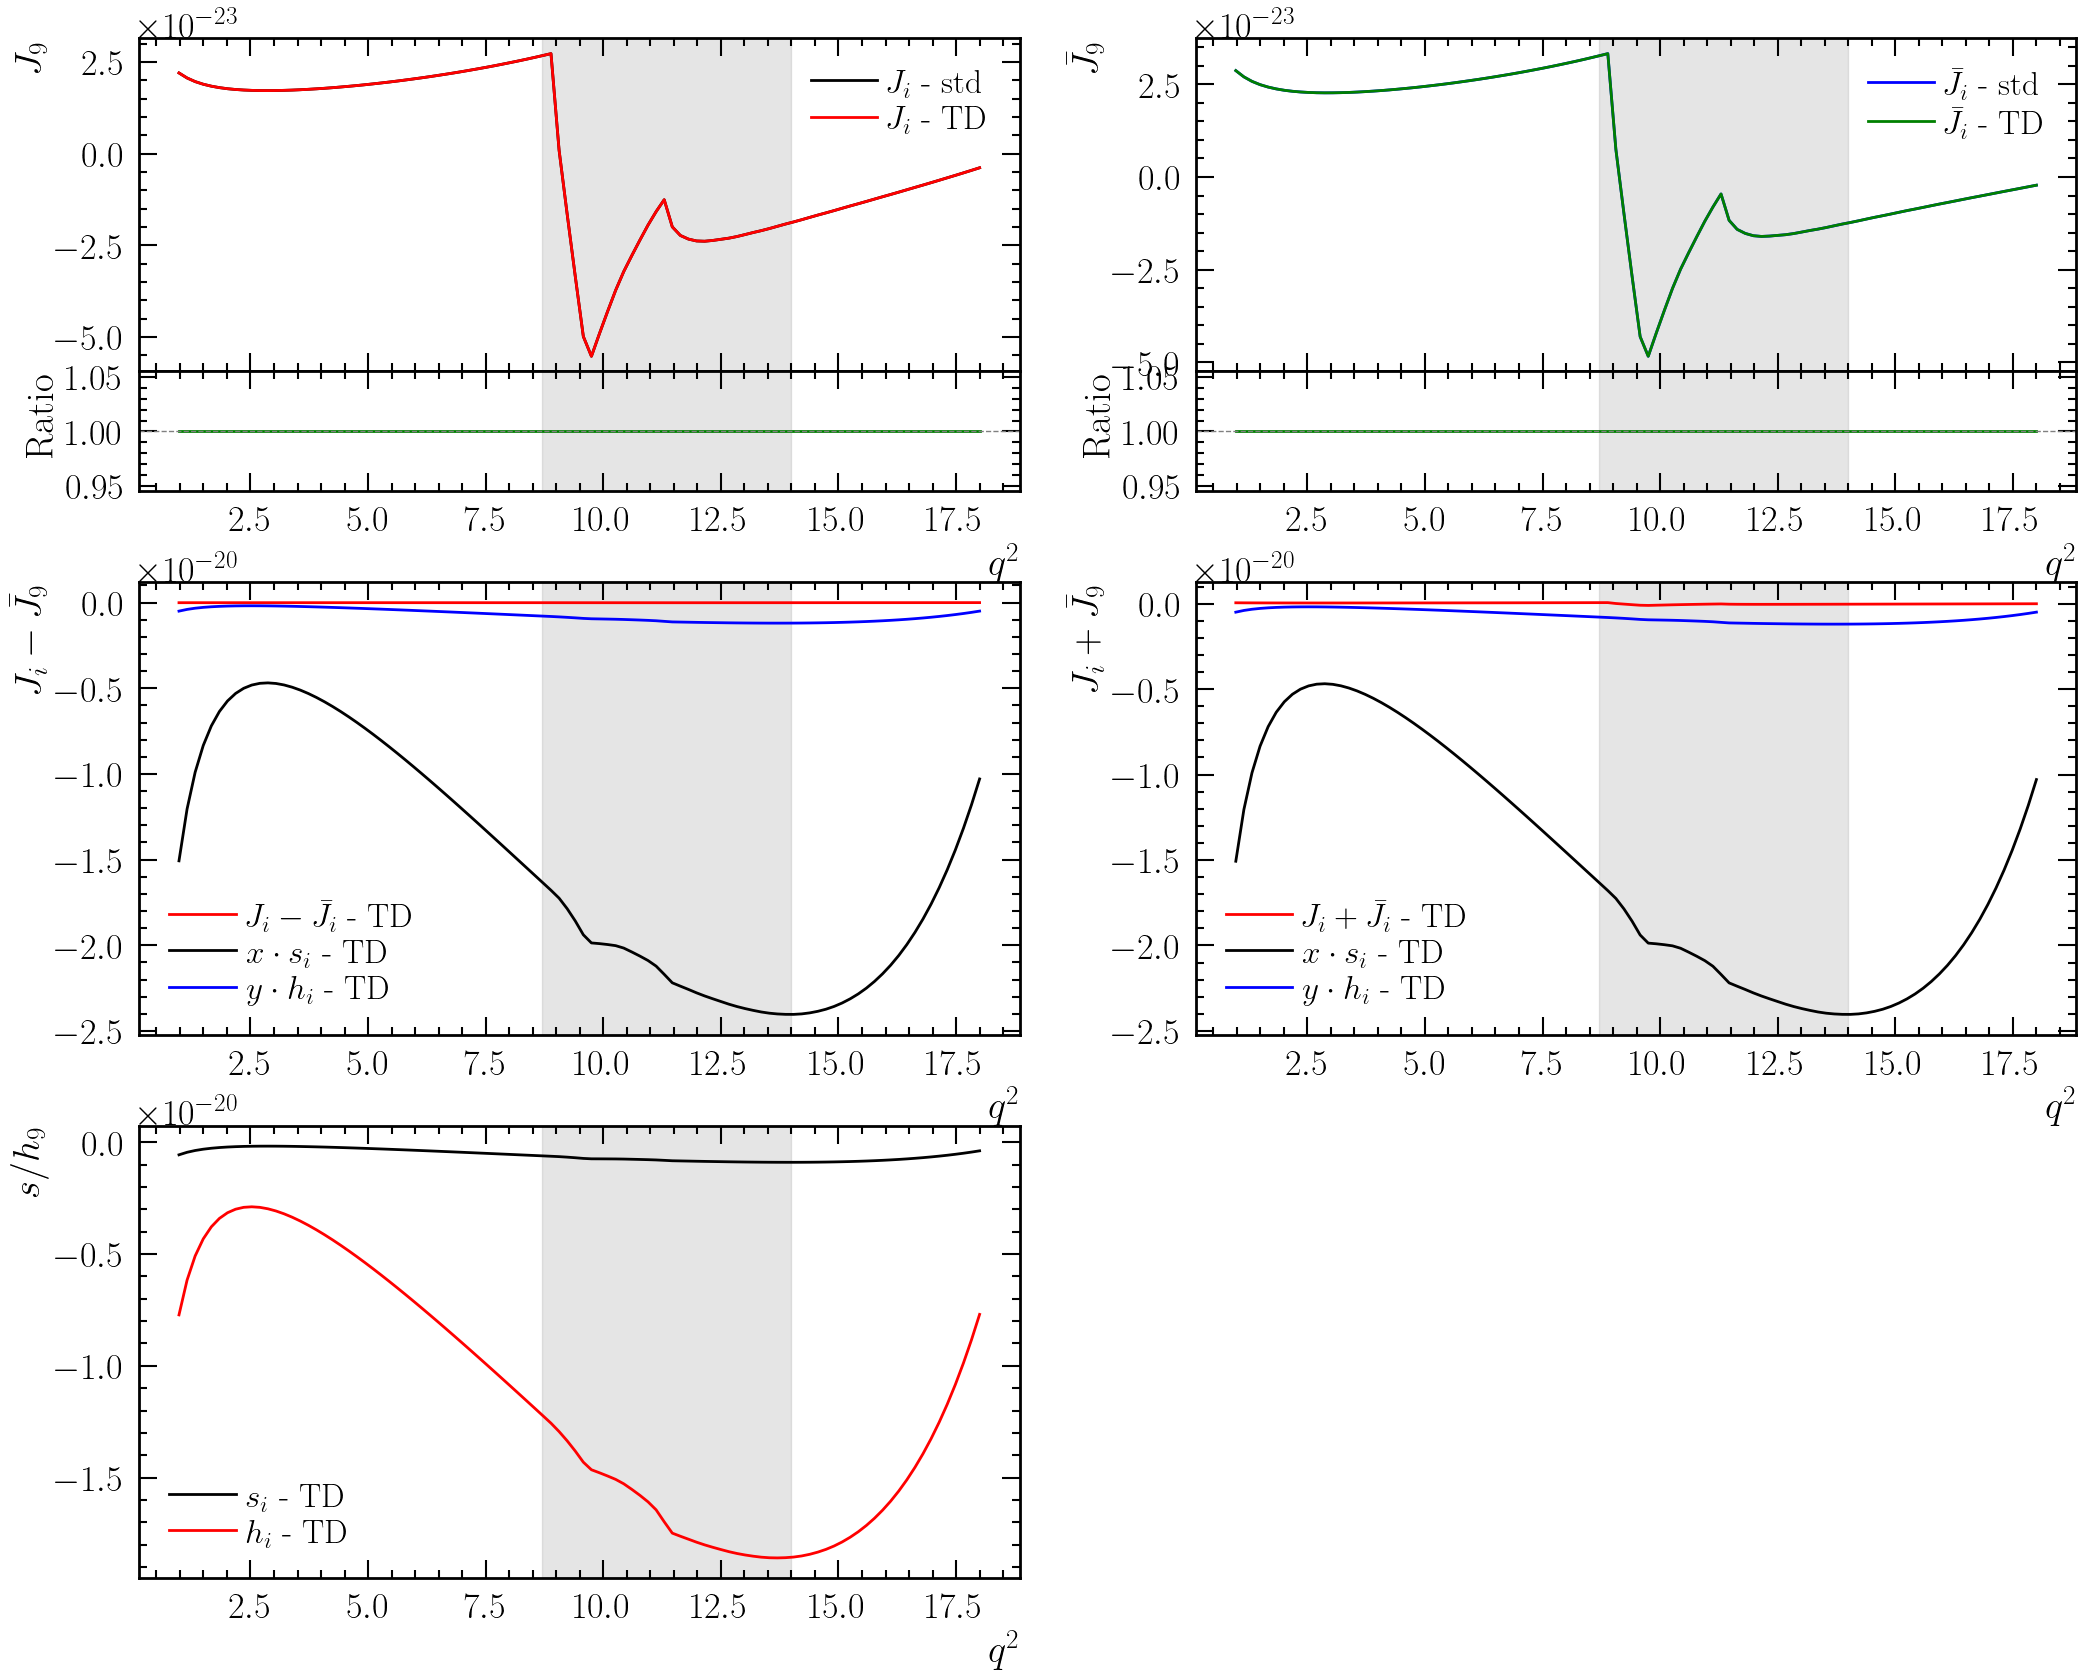

In [43]:
if test:
    y = 0.0645
    x = 26.79
    for num in [9]:
        j_std, jbar_std  = [], []
        j_td, jbar_td, j_h_td, j_s_td   = [], [], [] ,[]

        for arr in js_std:
            j_std.append(arr[0][num])
            jbar_std.append(arr[1][num])
        for arr in js_td:
            j_td.append(arr[2][num])
            jbar_td.append(arr[3][num])
            j_h_td.append(arr[4][num])
            j_s_td.append(arr[5][num])
        j_std = np.asarray(j_std)
        jbar_std = np.asarray(jbar_std)
        j_td = np.asarray(j_td)
        jbar_td = np.asarray(jbar_td)
        j_h_td = np.asarray(j_h_td)
        j_s_td = np.asarray(j_s_td)

        plt.close('all')
        fig, axs = plt.subplots(3, 2, figsize=(25, 20))

        plot_qsq_dg(q2_arr, [j_std, j_td],
                    labels=[r'$J_i$ - std', r'$J_i$ - TD'],
                    colors=['k', 'r'],
                    linestyles=['-', '-'],
                    ylabel=f'$J_{num}$',
                    xlabel=r'$q^2$', 
                    ax=axs[0, 0])


        plot_qsq_dg(q2_arr, [jbar_std, jbar_td],
                    labels=[r'$\bar{J}_i$ - std', r'$\bar{J}_i$ - TD'],
                    colors=['b', 'g'],
                    linestyles=['-', '-'],
                    ylabel=r'$\bar{J}_'+f'{num}$',
                    xlabel=r'$q^2$',
                    ax=axs[0, 1])

        plot_qsq_dg(q2_arr, [j_td - jbar_td, x * j_s_td, y * j_h_td],
                    labels=[r'$J_i - \bar{J}_i$ - TD', r'$x \cdot s_i$ - TD', r'$y \cdot h_i$ - TD'],
                    colors=['r', 'k', 'b'],
                    linestyles=['-', '-', '-'],
                    ylabel=r"$J_i - \bar{J}_{"+str(num)+"}$",
                    xlabel=r'$q^2$',
                    ax=axs[1, 0],
                    ratio_plot=False)

        plot_qsq_dg(q2_arr, [j_td + jbar_td, x * j_s_td, y * j_h_td],
                    labels=[r'$J_i + \bar{J}_i$ - TD', r'$x \cdot s_i$ - TD', r'$y \cdot h_i$ - TD'],
                    colors=['r', 'k', 'b'],
                    linestyles=['-', '-', '-'],
                    ylabel=r"$J_i + \bar{J}_{"+str(num)+"}$",
                    xlabel=r'$q^2$',
                    ax=axs[1, 1],
                    ratio_plot=False)


        plot_qsq_dg(q2_arr, [j_s_td, j_h_td],
                    labels=[r'$s_i$ - TD', r'$h_i$ - TD'],
                    colors=['k', 'r'],
                    linestyles=['-', '-'],
                    ylabel=r"$s/h_{"+str(num)+"}$",
                    xlabel=r'$q^2$',
                    ax=axs[2, 0],
                    ratio_plot=False)
    axs[2, 1].remove()  # Remove the empty subplot


### Integrals of temporal terms - Oscillations are allowed

/Users/schmitse/flavio-bsphimumu-fork/flavio/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/schmitse/flavio-bsphimumu-fork/flavio/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


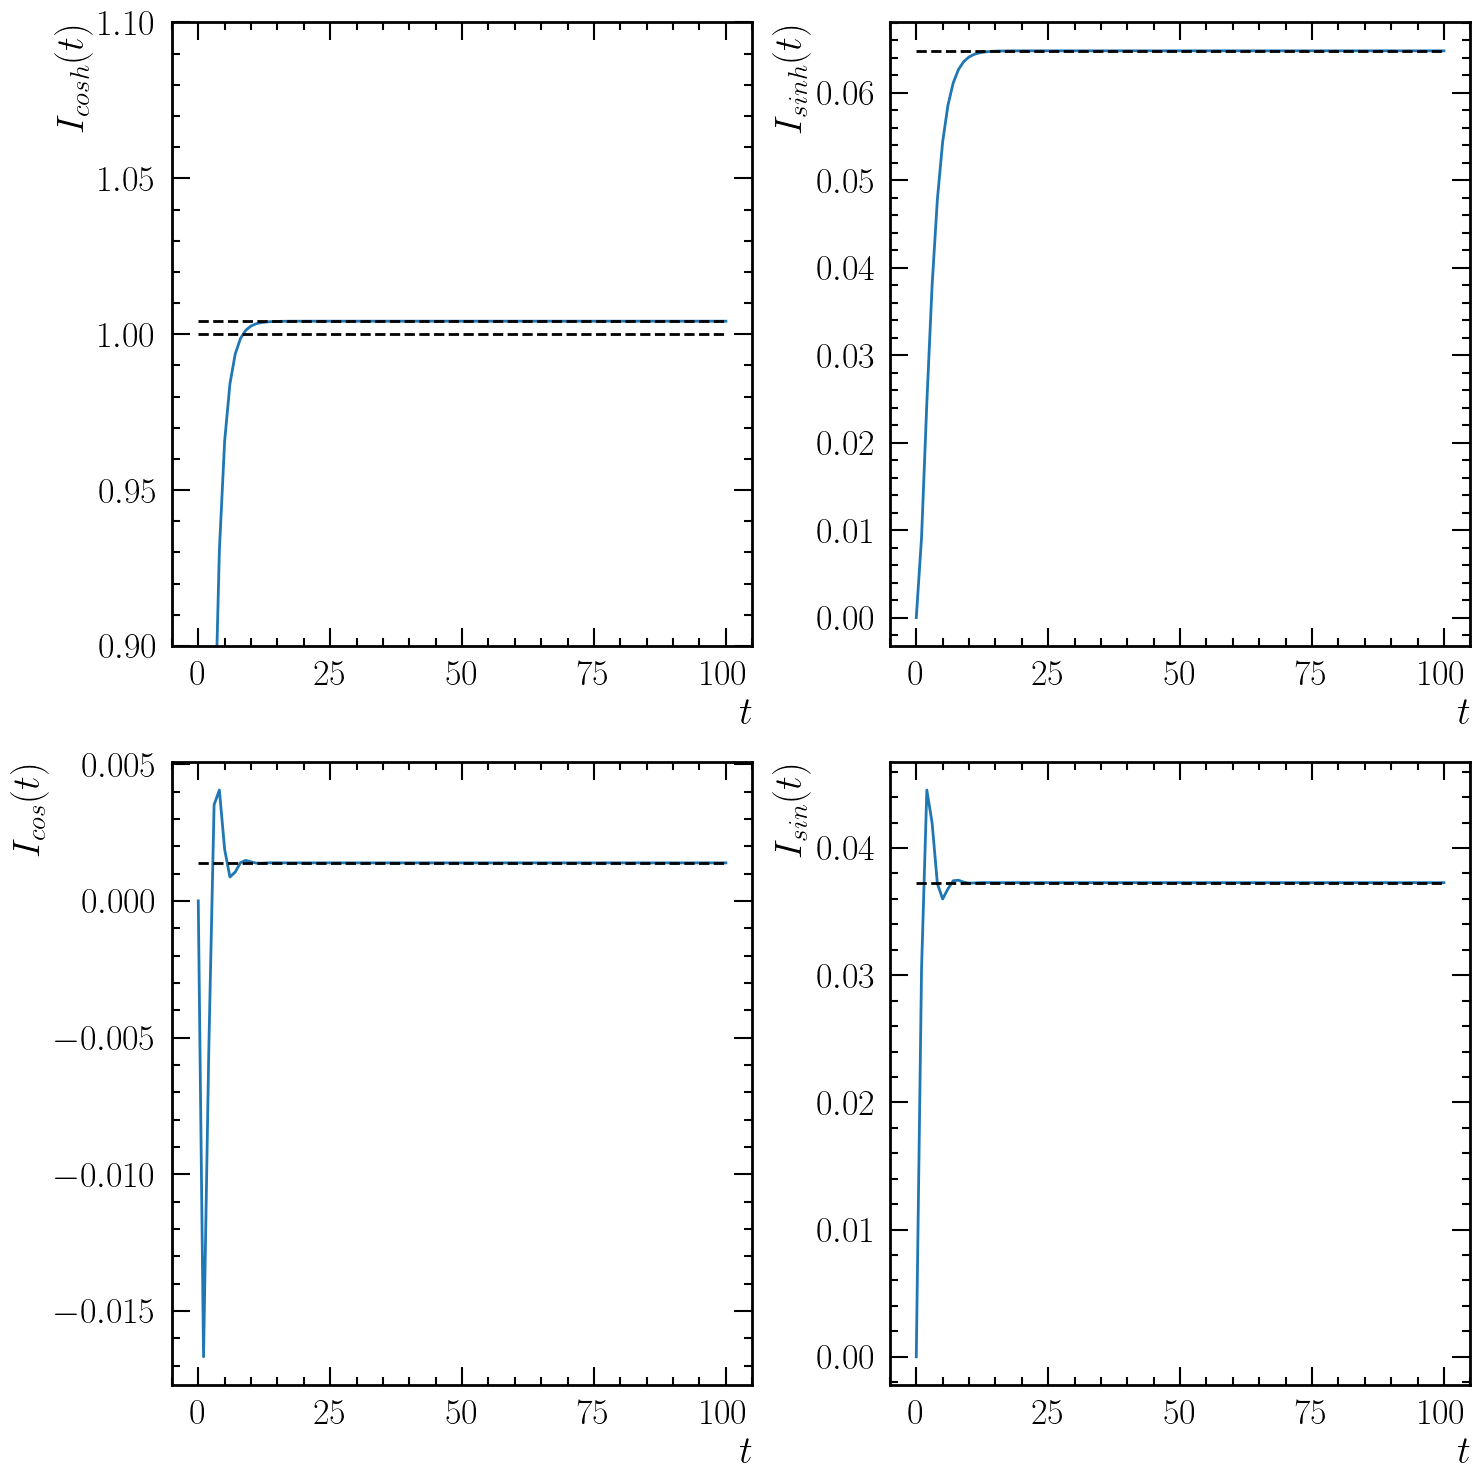

In [50]:
gamma = 0.6597 # only for Bs TODO: remove
y = par_orig['DeltaGamma/Gamma_'+B]/2.
x = par_orig['DeltaM/Gamma_'+B]
t = np.linspace(0,100,101)

fig, axs = plt.subplots(2, 2, figsize=(15, 15))

axs[0, 0].plot(t, [definite_int_cosh(y, gamma, 0, it) for it in t])
axs[0, 0].hlines([1, 1/(1-y**2)], 0, 100, color='k', linestyle='dashed')
axs[0, 0].set_xlabel(r'$t$')
axs[0, 0].set_ylabel(r'$I_{cosh}(t)$')
axs[0, 0].set_ylim(0.9,1.1)

axs[0, 1].plot(t, [definite_int_sinh(y, gamma, 0, it) for it in t])
axs[0, 1].hlines([y/(1-y**2)], 0, 100, color='k', linestyle='dashed')
axs[0, 1].set_xlabel(r'$t$')
axs[0, 1].set_ylabel(r'$I_{sinh}(t)$')
#axs[0, 1].set_ylim(0.9,1.1)

axs[1, 0].plot(t, [definite_int_cos(x, gamma, 0, it) for it in t])
axs[1, 0].hlines([1/(1+x**2)], 0, 100, color='k', linestyle='dashed')
axs[1, 0].set_xlabel(r'$t$')
axs[1, 0].set_ylabel(r'$I_{cos}(t)$')
#axs[1, 0].set_ylim(0.9,1.1)

axs[1, 1].plot(t, [definite_int_sin(x, gamma, 0, it) for it in t])
axs[1, 1].hlines([x/(1+x**2)], 0, 100, color='k', linestyle='dashed')
axs[1, 1].set_xlabel(r'$t$')
axs[1, 1].set_ylabel(r'$I_{sin}(t)$')
#axs[1, 1].set_ylim(0.9,1.1)
plt.tight_layout()
plt.show()

/Users/schmitse/flavio-bsphimumu-fork/flavio/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/schmitse/flavio-bsphimumu-fork/flavio/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


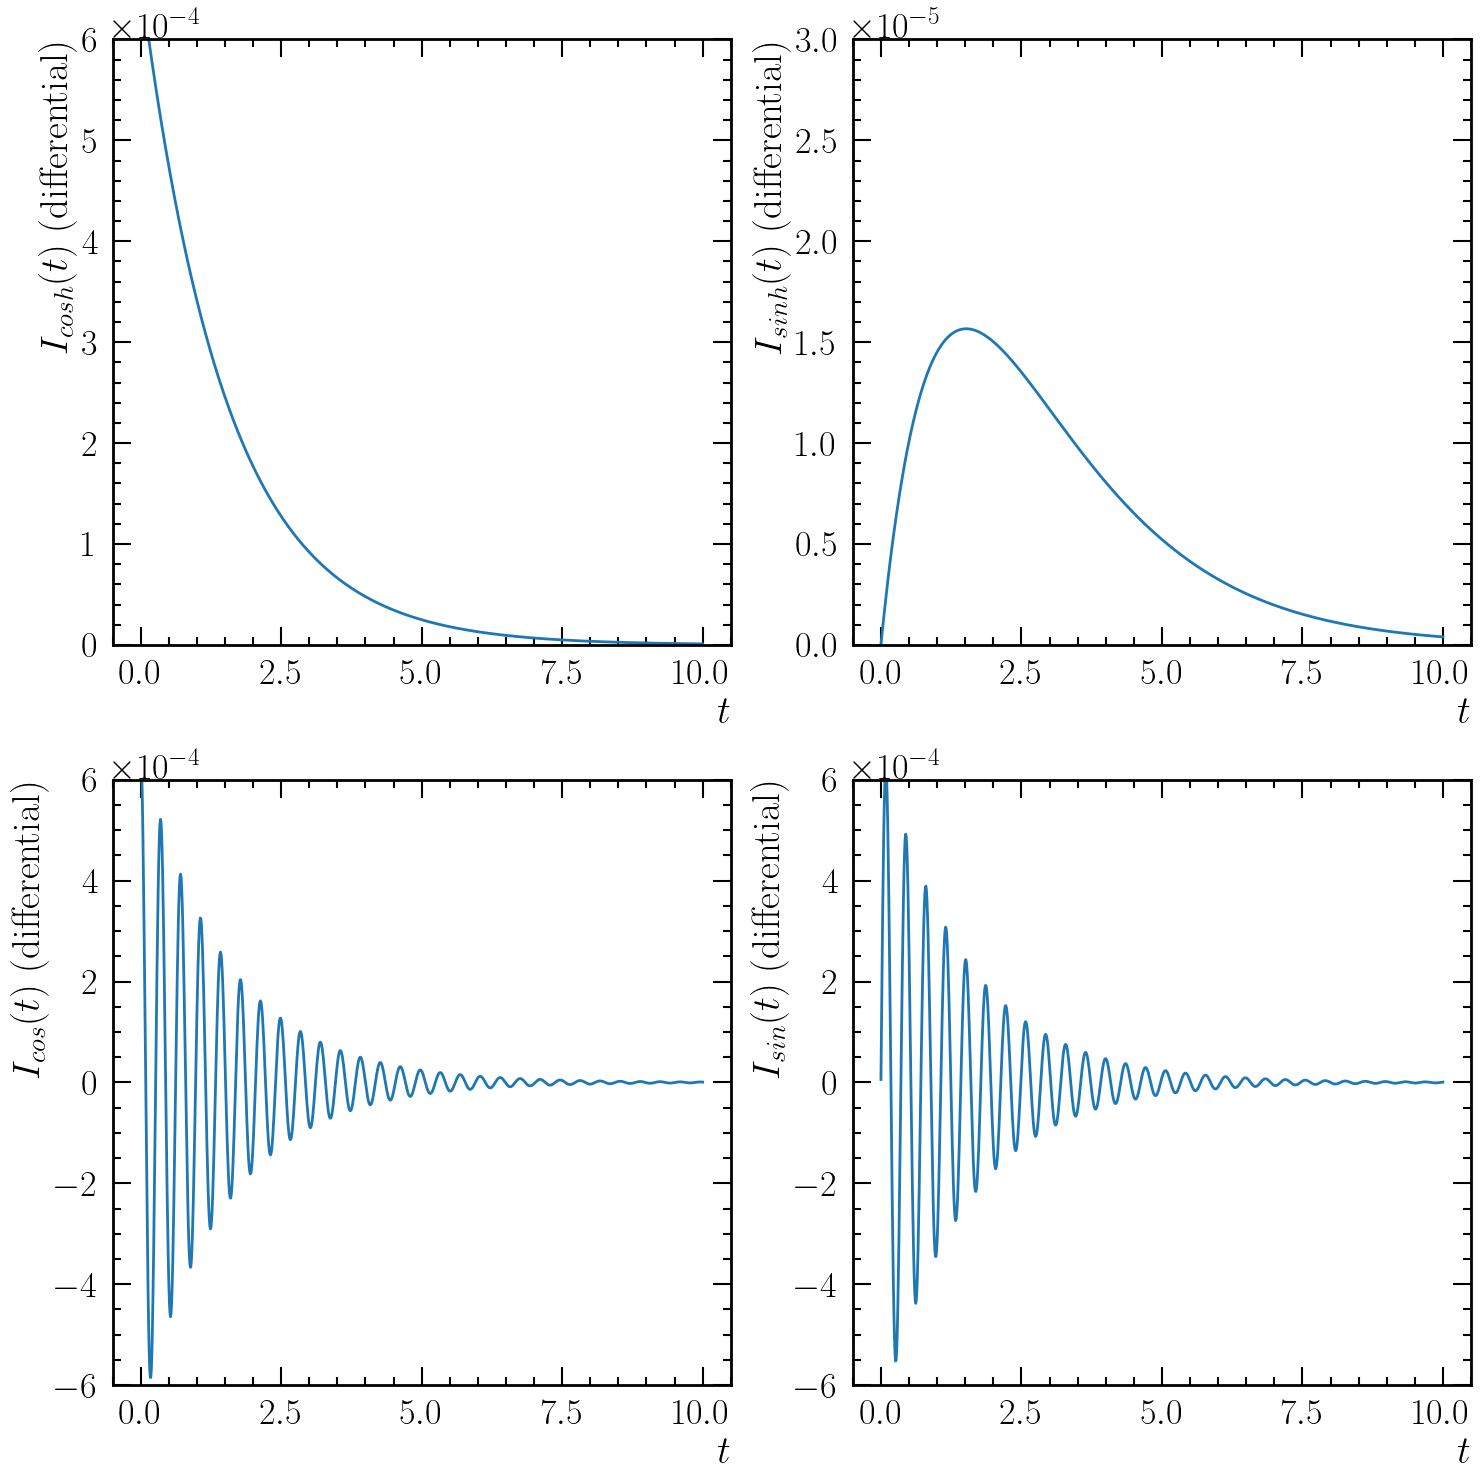

In [55]:
gamma = 0.6597 # only for Bs TODO: remove
y = par_orig['DeltaGamma/Gamma_'+B]/2.
x = par_orig['DeltaM/Gamma_'+B]
t = np.linspace(0,10,1001)
deltat = 0.001

fig, axs = plt.subplots(2, 2, figsize=(15, 15))

axs[0, 0].plot(t, [definite_int_cosh(y, gamma, it, it+deltat) for it in t])
#plt.hlines([1, 1/(1-y**2)], 0, 100, color='k', linestyle='dashed')
axs[0, 0].set_ylim(0.,0.0006)
axs[0, 0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axs[0, 0].set_xlabel(r'$t$')
axs[0, 0].set_ylabel(r'$I_{cosh}(t)$ (differential)')

axs[0, 1].plot(t, [definite_int_sinh(y, gamma, it, it+deltat) for it in t])
#plt.hlines([y/(1-y**2)], 0, 100, color='k', linestyle='dashed')
axs[0, 1].set_ylim(0.,0.00003)
axs[0, 1].set_xlabel(r'$t$')
axs[0, 1].set_ylabel(r'$I_{sinh}(t)$ (differential)')
axs[0, 1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

axs[1, 0].plot(t, [definite_int_cos(x, gamma, it, it+deltat) for it in t])
#plt.hlines([1/(1+x**2)], 0, 100, color='k', linestyle='dashed')
axs[1, 0].set_ylim(-0.0006,0.0006)
axs[1, 0].set_xlabel(r'$t$')
axs[1, 0].set_ylabel(r'$I_{cos}(t)$ (differential)')
axs[1, 0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

axs[1, 1].plot(t, [definite_int_sin(x, gamma, it, it+deltat) for it in t])
#plt.hlines([x/(1+x**2)], 0, 100, color='k', linestyle='dashed')
axs[1, 1].set_ylim(-0.0006,0.0006)
axs[1, 1].set_xlabel(r'$t$')
axs[1, 1].set_ylabel(r'$I_{sin}(t)$ (differential)')
axs[1, 1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()

/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/qcdf_interpolate.py:33: UserWarning: The QCDF corrections should not be trusted for q2 above 6 GeV^2
  warnings.warn("The QCDF corrections should not be trusted for q2 above 6 GeV^2")
/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/amplitudes.py:74: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/amplitudes.py:83: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/schmitse/flavio-bsphimumu-fork/flavio/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imagina

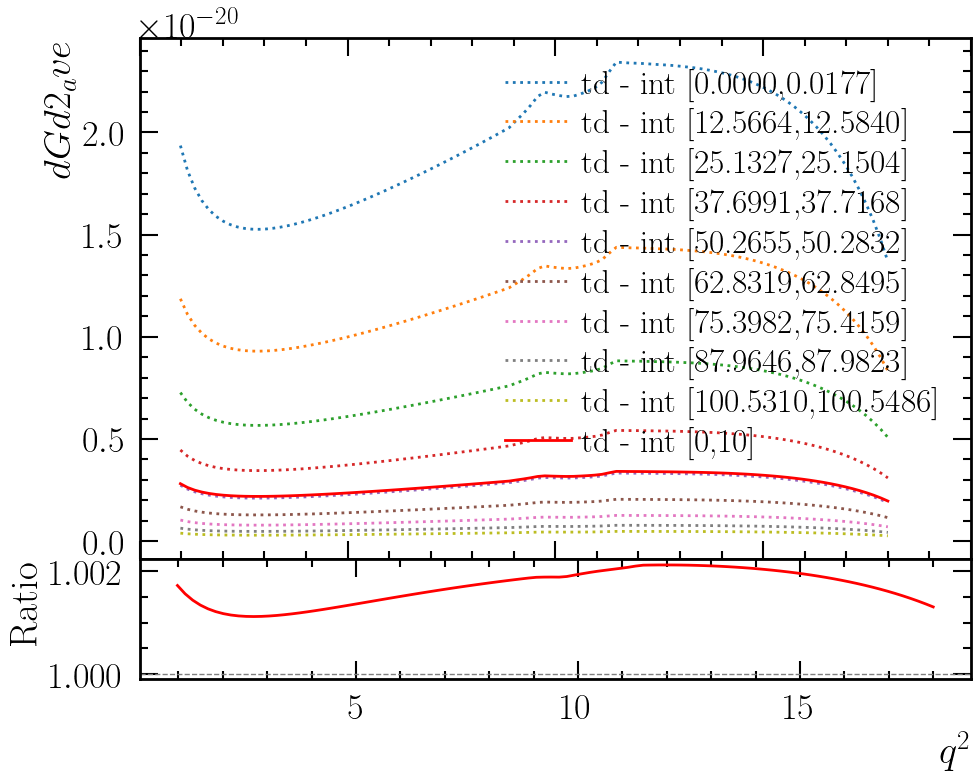

/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/qcdf_interpolate.py:33: UserWarning: The QCDF corrections should not be trusted for q2 above 6 GeV^2
  warnings.warn("The QCDF corrections should not be trusted for q2 above 6 GeV^2")
/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/amplitudes.py:74: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/schmitse/flavio-bsphimumu-fork/flavio/flavio/physics/bdecays/bvll/amplitudes.py:83: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/schmitse/flavio-bsphimumu-fork/flavio/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imagina

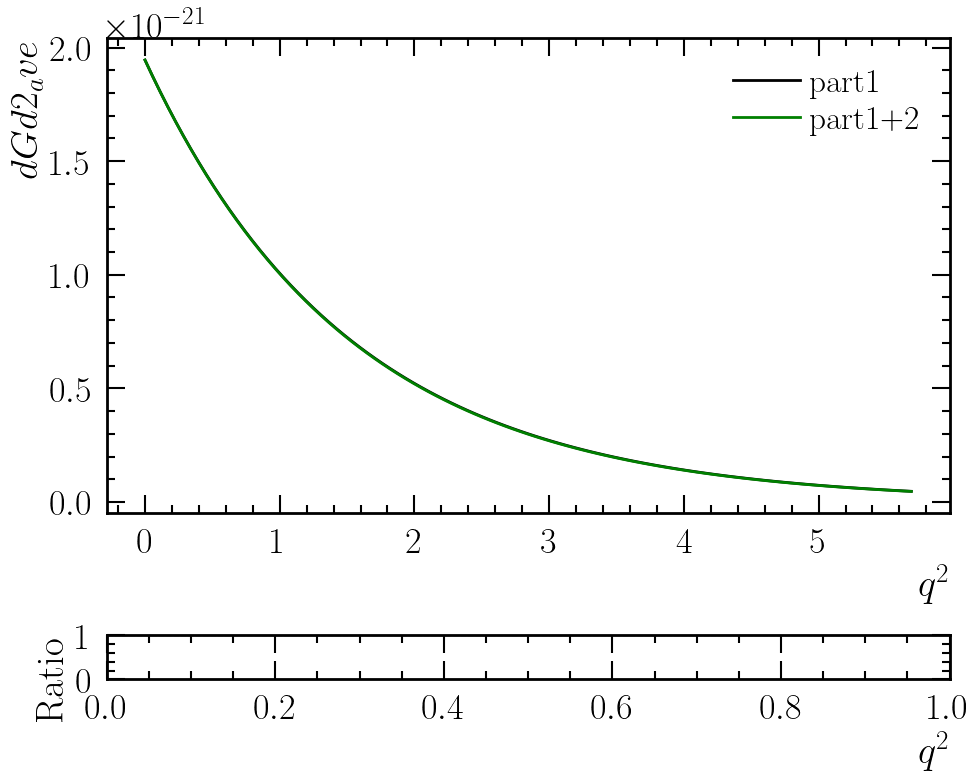

In [ ]:
#start studying it in an unbinned way using test_bvll as an example
q2_min, q2_max = 0.98, 18
npoints = 100
q2_arr = np.linspace(q2_min, q2_max, npoints)

tarray = np.linspace(0, 32*np.pi/(gamma*x), 9)

dGd2_ave_std = np.array([observables.BVll_obs(observables.dGdq2_ave, q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
#dGd2_ave_td = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_ave_Bs, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
#dGd2_interference_td = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_interference_Bs, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

plt.close('all')
fig, ax1 = plt.subplots()

# Main plot
for it in tarray:
        deltat = 0.001
        tmin_Bs, tmax_Bs = it, it+deltat
        dGd2_ave_int_t_td = np.array([observables_bs.bsvll_obs_int_t(observables_bs.dGdq2_ave_int_t_Bs, tmin_Bs, tmax_Bs, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
        ax1.plot(q2_arr, dGd2_ave_int_t_td/deltat, label=f'td - int [{tmin_Bs*(gamma*x):.3f},{tmax_Bs*(gamma*x):.3f}]', linestyle='dotted')

tmin, tmax = 0, 10
dGd2_ave_int_t_td = np.array([observables_bs.bsvll_obs_int_t(observables_bs.dGdq2_ave_int_t_Bs, tmin, tmax, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

#ax1.plot(q2_arr, dGd2_ave_std, label='std', color='r')
#ax1.plot(q2_arr, dGd2_ave_td, label='td', color='b')
#ax1.plot(q2_arr, dGd2_interference_td, label='td-mixing', color='b', linestyle='dashed')
ax1.plot(q2_arr, dGd2_ave_int_t_td/(tmax-tmin), label=f'td - int [{tmin},{tmax}]', color='r')
ax1.legend(frameon=False)
ax1.set_xticks([tick for tick in ax1.get_xticks()])
ax1.set_xticklabels(['' for tick in ax1.get_xticks()])
ax1.set_ylabel('$d\Gamma/d^2_'+r'{\mathrm{ave}}$')

# Ratio plot
divider = make_axes_locatable(ax1)
ax2 = divider.append_axes('bottom', 1.2, pad=0.0)
ratio = dGd2_ave_td / dGd2_ave_std
ax2.plot(q2_arr, ratio,  color='r')
ax2.set_xlabel(r'$q^2$')
ax2.set_ylabel('Ratio')
ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


tarray = np.linspace(0, 32*np.pi/(gamma*x), 101)

plt.close('all')
fig = plt.figure()
gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])
tmin, tmax = 0, 10
dGd2_ave_int_t_td = np.array([observables_bs.bsvll_obs_int_t(observables_bs.dGdq2_ave_int_t_Bs, tmin, tmax, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
dGd2_ave_td_part1 = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_ave_Bs_part1, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
dGd2_ave_td_part2 = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_ave_Bs_part2, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
# Main plot
ax1 = fig.add_subplot(gs[0:2, 0])
deltat = 0.001
dcosh = np.array([definite_int_cosh(y, gamma, it, it+deltat) for it in tarray])
dsinh = np.array([definite_int_sinh(y, gamma, it, it+deltat) for it in tarray])

plt.plot(tarray, dcosh*np.sum(dGd2_ave_td_part1), label='part1',  color='k')
#plt.plot(tarray, dsinh*np.sum(dGd2_ave_td_part2), label='part1',  color='r')
plt.plot(tarray, dcosh*np.sum(dGd2_ave_td_part1) + dsinh*np.sum(dGd2_ave_td_part2), label='part1+2',  color='g')
#plt.plot(tarray, np.sum(dGd2_ave_int_t_td)*np.ones_like(tarray), label='part1',  color='b')


#ax1.plot(q2_arr, dGd2_ave_std, label='std', color='r')
#ax1.plot(q2_arr, dGd2_ave_td, label='td', color='b')
#ax1.plot(q2_arr, dGd2_interference_td, label='td-mixing', color='b', linestyle='dashed')
ax1.legend(frameon=False)
ax1.set_xlabel(r'$q^2$')
ax1.set_ylabel(f'$dGd2_ave$')

# Ratio plot
ax2 = fig.add_subplot(gs[2, 0])
ratio = dGd2_ave_td / dGd2_ave_std
ax2.set_xlabel(r'$q^2$')
ax2.set_ylabel('Ratio')
ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()





In [15]:
np.sum(dGd2_ave_td_part1)

2.9495221208959713e-18

### Allowing for $B^0_s$ $\bar{B}^0_s$ mixing

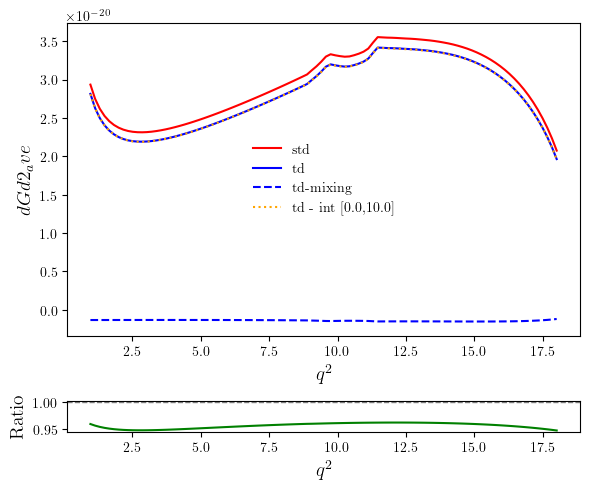

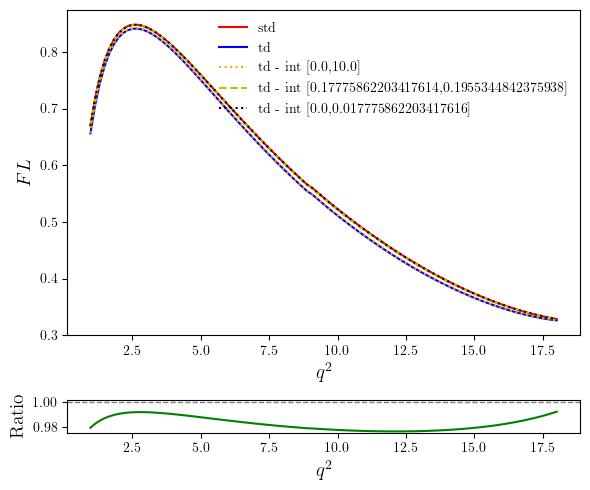

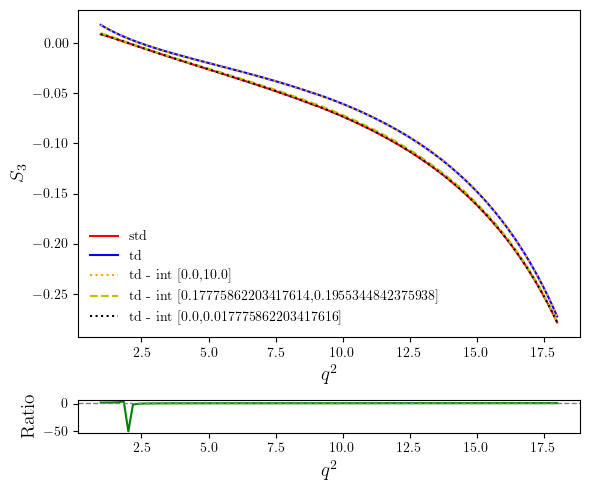

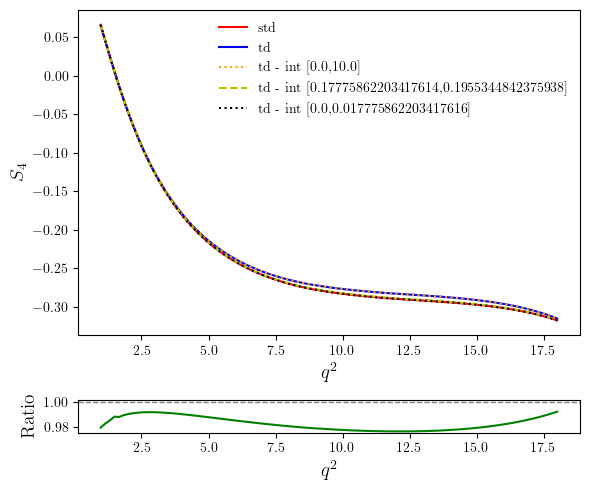

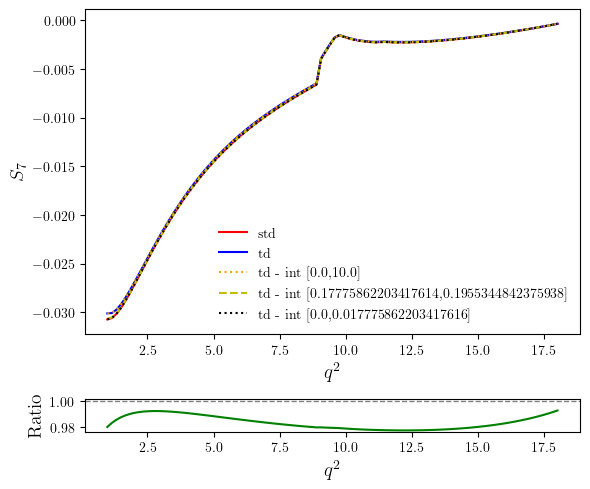

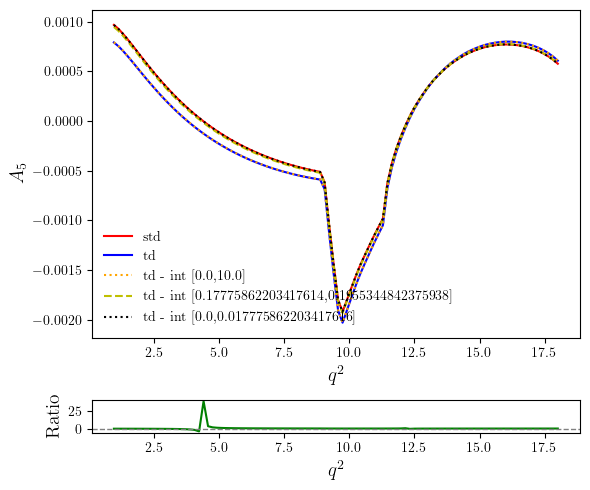

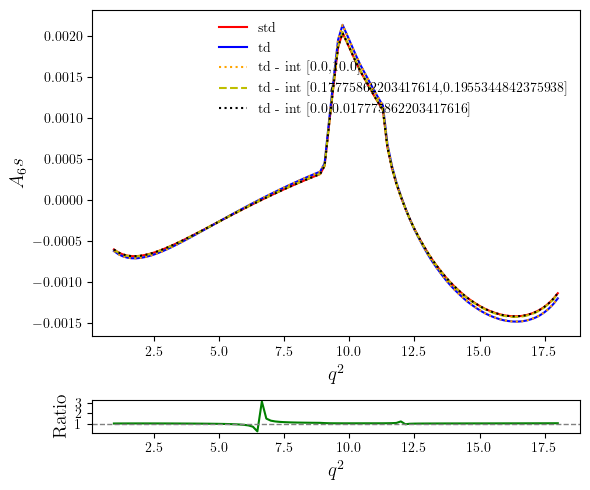

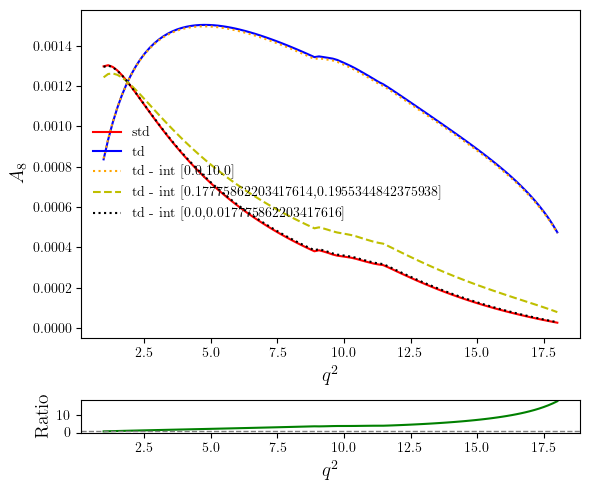

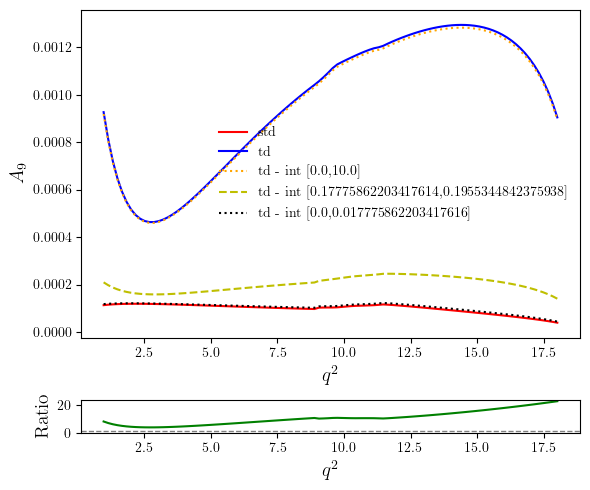

In [16]:
#start studying it in an unbinned way using test_bvll as an example
q2_min, q2_max = 0.98, 18
tmin, tmax = 0., 10.
npoints = 100
q2_arr = np.linspace(q2_min, q2_max, npoints)
figsize=(6, 5)

from flavio.physics.bdecays.bvll import observables, observables_bs
dGd2_ave_std = np.array([observables.BVll_obs(observables.dGdq2_ave, q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
dGd2_ave_td = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_ave_Bs, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
dGd2_interference_td = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_interference_Bs, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

dGd2_ave_int_t_td = np.array([observables_bs.bsvll_obs_int_t(observables_bs.dGdq2_ave_int_t_Bs, tmin, tmax, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

plt.close('all')
fig = plt.figure(figsize=figsize)
gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

# Main plot
ax1 = fig.add_subplot(gs[0:2, 0])
ax1.plot(q2_arr, dGd2_ave_std, label='std', color='r')
ax1.plot(q2_arr, dGd2_ave_td, label='td', color='b')
ax1.plot(q2_arr, dGd2_interference_td, label='td-mixing', color='b', linestyle='dashed')
ax1.plot(q2_arr, dGd2_ave_int_t_td, label=f'td - int [{tmin},{tmax}]', color='orange', linestyle='dotted')
ax1.legend(frameon=False)
ax1.set_xlabel(r'$q^2$')
ax1.set_ylabel(f'$dGd2_ave$')

# Ratio plot
ax2 = fig.add_subplot(gs[2, 0])
ratio = dGd2_ave_td / dGd2_ave_std
ax2.plot(q2_arr, ratio, label='Ratio (std/td)', color='g')
ax2.set_xlabel(r'$q^2$')
ax2.set_ylabel('Ratio')
ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

#DeltaT for which all B mesons are B0s
tmin_Bs, tmax_Bs = 0., 0.1*np.pi/(gamma*x)
#DeltaT for which all B mesons are B0sbar
tmin_Bsbar, tmax_Bsbar = np.pi/(gamma*x), 1.1*np.pi/(gamma*x)

FL_std = np.array([observables.BVll_obs(observables.FL, q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
FL_td = np.array([observables_bs.bsvll_obs( observables_bs.FL_Bs, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
FL_int_t_td = np.array([observables_bs.bsvll_obs_int_t(observables_bs.FL_int_t_Bs, tmin, tmax, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
FL_td_Bs = np.array([observables_bs.bsvll_obs_int_t(observables_bs.FL_int_t_Bs, tmin_Bs, tmax_Bs, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
FL_td_Bsbar = np.array([observables_bs.bsvll_obs_int_t(observables_bs.FL_int_t_Bs, tmin_Bsbar, tmax_Bsbar, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

plt.close('all')
fig = plt.figure(figsize=figsize)
gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

# Main plot
ax1 = fig.add_subplot(gs[0:2, 0])
ax1.plot(q2_arr, FL_std, label='std', color='r')
ax1.plot(q2_arr, FL_td, label='td', color='b')
ax1.plot(q2_arr, FL_int_t_td, label=f'td - int [{tmin},{tmax}]', color='orange', linestyle='dotted')
ax1.plot(q2_arr, FL_td_Bsbar, label=f'td - int [{tmin_Bsbar},{tmax_Bsbar}]', color='y', linestyle='dashed')
ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bs},{tmax_Bs}]', color='k', linestyle='dotted')
ax1.legend(frameon=False)
ax1.set_xlabel(r'$q^2$')
ax1.set_ylabel(f'$FL$')

# Ratio plot
ax2 = fig.add_subplot(gs[2, 0])
ratio = FL_td / FL_std
ax2.plot(q2_arr, ratio, label='Ratio (std/td)', color='g')
ax2.set_xlabel(r'$q^2$')
ax2.set_ylabel('Ratio')
ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


for iobs in [3, 4, 7]:
    # FL here is used as a placeholder
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.S_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    FL_td_int_t = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_int_t_Bs(tmin, tmax, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    FL_td_Bs = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_int_t_Bs(tmin_Bs, tmax_Bs, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    FL_td_Bsbar = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_int_t_Bs(tmin_Bsbar, tmax_Bsbar, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    ax1.plot(q2_arr, FL_std, label='std', color='r')
    ax1.plot(q2_arr, FL_td, label='td', color='b')
    ax1.plot(q2_arr, FL_td_int_t, label=f'td - int [{tmin},{tmax}]', color='orange', linestyle='dotted')
    ax1.plot(q2_arr, FL_td_Bsbar, label=f'td - int [{tmin_Bsbar},{tmax_Bsbar}]', color='y', linestyle='dashed')
    ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bs},{tmax_Bs}]', color='k', linestyle='dotted')
    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel(f'$S_{iobs}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = FL_td / FL_std
    ax2.plot(q2_arr, ratio, label='Ratio (std/td)', color='g')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference
    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.show()
    
for iobs in [5, '6s', 8, 9]:
    # FL here is used as a placeholder
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.A_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    FL_td_int_t = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_int_t_Bs(tmin, tmax, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    FL_td_Bs = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_int_t_Bs(tmin_Bs, tmax_Bs, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    FL_td_Bsbar = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_int_t_Bs(tmin_Bsbar, tmax_Bsbar, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    ax1.plot(q2_arr, FL_std, label='std', color='r')
    ax1.plot(q2_arr, FL_td, label='td ', color='b')
    ax1.plot(q2_arr, FL_td_int_t, label=f'td - int [{tmin},{tmax}]', color='orange', linestyle='dotted')
    ax1.plot(q2_arr, FL_td_Bsbar, label=f'td - int [{tmin_Bsbar},{tmax_Bsbar}]', color='y', linestyle='dashed')
    ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bs},{tmax_Bs}]', color='k', linestyle='dotted')

    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel(f'$A_{iobs}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = FL_td / FL_std
    ax2.plot(q2_arr, ratio, label='Ratio (std/td)', color='g')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference
    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.show()

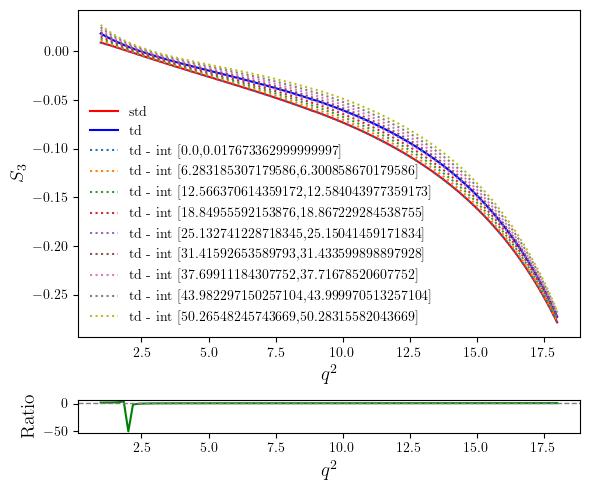

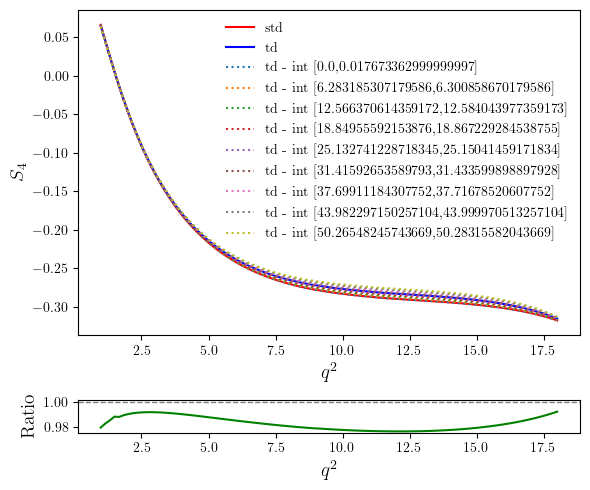

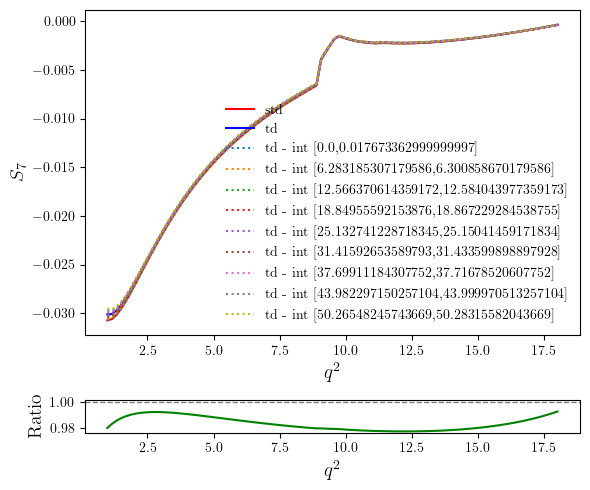

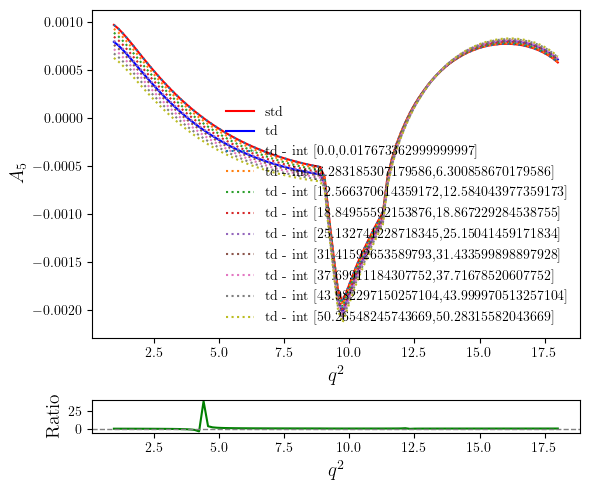

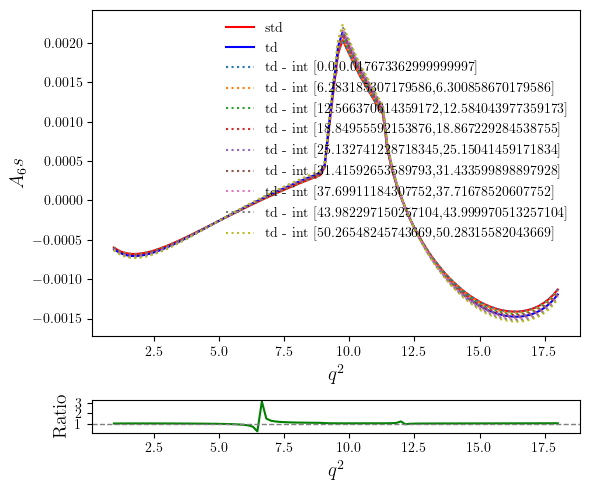

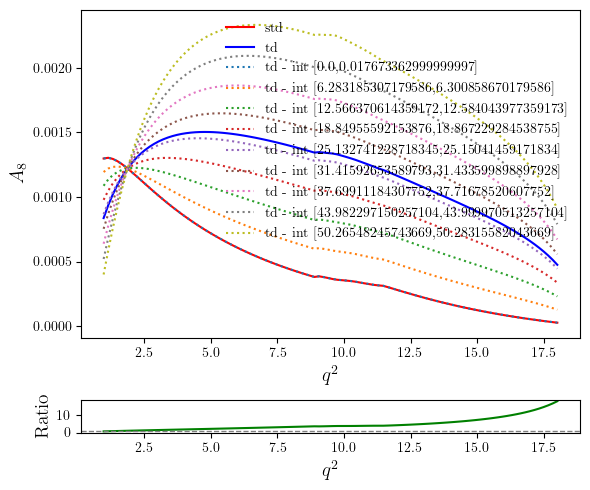

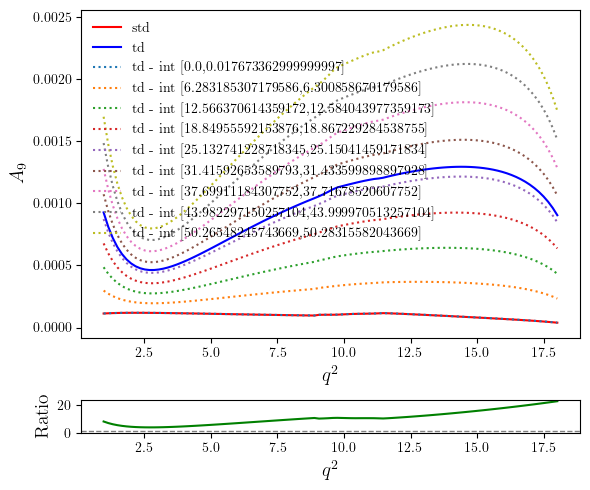

In [17]:
#start studying it in an unbinned way using test_bvll as an example
q2_min, q2_max = 0.98, 18
npoints = 100
q2_arr = np.linspace(q2_min, q2_max, npoints)
figsize=(6, 5)

tarray = np.linspace(0, 16*np.pi/(gamma*x), 9)

for iobs in [3, 4, 7]:
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.S_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    #FL_td_int_t = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_int_t_Bs(tmin, tmax, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    #FL_td_Bsbar = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_int_t_Bs(tmin_Bsbar, tmax_Bsbar, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    ax1.plot(q2_arr, FL_std, label='std', color='r')
    ax1.plot(q2_arr, FL_td, label='td ', color='b')
    for it in tarray:
        deltat = 0.001
        tmin_Bs, tmax_Bs = it, it+deltat
        FL_td_Bs = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_int_t_Bs(tmin_Bs, tmax_Bs, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
        #ax1.plot(q2_arr, FL_td_int_t, label=f'td - int [{tmin},{tmax}]', color='orange', linestyle='dotted')
        #ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bsbar},{tmax_Bsbar}]', linestyle='dashed')
        ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bs*(gamma*x)},{tmax_Bs*(gamma*x)}]', linestyle='dotted')
        #ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bs},{tmax_Bs}]', linestyle='dotted')

    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel(f'$S_{iobs}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = FL_td / FL_std
    ax2.plot(q2_arr, ratio, label='Ratio (std/td)', color='g')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference
    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.show()

for iobs in [5, '6s', 8, 9]:
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.A_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    #FL_td_int_t = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_int_t_Bs(tmin, tmax, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    #FL_td_Bsbar = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_int_t_Bs(tmin_Bsbar, tmax_Bsbar, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    ax1.plot(q2_arr, FL_std, label='std', color='r')
    ax1.plot(q2_arr, FL_td, label='td', color='b')
    for it in tarray:
        deltat = 0.001
        tmin_Bs, tmax_Bs = it, it+deltat
        FL_td_Bs = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_int_t_Bs(tmin_Bs, tmax_Bs, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
        #ax1.plot(q2_arr, FL_td_int_t, label=f'td - int [{tmin},{tmax}]', color='orange', linestyle='dotted')
        #ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bsbar},{tmax_Bsbar}]', color='y', linestyle='dashed')
        ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bs*(gamma*x)},{tmax_Bs*(gamma*x)}]', linestyle='dotted')
        #ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bs},{tmax_Bs}]', linestyle='dotted')

    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel(f'$A_{iobs}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = FL_td / FL_std
    ax2.plot(q2_arr, ratio, label='Ratio (std/td)', color='g')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference
    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.show()
    

In [18]:
tmin_Bs, tmax_Bs = 0., 0.1*np.pi/(gamma*x)

print(definite_int_cosh(y, gamma, tmin_Bs, tmax_Bs))
print(definite_int_cos(x, gamma, tmin_Bs, tmax_Bs))
print(definite_int_sinh(y, gamma, tmin_Bs, tmax_Bs))
print(definite_int_sin(x, gamma, tmin_Bs, tmax_Bs))

(0.011658247215429672-0j)
(0.011467978076789627+0j)
(4.4003830155111625e-06-0j)
(0.001812734473936441+0j)


### Check variables available with flavour tagging

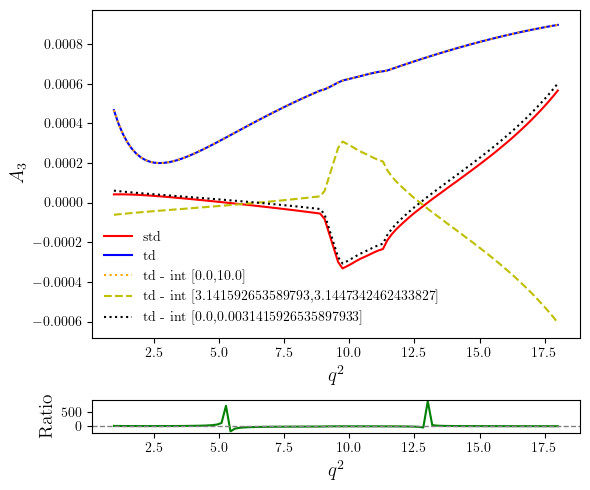

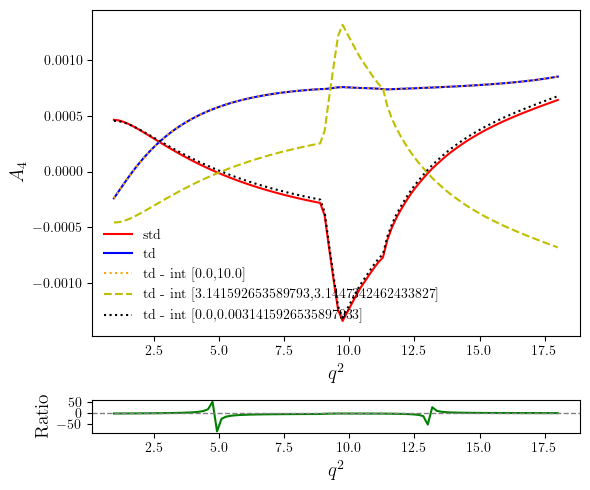

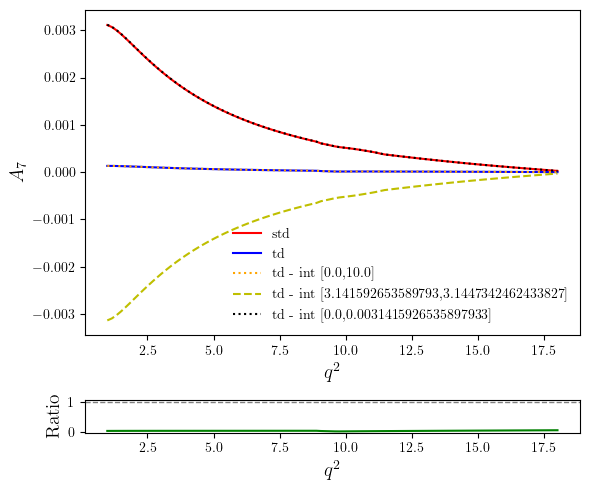

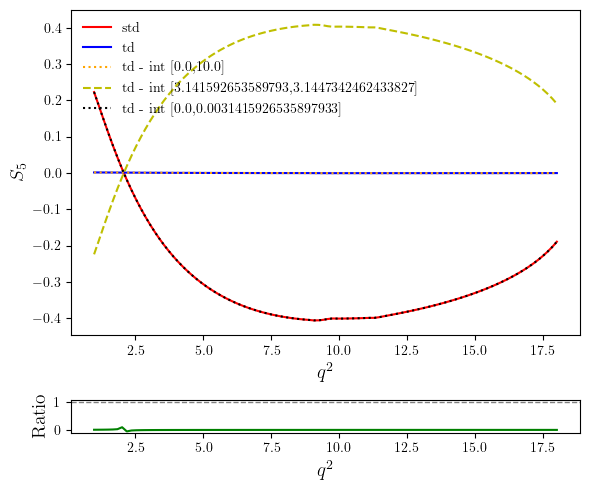

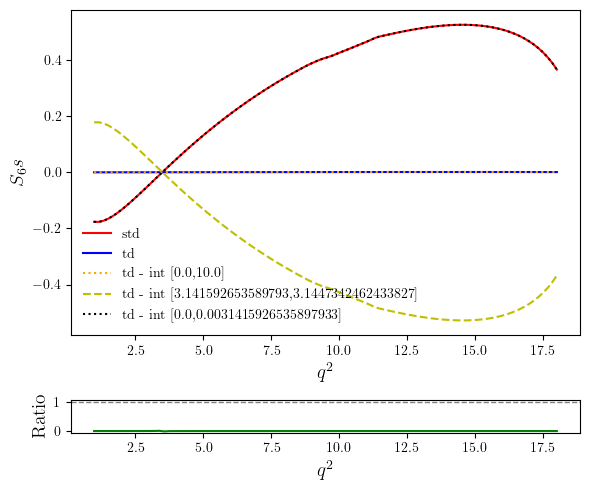

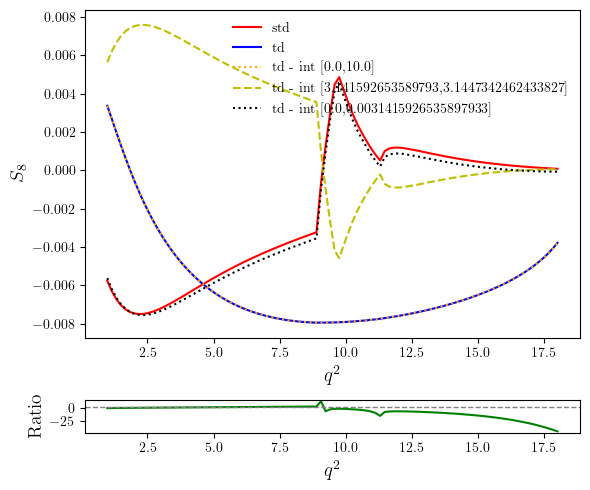

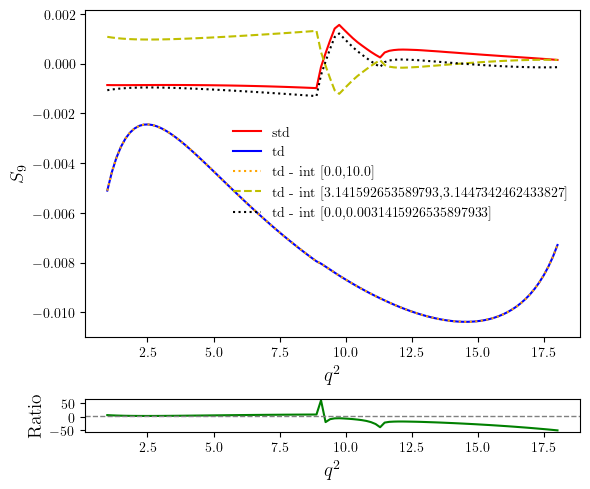

In [19]:
#start studying it in an unbinned way using test_bvll as an example
q2_min, q2_max = 0.98, 18
npoints = 100
q2_arr = np.linspace(q2_min, q2_max, npoints)
figsize=(6, 5)

tmin_Bs, tmax_Bs = 0., 0.001*np.pi/(gamma*x)
tmin_Bsbar, tmax_Bsbar = np.pi/(gamma*x), 1.001*np.pi/(gamma*x)

for iobs in [3, 4, 7]:
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.A_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    FL_td_int_t = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_int_t_Bs(tmin, tmax, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    FL_td_Bs = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_int_t_Bs(tmin_Bs, tmax_Bs, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    FL_td_Bsbar = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_int_t_Bs(tmin_Bsbar, tmax_Bsbar, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    ax1.plot(q2_arr, FL_std, label='std', color='r')
    ax1.plot(q2_arr, FL_td, label='td', color='b')
    ax1.plot(q2_arr, FL_td_int_t, label=f'td - int [{tmin},{tmax}]', color='orange', linestyle='dotted')
    ax1.plot(q2_arr, FL_td_Bsbar, label=f'td - int [{tmin_Bsbar*(gamma*x)},{tmax_Bsbar*(gamma*x)}]', color='y', linestyle='dashed')
    ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bs*(gamma*x)},{tmax_Bs*(gamma*x)}]', color='k', linestyle='dotted')

    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel(f'$A_{iobs}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = FL_td / FL_std
    ax2.plot(q2_arr, ratio, label='Ratio (std/td)', color='g')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference
    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.show()
    
for iobs in [5, '6s', 8, 9]:
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.S_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    FL_td_int_t = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_int_t_Bs(tmin, tmax, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    FL_td_Bs = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_int_t_Bs(tmin_Bs, tmax_Bs, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    FL_td_Bsbar = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_int_t_Bs(tmin_Bsbar, tmax_Bsbar, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    ax1.plot(q2_arr, FL_std, label='std', color='r')
    ax1.plot(q2_arr, FL_td, label='td ', color='b')
    ax1.plot(q2_arr, FL_td_int_t, label=f'td - int [{tmin},{tmax}]', color='orange', linestyle='dotted')
    #ax1.plot(q2_arr, FL_td_Bsbar, label=f'td - int [{tmin_Bsbar},{tmax_Bsbar}]', color='y', linestyle='dashed')
    #ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bs},{tmax_Bs}]', color='k', linestyle='dotted')
    ax1.plot(q2_arr, FL_td_Bsbar, label=f'td - int [{tmin_Bsbar*(gamma*x)},{tmax_Bsbar*(gamma*x)}]', color='y', linestyle='dashed')
    ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bs*(gamma*x)},{tmax_Bs*(gamma*x)}]', color='k', linestyle='dotted')

    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel(f'$S_{iobs}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = FL_td / FL_std
    ax2.plot(q2_arr, ratio, label='Ratio (std/td)', color='g')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference
    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.show()

In [20]:
tarray*(gamma*x)

array([ 0.        ,  6.28318531, 12.56637061, 18.84955592, 25.13274123,
       31.41592654, 37.69911184, 43.98229715, 50.26548246])

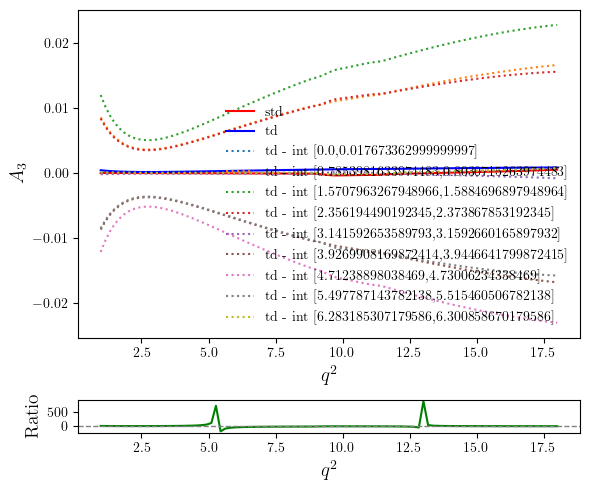

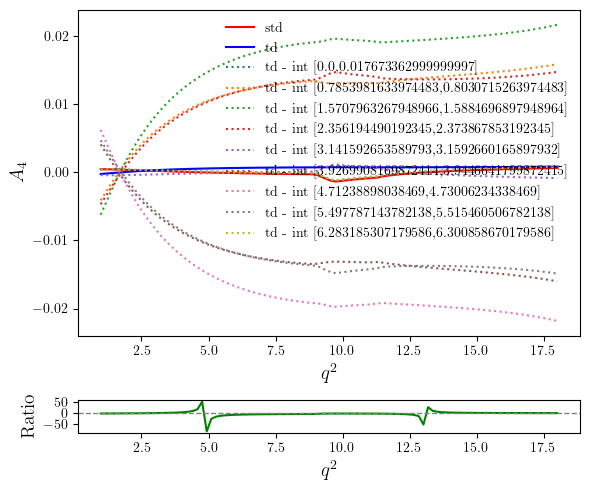

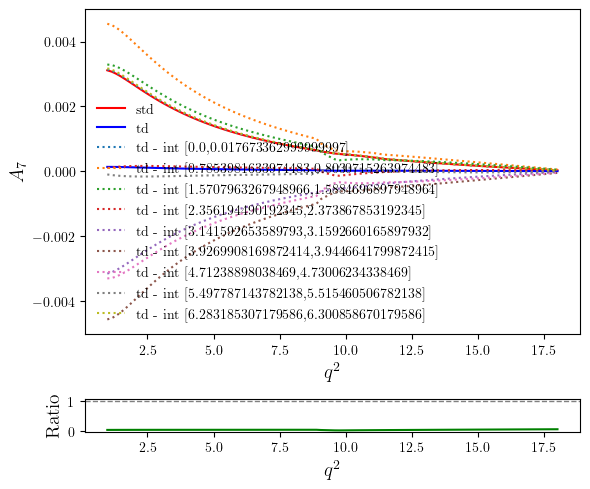

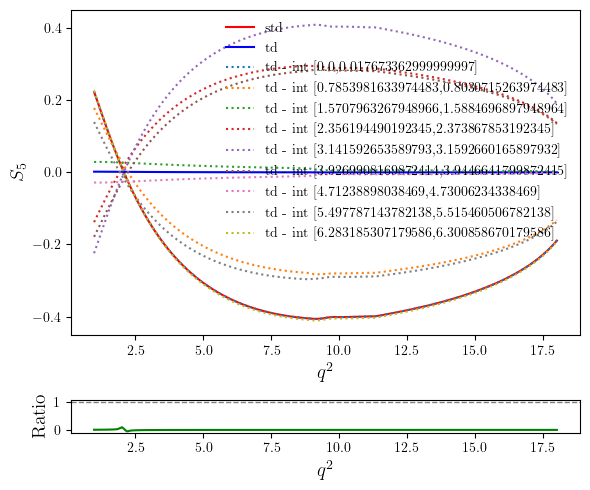

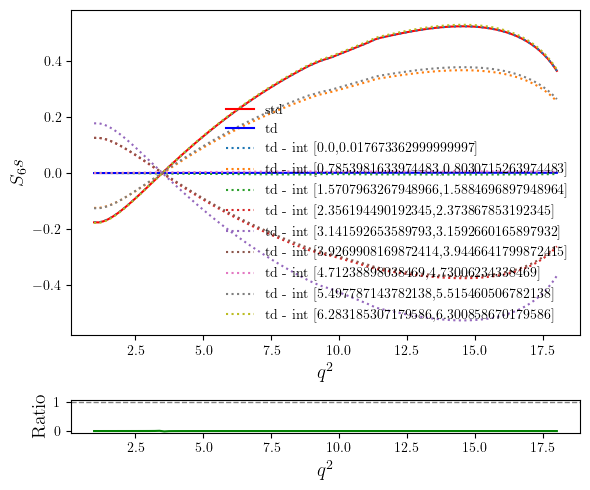

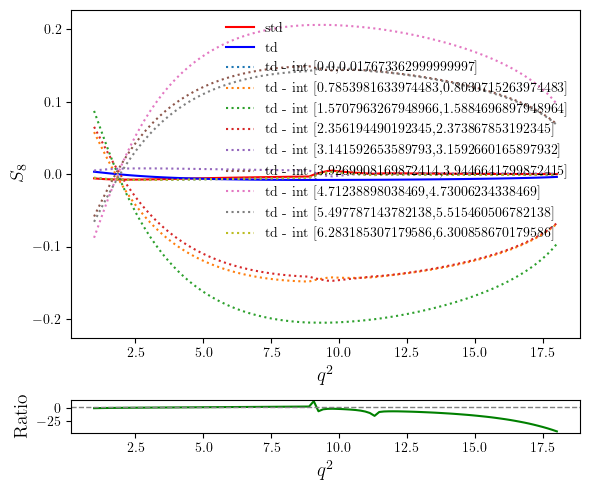

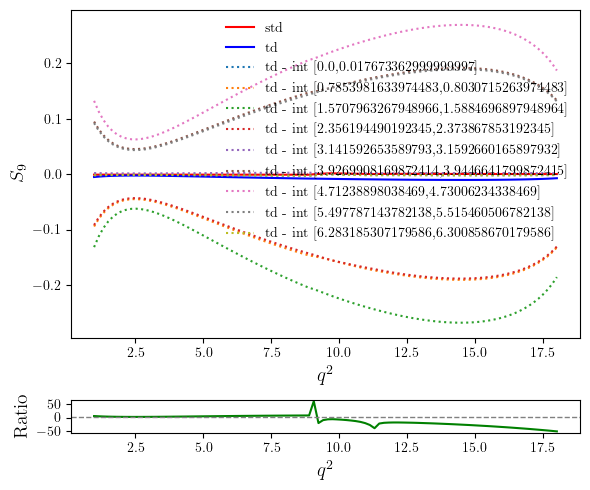

In [21]:
#start studying it in an unbinned way using test_bvll as an example
q2_min, q2_max = 0.98, 18
npoints = 100
q2_arr = np.linspace(q2_min, q2_max, npoints)
figsize=(6, 5)

tarray = np.linspace(0, 2*np.pi/(gamma*x), 9)


for iobs in [3, 4, 7]:
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.A_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    #FL_td_int_t = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_int_t_Bs(tmin, tmax, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    #FL_td_Bsbar = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_int_t_Bs(tmin_Bsbar, tmax_Bsbar, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    ax1.plot(q2_arr, FL_std, label='std', color='r')
    ax1.plot(q2_arr, FL_td, label='td', color='b')
    for it in tarray:
        deltat = 0.001
        tmin_Bs, tmax_Bs = it, it+deltat
        FL_td_Bs = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_int_t_Bs(tmin_Bs, tmax_Bs, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
        #ax1.plot(q2_arr, FL_td_int_t, label=f'td - int [{tmin},{tmax}]', color='orange', linestyle='dotted')
        #ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bsbar},{tmax_Bsbar}]', color='y', linestyle='dashed')
        ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bs*(gamma*x)},{tmax_Bs*(gamma*x)}]', linestyle='dotted')
        #ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bs},{tmax_Bs}]', linestyle='dotted')

    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel(f'$A_{iobs}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = FL_td / FL_std
    ax2.plot(q2_arr, ratio, label='Ratio (std/td)', color='g')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference
    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.show()
    
for iobs in [5, '6s', 8, 9]:
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.S_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    #FL_td_int_t = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_int_t_Bs(tmin, tmax, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    #FL_td_Bsbar = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_int_t_Bs(tmin_Bsbar, tmax_Bsbar, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    ax1.plot(q2_arr, FL_std, label='std', color='r')
    ax1.plot(q2_arr, FL_td, label='td ', color='b')
    for it in tarray:
        deltat = 0.001
        tmin_Bs, tmax_Bs = it, it+deltat
        FL_td_Bs = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_int_t_Bs(tmin_Bs, tmax_Bs, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
        #ax1.plot(q2_arr, FL_td_int_t, label=f'td - int [{tmin},{tmax}]', color='orange', linestyle='dotted')
        #ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bsbar},{tmax_Bsbar}]', linestyle='dashed')
        ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bs*(gamma*x)},{tmax_Bs*(gamma*x)}]', linestyle='dotted')
        #ax1.plot(q2_arr, FL_td_Bs, label=f'td - int [{tmin_Bs},{tmax_Bs}]', linestyle='dotted')

    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel(f'$S_{iobs}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = FL_td / FL_std
    ax2.plot(q2_arr, ratio, label='Ratio (std/td)', color='g')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference
    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.show()

### Now maybe check the single terms

In [22]:
def get_vector_of_all_Js_h_and_s(y, x, gamma, J, J_bar, J_h, J_s):
    return y, x, gamma, J, J_bar, J_h, J_s
def get_vector_of_all_Js(J,J_bar):
    return J,J_bar

In [23]:
#start studying it in an unbinned way using test_bvll as an example
q2_min, q2_max = 0.98, 18
npoints = 100
q2_arr = np.linspace(q2_min, q2_max, npoints)

js_std = np.array([observables.BVll_obs(get_vector_of_all_Js, q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
js_td = np.array([observables_bs.bsvll_obs(get_vector_of_all_Js_h_and_s, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])


In [24]:
js_td[0][6]

{'1s': -7.173184274611516e-23,
 '1c': 3.133390983192472e-21,
 '2s': -2.2164062995731086e-23,
 '2c': -2.859646912362698e-21,
 '6s': -7.560884795611988e-23,
 '6c': -0.0,
 3: -7.054906182886995e-22,
 4: -3.6330627014213837e-22,
 5: -1.775586266259332e-21,
 7: 1.943774906729075e-22,
 8: -5.107563457807983e-21,
 9: -7.710434887287336e-21}

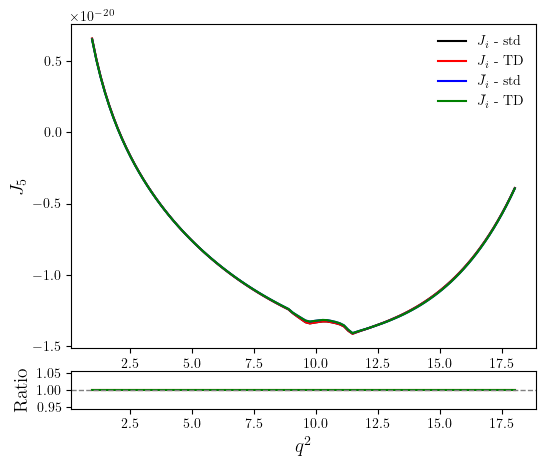

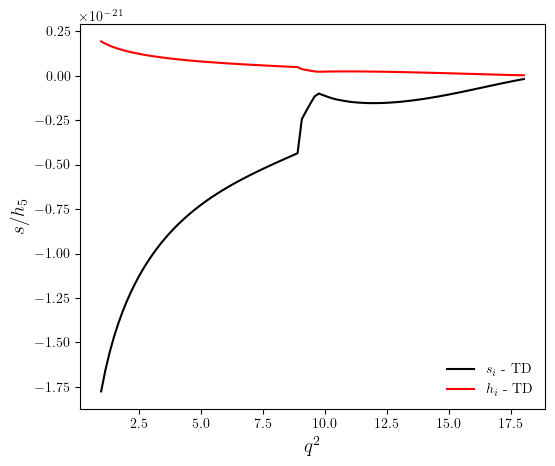

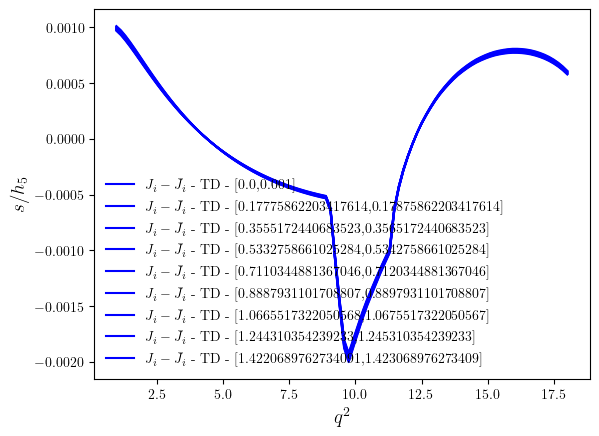

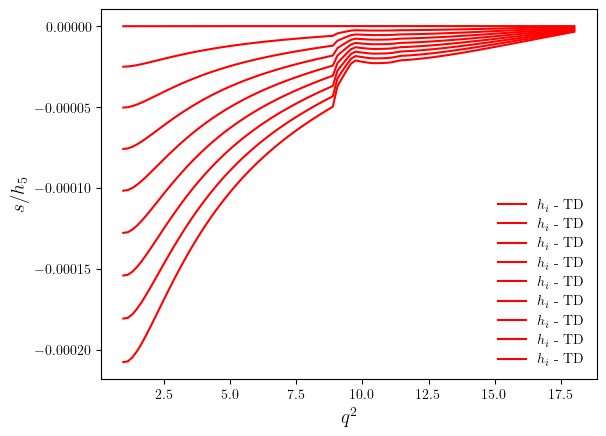

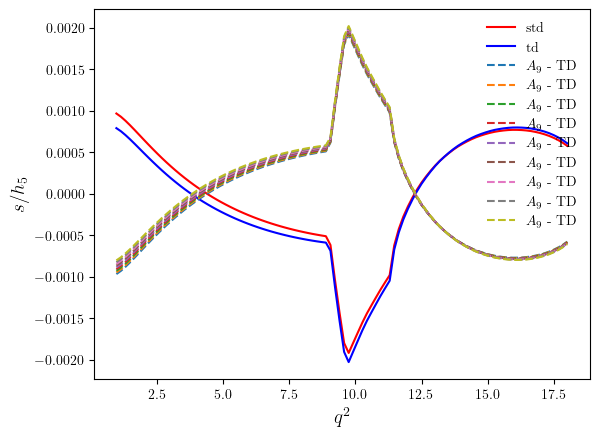

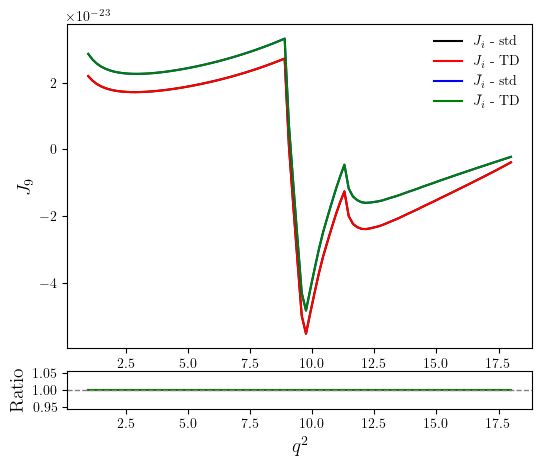

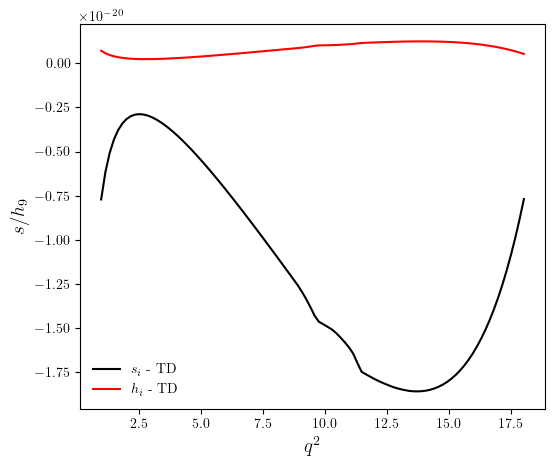

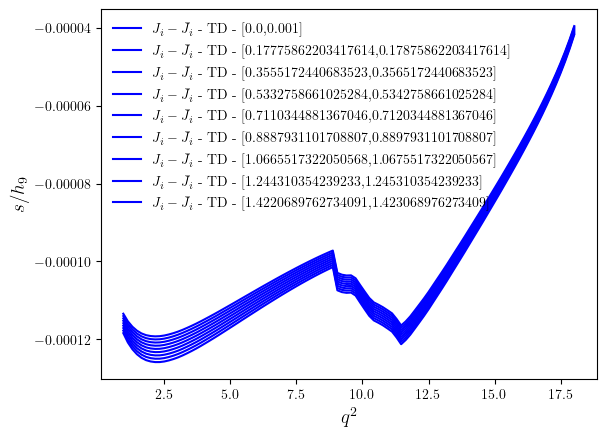

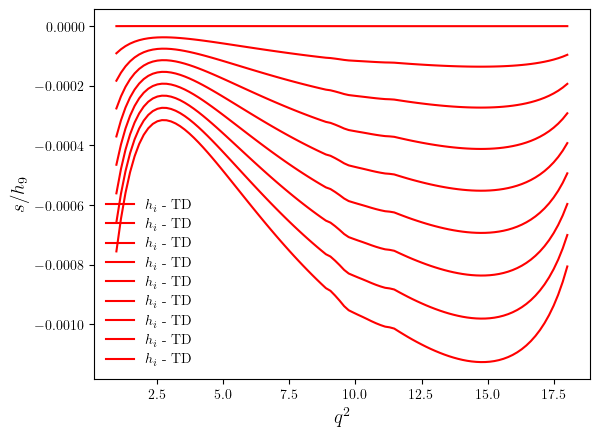

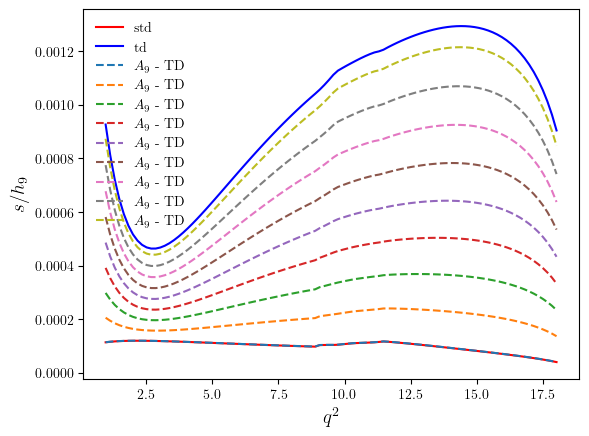

In [25]:
for num in [5,9]:
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.A_experiment(J, J_bar, num), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    
    
    j_std, jbar_std  = [], []
    j_td, jbar_td, j_h_td, j_s_td   = [], [], [] ,[]

    for arr in js_std:
        j_std.append(arr[0][num])
        jbar_std.append(arr[1][num])
    for arr in js_td:
        j_td.append(arr[3][num])
        jbar_td.append(arr[4][num])
        j_h_td.append(arr[5][num])
        j_s_td.append(arr[6][num])
    

    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    ax1.plot(q2_arr, j_std, label=r'$J_i$ - std', color='k')
    ax1.plot(q2_arr, j_td, label=r'$J_i$ - TD ', color='r')
    #ax1.legend(frameon=False)
    #ax1.set_xlabel(r'$q^2$')
    #ax1.set_ylabel(f'$J_{num}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = np.array(j_td) / np.array(j_std)
    ax2.plot(q2_arr, ratio, label='Ratio (TD/std)', color='r')
    #ax2.set_xlabel(r'$q^2$')
    #ax2.set_ylabel('Ratio')
    #ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

    # Main plot
    ax1.plot(q2_arr, jbar_std, label=r'$\bar{J}_i$ - std', color='b')
    ax1.plot(q2_arr, jbar_td, label=r'$\bar{J}_i$ - TD', color='g')
    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel(r"$J_{"+str(num)+"}$")

    # Ratio plot
    ratio = np.array(jbar_td) / np.array(jbar_std)
    ax2.plot(q2_arr, ratio, label='$Ratio$ (TD/std)', color='g')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

    # Adjust layout to avoid overlap
    #plt.tight_layout()
    plt.show()
    
    plt.close('all')
    fig = plt.figure(figsize=figsize)

    # Main plot
    plt.plot(q2_arr, j_s_td, label=r'$s_i$ - TD', color='k')
    plt.plot(q2_arr, j_h_td, label=r'$h_i$ - TD ', color='r')
    #plt.plot(q2_arr, np.array(j_td) - np.array(jbar_td), label=r'$J_i - \bar{J}_i$ - TD ', color='b')
    plt.legend(frameon=False)
    plt.xlabel(r'$q^2$')
    plt.ylabel(r"$s/h_{"+str(num)+"}$")
    plt.show()
    
    tarray = np.linspace(0, 8*np.pi/(gamma*x), 9)
    deltat = 0.001

    for it in tarray:
        tmin_Bs, tmax_Bs = it, it+deltat
        SA_den_int_t_Bs = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_int_t_Bs(tmin_Bs, tmax_Bs, y, x, gamma, J, J_bar, J_h, J_s), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
        std_bit = (np.array(j_td) - np.array(jbar_td)) * definite_int_cosh(y, gamma, tmin_Bs, tmax_Bs) / SA_den_int_t_Bs
        j_h_t =  -1 * np.array(j_h_td) * definite_int_sinh(y, gamma, tmin, tmax) / SA_den_int_t_Bs
        
        # Main plot
        #plt.plot(q2_arr, j_h_t, label=r'$h_i$ - TD ', color='r')
        plt.plot(q2_arr, std_bit, label=r'$J_i - \bar{J}_i$ - TD -'+f' [{tmin_Bs},{tmax_Bs}] ', color='b')
    plt.legend(frameon=False)
    plt.xlabel(r'$q^2$')
    plt.ylabel(r"$s/h_{"+str(num)+"}$")
    plt.show()
    
    for it in tarray:
        tmin_Bs, tmax_Bs = it, it+deltat
        SA_den_int_t_Bs = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_int_t_Bs(tmin_Bs, tmax_Bs, y, x, gamma, J, J_bar, J_h, J_s), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
        std_bit = (np.array(j_td) - np.array(jbar_td)) * definite_int_cosh(y, gamma, tmin_Bs, tmax_Bs) / SA_den_int_t_Bs
        j_h_t =  -1 * np.array(j_h_td) * definite_int_sinh(y, gamma, tmin_Bs, tmax_Bs) / SA_den_int_t_Bs
        # Main plot
        plt.plot(q2_arr, j_h_t, label=r'$h_i$ - TD ', color='r')
        #plt.plot(q2_arr, std_bit, label=r'$J_i - \bar{J}_i$ - TD -'+f' [{tmin_Bs},{tmax_Bs}] ', color='b')
    plt.legend(frameon=False)
    plt.xlabel(r'$q^2$')
    plt.ylabel(r"$s/h_{"+str(num)+"}$")
    plt.show()
    plt.plot(q2_arr, FL_std, label='std', color='r')
    plt.plot(q2_arr, FL_td, label='td', color='b')
    for it in tarray:
        tmin_Bs, tmax_Bs = it, it+deltat
        SA_den_int_t_Bs = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_int_t_Bs(tmin_Bs, tmax_Bs, y, x, gamma, J, J_bar, J_h, J_s), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
        std_bit = (np.array(j_td) - np.array(jbar_td)) * definite_int_cosh(y, gamma, tmin_Bs, tmax_Bs) / SA_den_int_t_Bs
        j_h_t =  -1 * np.array(j_h_td) * definite_int_sinh(y, gamma, tmin_Bs, tmax_Bs) / SA_den_int_t_Bs
        # Main plot
        plt.plot(q2_arr, -1*(std_bit + j_h_t), label=r'$A_9$ - TD ', linestyle='dashed')

        #plt.plot(q2_arr, std_bit, label=r'$J_i - \bar{J}_i$ - TD -'+f' [{tmin_Bs},{tmax_Bs}] ', color='b')

    plt.legend(frameon=False)
    
    plt.xlabel(r'$q^2$')
    plt.ylabel(r"$s/h_{"+str(num)+"}$")
    plt.show()

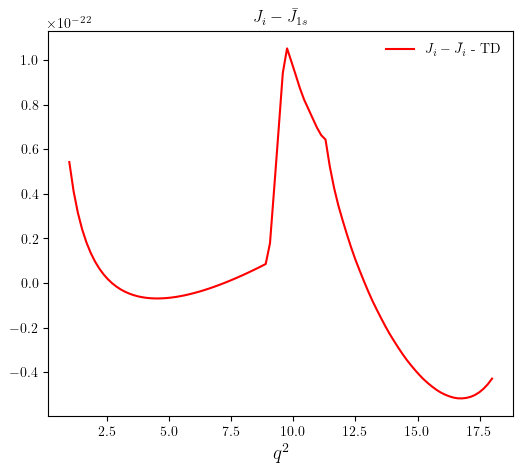

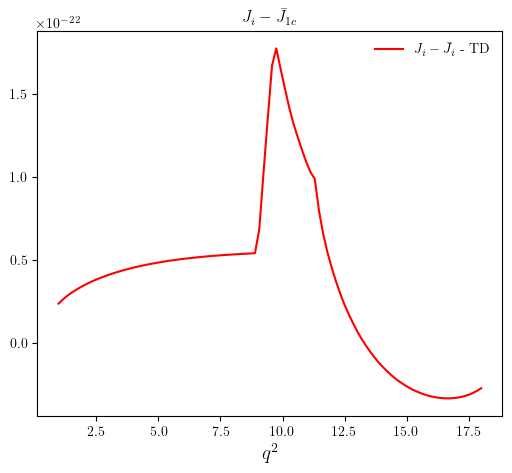

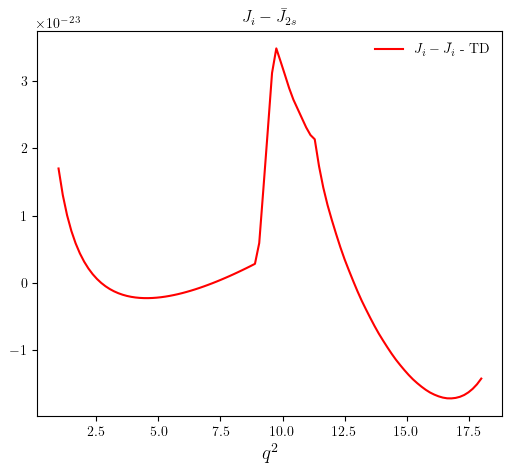

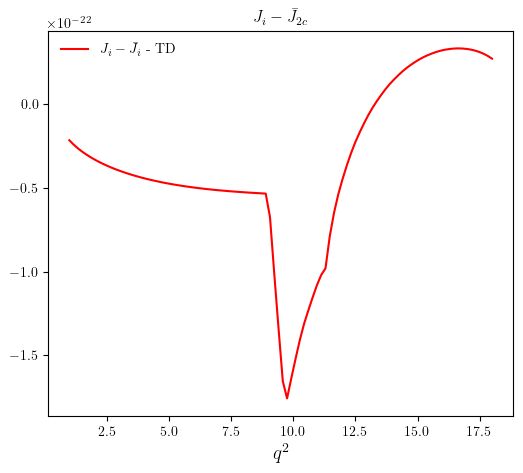

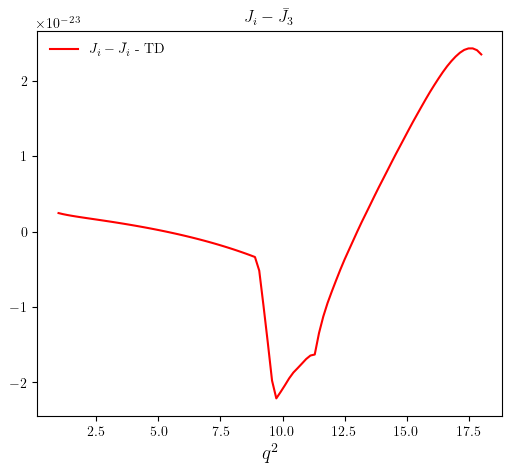

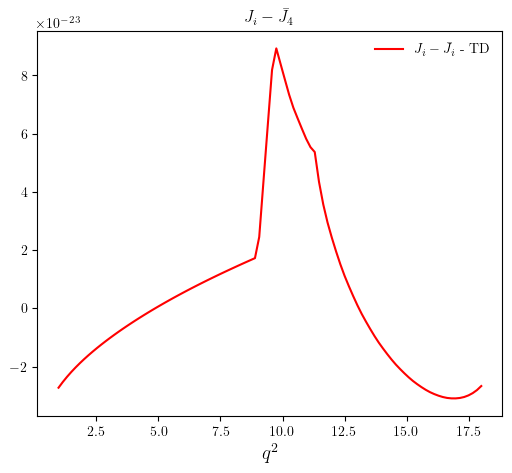

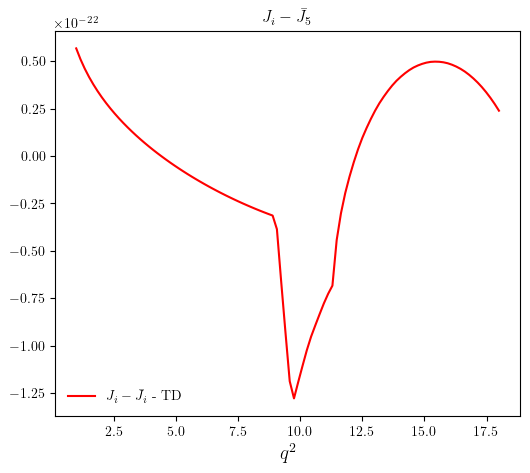

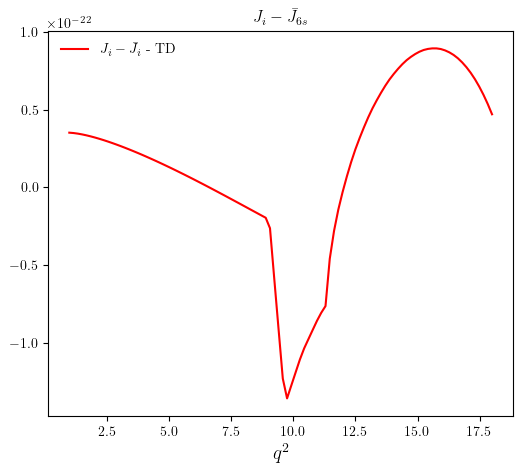

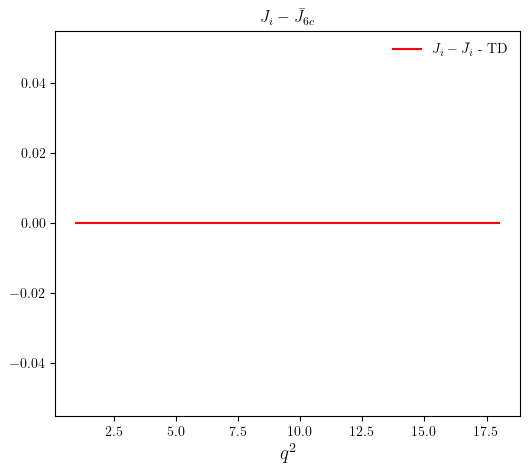

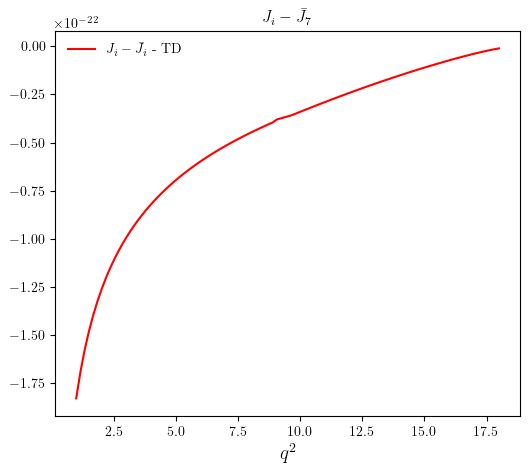

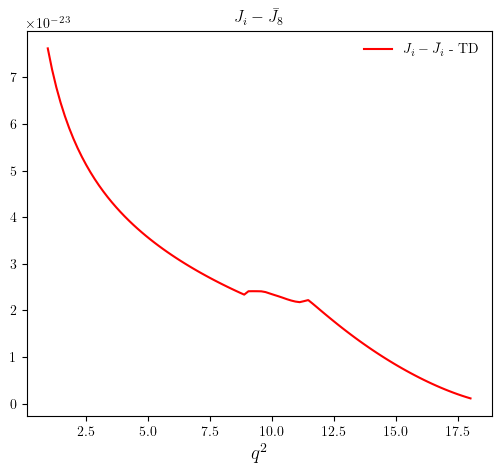

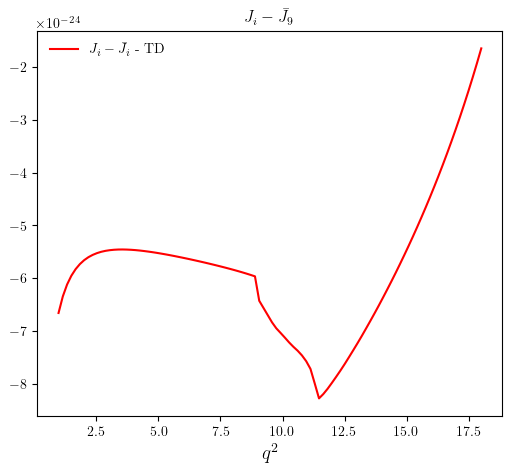

In [26]:
y = 0.0645
x = 26.79
for num in ['1s','1c','2s','2c',3,4,5,'6s','6c',7,8,9]:
#for num in [5]:
    j_std, jbar_std  = [], []
    j_td, jbar_td, j_h_td, j_s_td   = [], [], [] ,[]

    for arr in js_std:
        j_std.append(arr[0][num])
        jbar_std.append(arr[1][num])
    for arr in js_td:
        j_td.append(arr[3][num])
        jbar_td.append(arr[4][num])
        j_h_td.append(arr[5][num])
        j_s_td.append(arr[6][num])
    
    sign = 1
    if num in [4, '6s', '6c', 7, 9]:
        sign = -1
    
    Si_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.S_experiment(J, J_bar, num), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    Si_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    Ai_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.A_experiment(J, J_bar, num), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    Ai_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    j_std, j_td, jbar_std, jbar_td = np.array(j_std),np.array(j_td),np.array(jbar_std),np.array(jbar_td)
    j_h_td, j_s_td = np.array(j_h_td),np.array(j_s_td)
    # the minus sign here is to match FL and S2c
    obs_j_std = sign *  (j_std + jbar_std)/ dGd2_ave_std / 2.
    obs_j_td = sign *  1/(1-y**2) * (j_td - jbar_td)/ dGd2_ave_td / 2.
    obs_h_td = sign * -1 * y*(j_h_td)/ dGd2_ave_td / (1-y**2) / 2.
    
    obs_j_td_2 = sign * (j_td + jbar_td)/ dGd2_ave_td / (1+x**2) / 2.
    obs_s_td = sign *  -1 * x*(j_s_td)/ dGd2_ave_td / (1+x**2) / 2.
    
    norm_x =  sign * dGd2_ave_td * (1+x**2) * 2.
    norm_y =  sign * (1-y**2) * dGd2_ave_td *  2.
    
    if num in [5, '6s', '6c', 8, 9]:
        norm = norm_y
        interf = - y*j_h_td
        interf_name = 'y\cdot J_h'

    else:
        norm = norm_x
        interf = -x*j_s_td
        interf_name = 'x\cdot J_s'


    plt.close('all')
    fig = plt.figure(figsize=figsize)
    # Main plot
    #plt.plot(q2_arr, j_td + jbar_td, label=r'$J_i + \bar{J}_i$ - TD ', color='g')
    plt.plot(q2_arr, j_td - jbar_td, label=r'$J_i - \bar{J}_i$ - TD ', color='r')
    #plt.plot(q2_arr, j_s_td, label=r'$s_i$ - TD', color='k', linestyle='dashed')
    #plt.plot(q2_arr, j_h_td, label=r'$h_i$  - TD ', color='b', linestyle='dashed')

    plt.legend(frameon=False)
    plt.xlabel(r'$q^2$')
    plt.title(r"$J_i - \bar{J}_{"+str(num)+"}$")
    plt.show()
    plt.close('all')
    """
    plt.close('all')
    fig = plt.figure(figsize=figsize)
    # Main plot
    plt.plot(q2_arr, Ai_td, label=r'$A_i$  - TD ', color='g')
    plt.plot(q2_arr, Ai_std, label=r'$A_i$  - std ', color='cyan')
    plt.plot(q2_arr, (j_td - jbar_td) / norm, label=r'$J_i - \bar{J}_i$ - TD ', color='orange')
    plt.plot(q2_arr, - x*j_s_td / norm_x, label=r'$-x \cdot s_i$ - TD', color='k')
    plt.plot(q2_arr, - j_s_td / norm_x, label=r'$-s_i$ - TD', color='k', linestyle='dashed')
    plt.plot(q2_arr, - y*j_h_td / norm_y, label=r'$-y \cdot h_i$ - TD ', color='b')
    plt.plot(q2_arr, - j_h_td / norm_y, label=r'$-h_i$  - TD ', color='b', linestyle='dashed')
    plt.plot(q2_arr, ((j_td - jbar_td) + interf)/ norm, 
             label=r'$(J_i - \bar{J}_i -'+interf_name+')$ - TD ', 
             linestyle='dashed', color='r')
    #plt.plot(q2_arr, obs_j_td + obs_h_td, 
    #         label=r'$(J_i - \bar{J}_i -'+interf_name+')$ - TD ', 
    #         linestyle='dotted', color='r')


    plt.legend(frameon=False)
    plt.xlabel(r'$q^2$')
    plt.title(r"$J_i - \bar{J}_{"+str(num)+"}$")
    plt.show()
    plt.close('all')
    
    if num in [5, '6s', '6c', 8, 9]:
        norm = norm_x
        interf = -x*j_s_td
        interf_name = 'x\cdot J_s'
    else:
        norm = norm_y
        interf = - y*j_h_td
        interf_name = 'y\cdot J_h'
        
    fig = plt.figure(figsize=figsize)
    # Main plot
    plt.plot(q2_arr, Si_td, label=r'$S_i$  - TD ', color='g')
    plt.plot(q2_arr, Si_std / (1+x**2), label=r'$S_i / (1+x^2)$  - std ', color='cyan')
    plt.plot(q2_arr, (j_td + jbar_td) / norm, label=r'$J_i - \bar{J}_i$ - TD ', color='orange')
    plt.plot(q2_arr, - x*j_s_td / norm_x, label=r'$-x \cdot s_i$ - TD', color='k')
    plt.plot(q2_arr, - j_s_td / norm_x, label=r'$-s_i$ - TD', color='k', linestyle='dashed')
    plt.plot(q2_arr, - y*j_h_td / norm_y, label=r'$-y \cdot h_i$ - TD ', color='b')
    plt.plot(q2_arr, - j_h_td / norm_y, label=r'$-h_i$  - TD ', color='b', linestyle='dashed')
    plt.plot(q2_arr, ((j_td + jbar_td) + interf)/ norm, 
             label=r'$(J_i + \bar{J}_i -'+interf_name+')$ - TD ', 
             linestyle='dashed', color='r')

    plt.legend(frameon=False)
    plt.xlabel(r'$q^2$')
    plt.title(r"$J_i + \bar{J}_{"+str(num)+"}$")
    plt.show()
    plt.close('all')
    """

### checking the observables

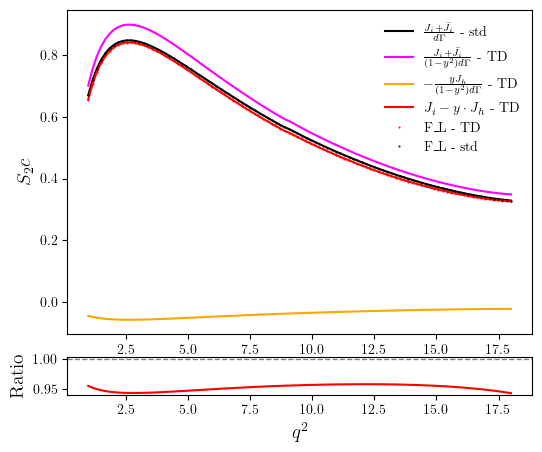

In [27]:
dGd2_ave_std = np.array([observables.BVll_obs(observables.dGdq2_ave, q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
dGd2_ave_td = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_ave_Bs, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
FL_std = np.array([observables.BVll_obs(observables.FL, q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
FL_td = np.array([observables_bs.bsvll_obs( observables_bs.FL_Bs, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

y = 0.0645

for num in ['2c']:
    j_std, jbar_std  = [], []
    j_td, jbar_td, j_h_td, j_s_td   = [], [], [] ,[]

    for arr in js_std:
        j_std.append(arr[0][num])
        jbar_std.append(arr[1][num])
    for arr in js_td:
        j_td.append(arr[3][num])
        jbar_td.append(arr[4][num])
        j_h_td.append(arr[5][num])
        j_s_td.append(arr[6][num])
    
    j_std, j_td, jbar_std, jbar_td = np.array(j_std),np.array(j_td),np.array(jbar_std),np.array(jbar_td)
    j_h_td = np.array(j_h_td)
    # the minus sign here is to match FL and S2c
    obs_j_std = -1 * (j_std + jbar_std)/ dGd2_ave_std / 2.
    obs_j_td = -1 * (j_td + jbar_td)/ dGd2_ave_td / (1-y**2) / 2.
    obs_h_td = -1 * y*(j_h_td)/ dGd2_ave_td / (1-y**2) / 2.
    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    ax1.errorbar(q2_arr, FL_td, label=r'F_L - TD ', color='r', fmt='.', markersize=1)
    ax1.errorbar(q2_arr, FL_std, label=r'F_L - std', color='k', fmt='.', markersize=1)
    
    ax1.plot(q2_arr, obs_j_std, label=r'$\frac{J_i+\bar{J}_i}{d\Gamma}$ - std', color='k')
    ax1.plot(q2_arr, obs_j_td, label=r'$\frac{J_i+\bar{J}_i}{(1-y^2)d\Gamma}$ - TD ', color='magenta')
    ax1.plot(q2_arr, -obs_h_td, label=r'$-\frac{y J_h}{(1-y^2)d\Gamma}$ - TD ', color='orange')
    ax1.plot(q2_arr, obs_j_td - obs_h_td, label=r'$J_i - y\cdot J_h$ - TD ', color='r')


    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel(f'$S_{num}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = np.array(obs_j_std) / np.array(obs_j_td)
    ax2.plot(q2_arr, ratio, label='Ratio (TD/std)', color='r')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

    plt.show()

/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/qcdf_interpolate.py:33: UserWarning: The QCDF corrections should not be trusted for q2 above 6 GeV^2
  warnings.warn("The QCDF corrections should not be trusted for q2 above 6 GeV^2")
/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:74: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:83: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")


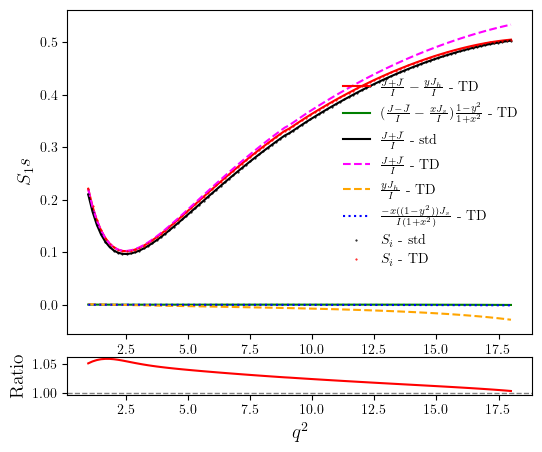

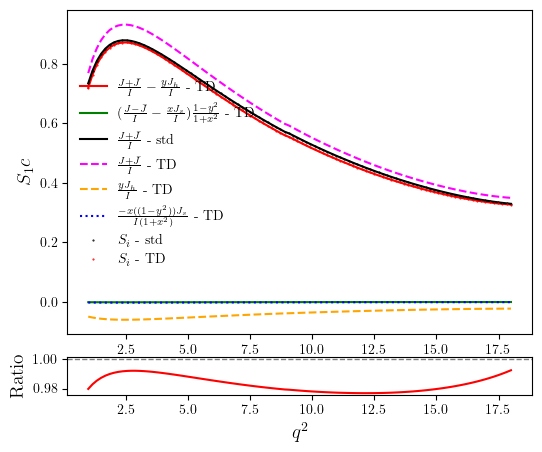

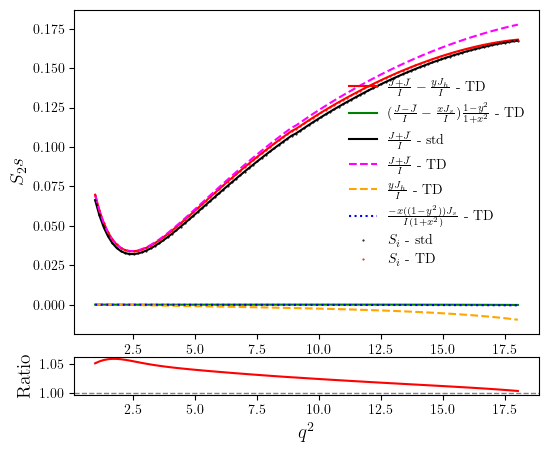

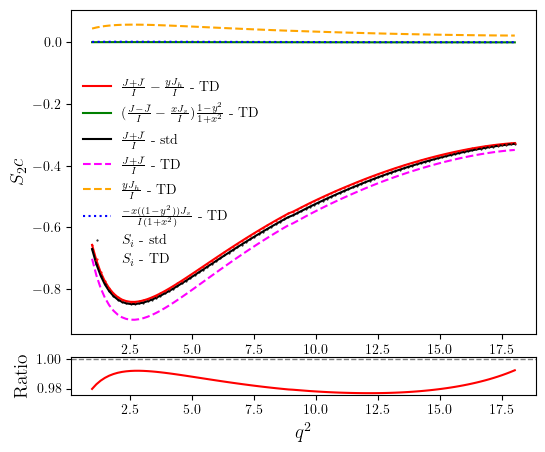

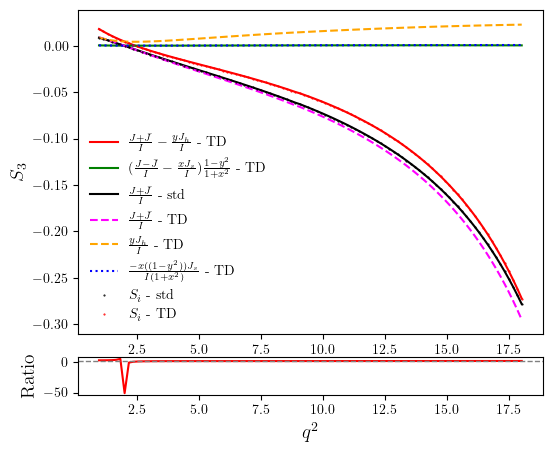

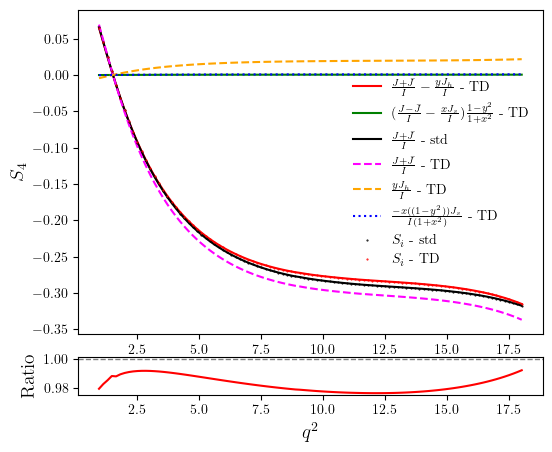

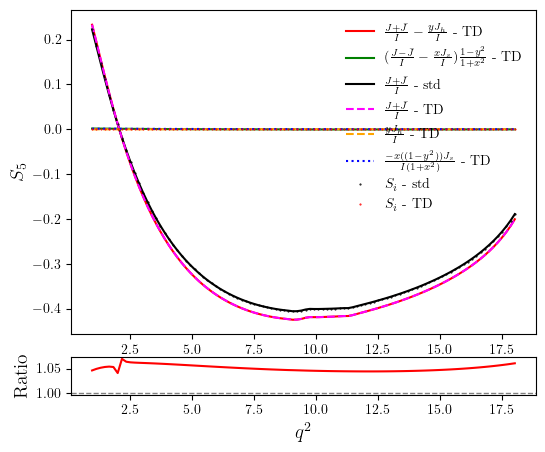

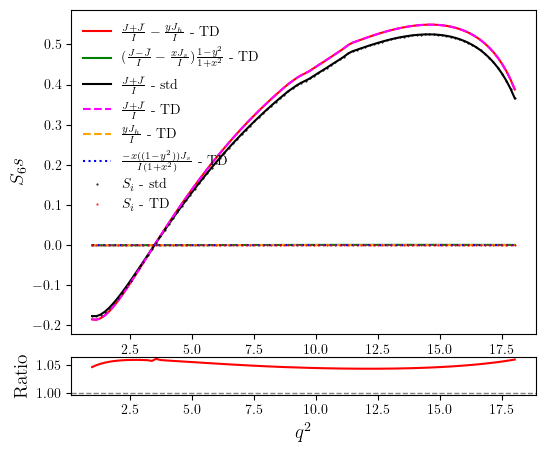

/var/folders/pt/q6q_m4313p5d5m48325ysw1c0000gn/T/ipykernel_21964/2667806484.py:61: RuntimeWarning: invalid value encountered in divide
  ratio = np.array(obs_j_td + obs_h_td) / np.array(obs_j_std)
/var/folders/pt/q6q_m4313p5d5m48325ysw1c0000gn/T/ipykernel_21964/2667806484.py:62: RuntimeWarning: invalid value encountered in divide
  ratio_2 = np.array(obs_j_td_2 + obs_s_td) / np.array(obs_j_std)


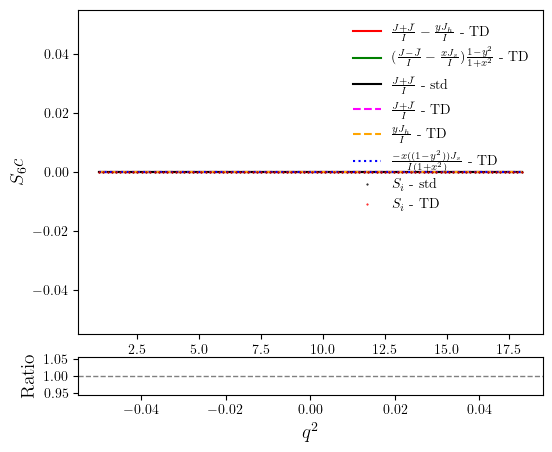

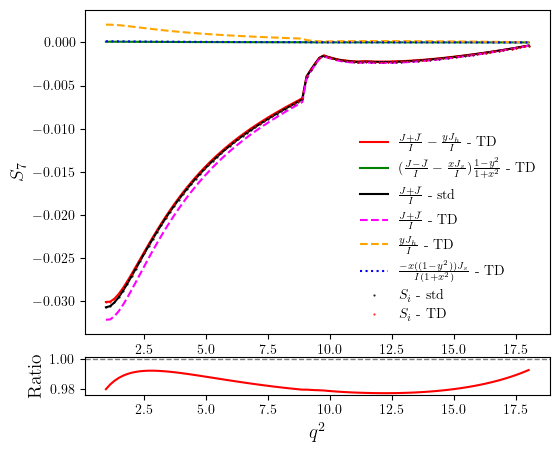

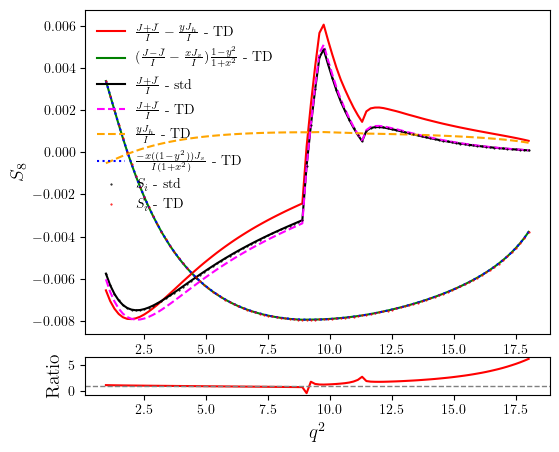

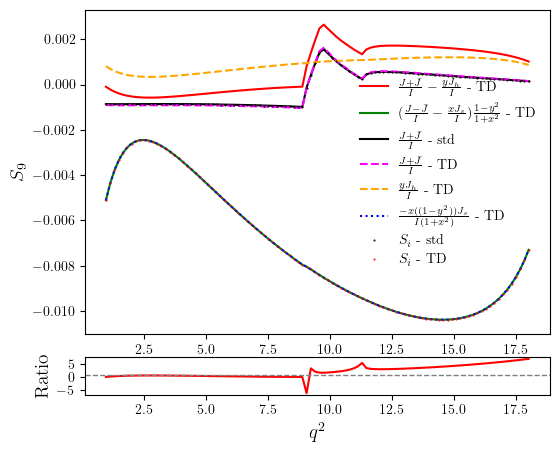

In [29]:
dGd2_ave_std = np.array([observables.BVll_obs(observables.dGdq2_ave, q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
dGd2_ave_td = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_ave_Bs, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
y = 0.0645
x = 26.79

for num in ['1s','1c','2s','2c',3,4,5,'6s','6c',7,8,9]:
    sign = 1
    if num in [4, '6s', '6c', 7, 9]:
        sign = -1
    j_std, jbar_std  = [], []
    j_td, jbar_td, j_h_td, j_s_td   = [], [], [] ,[]

    for arr in js_std:
        j_std.append(arr[0][num])
        jbar_std.append(arr[1][num])
    for arr in js_td:
        j_td.append(arr[3][num])
        jbar_td.append(arr[4][num])
        j_h_td.append(arr[5][num])
        j_s_td.append(arr[6][num])
    
    Si_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.S_experiment(J, J_bar, num), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    Si_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h, J_s: observables_bs.S_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

        
    j_std, j_td, jbar_std, jbar_td = np.array(j_std),np.array(j_td),np.array(jbar_std),np.array(jbar_td)
    j_h_td, j_s_td = np.array(j_h_td),np.array(j_s_td)
    
    obs_j_std = sign *  (j_std + jbar_std)/ dGd2_ave_std / 2.
    obs_j_td = sign *  (j_td + jbar_td)/ dGd2_ave_td / (1-y**2) / 2.
    obs_h_td = sign * -1 * y*(j_h_td)/ dGd2_ave_td / (1-y**2) / 2.
    
    obs_j_td_2 = sign * (j_td + jbar_td)/ dGd2_ave_td / (1+x**2) / 2.
    obs_s_td = sign *  -1 * x*(j_s_td)/ dGd2_ave_td / (1+x**2) / 2.

    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    
    ax1.plot(q2_arr, obs_j_td + obs_h_td, label=r'$\frac{J + \bar{J}}{I} - \frac{y J_h}{I}$ - TD ', color='r')
    ax1.plot(q2_arr, obs_j_td_2 + obs_s_td, label=r'$(\frac{J - \bar{J}}{I} - \frac{x J_s}{I}) \frac{1-y^2}{1+x^2}$ - TD ', color='g')
 
    ax1.plot(q2_arr, obs_j_std, label=r'$\frac{J + \bar{J}}{I}$ - std', color='k')
    ax1.plot(q2_arr, obs_j_td, label=r'$\frac{J + \bar{J}}{I}$ - TD ', color='magenta', linestyle='dashed')
    ax1.plot(q2_arr, obs_h_td, label=r'$\frac{y J_h}{I}$ - TD ', color='orange', linestyle='dashed')
    ax1.plot(q2_arr, obs_s_td, label=r'$\frac{-x ((1-y^2)) J_s}{I(1+x^2)}$ - TD ', color='blue', linestyle='dotted')
    
    ax1.errorbar(q2_arr, Si_std, label=r'$S_i$ - std', color='k', fmt='.', markersize=1)
    ax1.errorbar(q2_arr, Si_td, label=r'$S_i$ - TD', color='r', fmt='.', markersize=1)
   

    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel(f'$S_{num}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = np.array(obs_j_td + obs_h_td) / np.array(obs_j_std)
    ratio_2 = np.array(obs_j_td_2 + obs_s_td) / np.array(obs_j_std)
    ax2.plot(q2_arr, ratio, label='Ratio (TD/std)', color='r')
    #ax2.plot(q2_arr, ratio_2, label='Ratio (TD/std)', color='g')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

    plt.show()

In [ ]:
j_td


### try to check the K and H variables

/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/qcdf_interpolate.py:33: UserWarning: The QCDF corrections should not be trusted for q2 above 6 GeV^2
  warnings.warn("The QCDF corrections should not be trusted for q2 above 6 GeV^2")
/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:74: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:83: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")


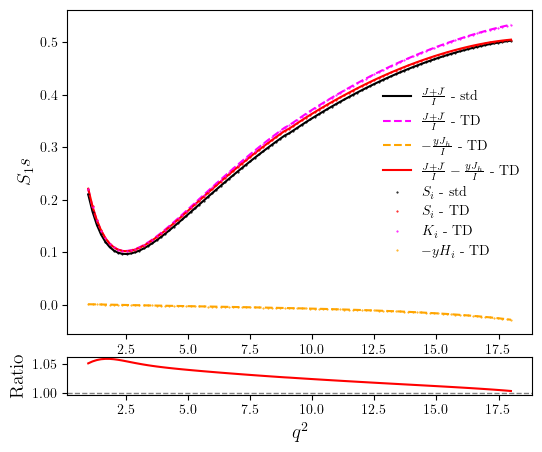

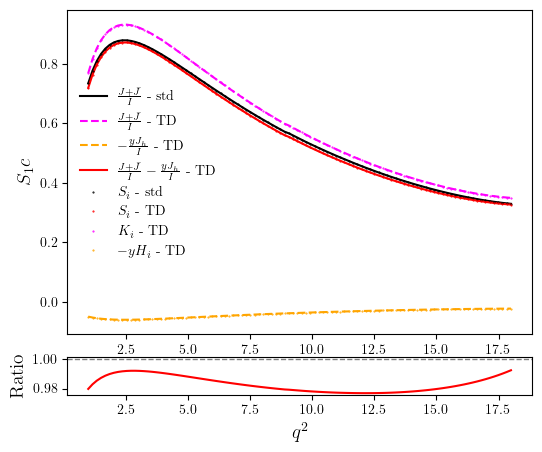

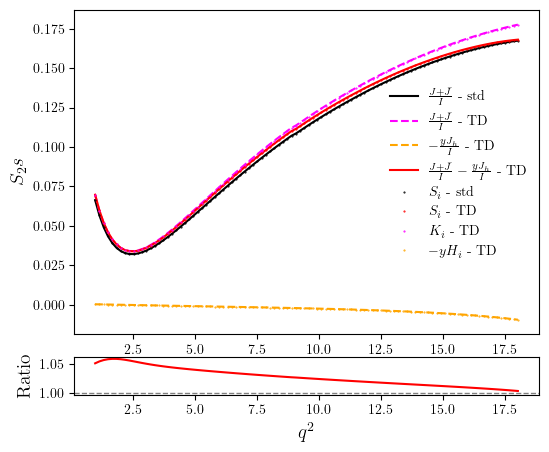

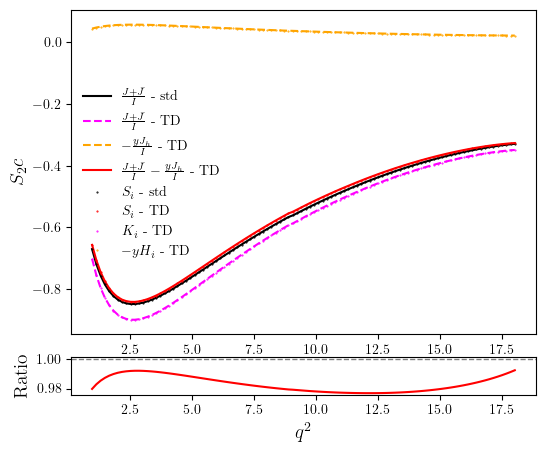

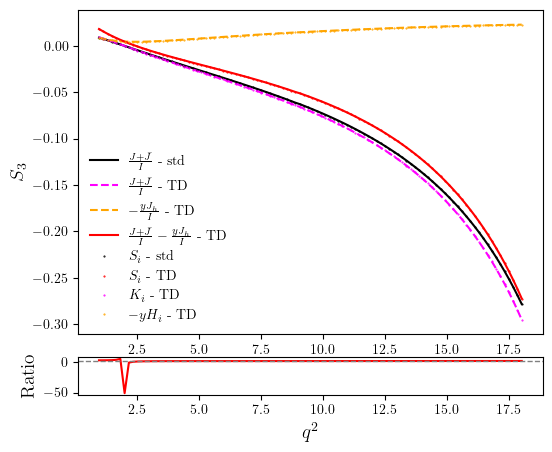

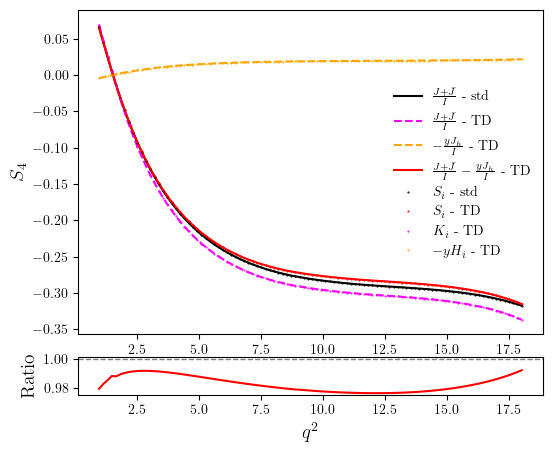

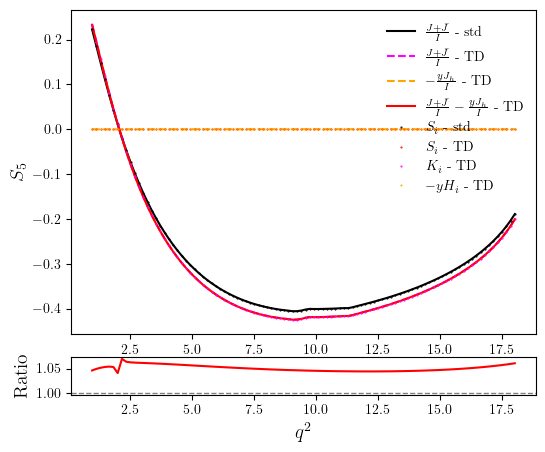

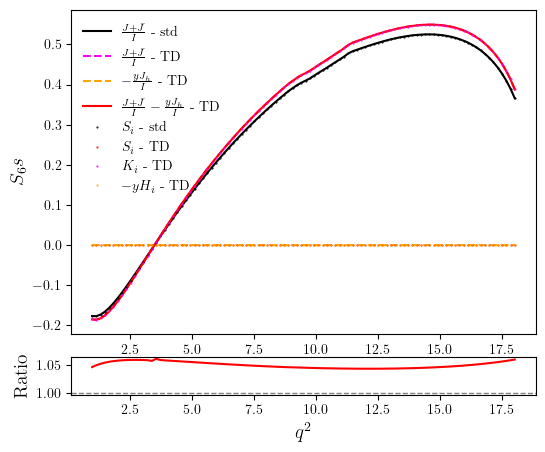

/var/folders/pt/q6q_m4313p5d5m48325ysw1c0000gn/T/ipykernel_21964/2924997053.py:57: RuntimeWarning: invalid value encountered in divide
  ratio = np.array(obs_j_td + obs_h_td) / np.array(obs_j_std)


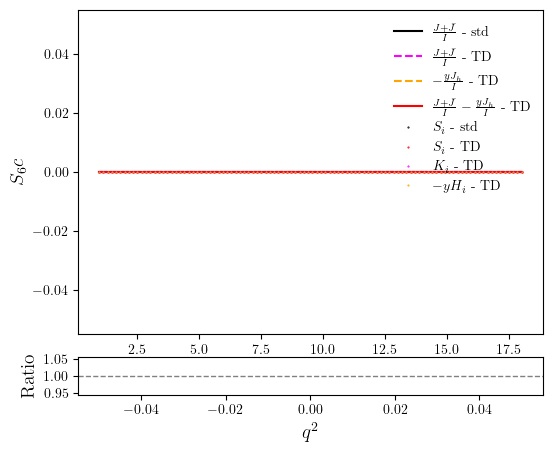

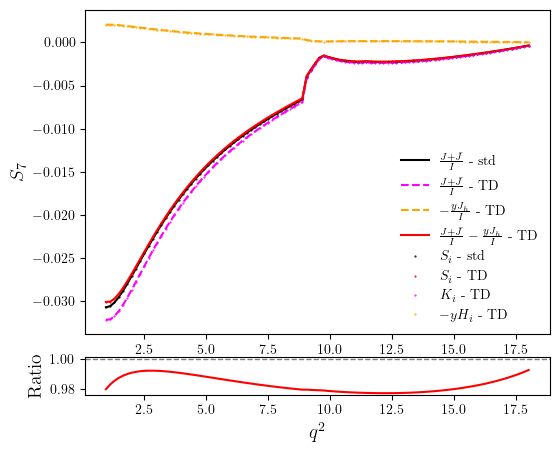

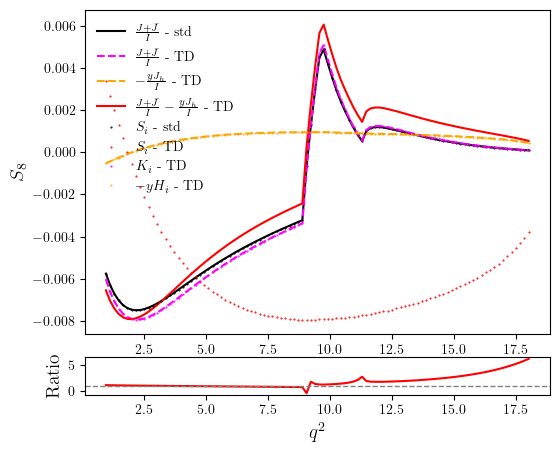

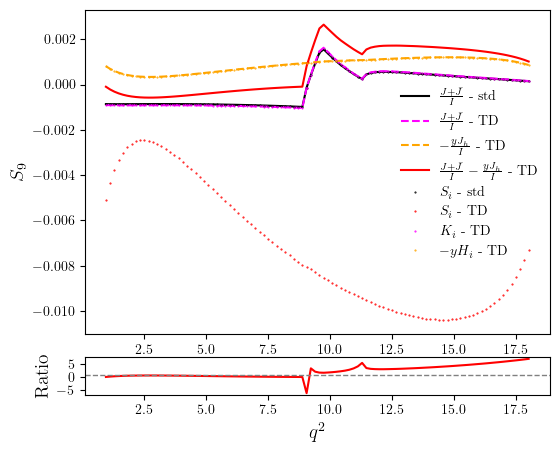

In [31]:
dGd2_ave_std = np.array([observables.BVll_obs(observables.dGdq2_ave, q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
dGd2_ave_td = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_ave_Bs, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
y = 0.0645
for num in ['1s','1c','2s','2c',3,4,5,'6s','6c',7,8,9]:
    sign = 1
    if num in [4, '6s', '6c', 7, 9]:
        sign = -1
    j_std, jbar_std  = [], []
    j_td, jbar_td, j_h_td, j_s_td   = [], [], [] ,[]

    for arr in js_std:
        j_std.append(arr[0][num])
        jbar_std.append(arr[1][num])
    for arr in js_td:
        j_td.append(arr[3][num])
        jbar_td.append(arr[4][num])
        j_h_td.append(arr[5][num])
        j_s_td.append(arr[6][num])
    
    Si_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.S_experiment(J, J_bar, num), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    Si_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    
    Ki_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.K_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    Hi_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.H_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

        
    j_std, j_td, jbar_std, jbar_td = np.array(j_std),np.array(j_td),np.array(jbar_std),np.array(jbar_td)
    j_h_td = np.array(j_h_td)
    obs_j_std = sign *  (j_std + jbar_std)/ dGd2_ave_std / 2.
    obs_j_td = sign *  (j_td + jbar_td)/ dGd2_ave_td / (1-y**2) / 2.
    obs_h_td = sign * -1 * y*(j_h_td)/ dGd2_ave_td / (1-y**2) / 2.
    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    
     
    ax1.plot(q2_arr, obs_j_std, label=r'$\frac{J + \bar{J}}{I}$ - std', color='k')
    ax1.plot(q2_arr, obs_j_td, label=r'$\frac{J + \bar{J}}{I}$ - TD ', color='magenta', linestyle='dashed')
    ax1.plot(q2_arr, obs_h_td, label=r'$-\frac{y J_h}{I}$ - TD ', color='orange', linestyle='dashed')
    ax1.plot(q2_arr, obs_j_td + obs_h_td, label=r'$\frac{J + \bar{J}}{I} - \frac{y J_h}{I}$ - TD ', color='r')

    ax1.errorbar(q2_arr, Si_std, label=r'$S_i$ - std', color='k', fmt='.', markersize=1)
    ax1.errorbar(q2_arr, Si_td, label=r'$S_i$ - TD', color='r', fmt='.', markersize=1)
    ax1.errorbar(q2_arr, Ki_td, label=r'$K_i$ - TD', color='magenta', fmt='.', markersize=1)
    ax1.errorbar(q2_arr, -y*Hi_td, label=r'$-y H_i$ - TD', color='orange', fmt='.', markersize=1)
   

    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel(f'$S_{num}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = np.array(obs_j_td + obs_h_td) / np.array(obs_j_std)
    ax2.plot(q2_arr, ratio, label='Ratio (TD/std)', color='r')

    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

    plt.show()

/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/qcdf_interpolate.py:33: UserWarning: The QCDF corrections should not be trusted for q2 above 6 GeV^2
  warnings.warn("The QCDF corrections should not be trusted for q2 above 6 GeV^2")
/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:74: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:83: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")


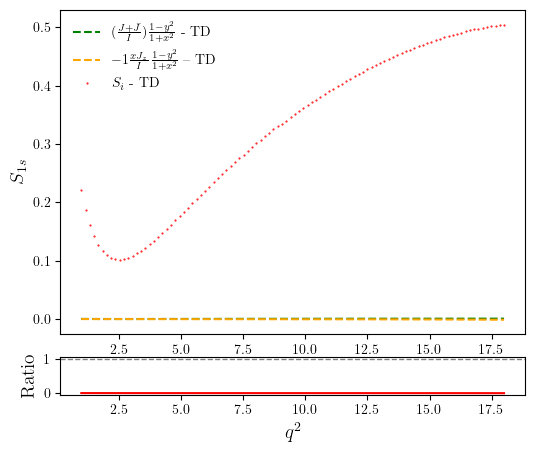

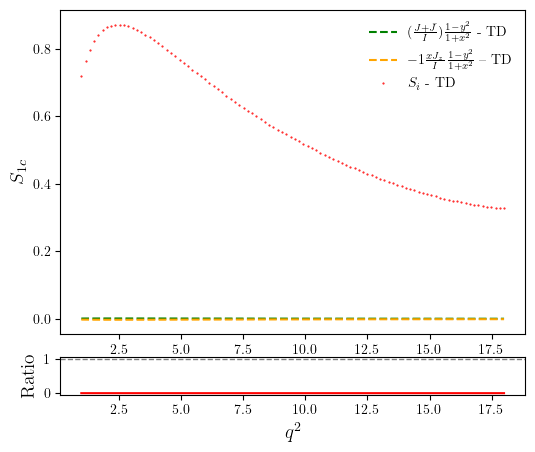

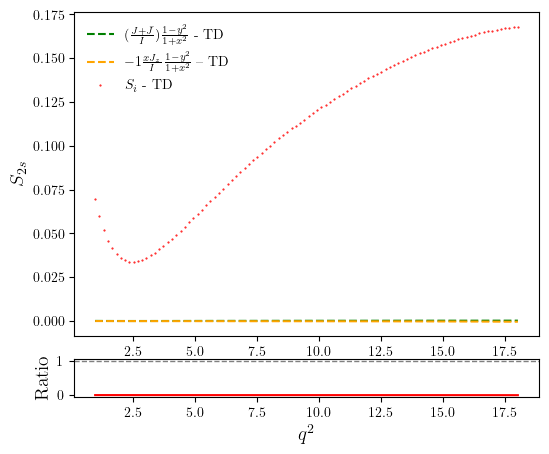

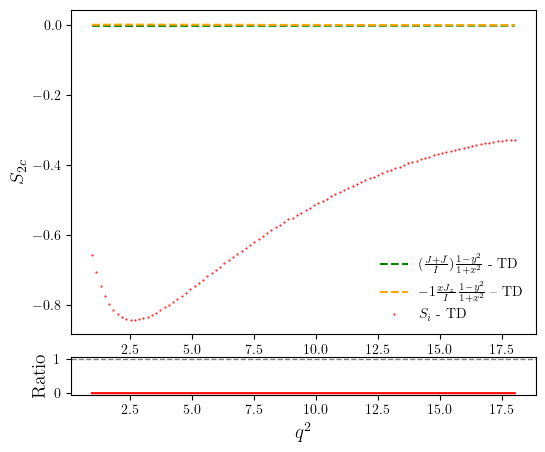

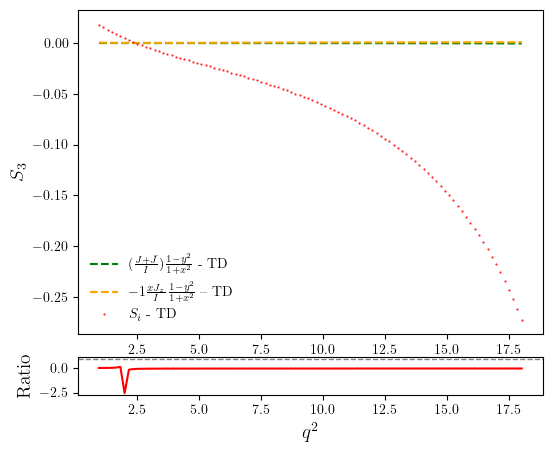

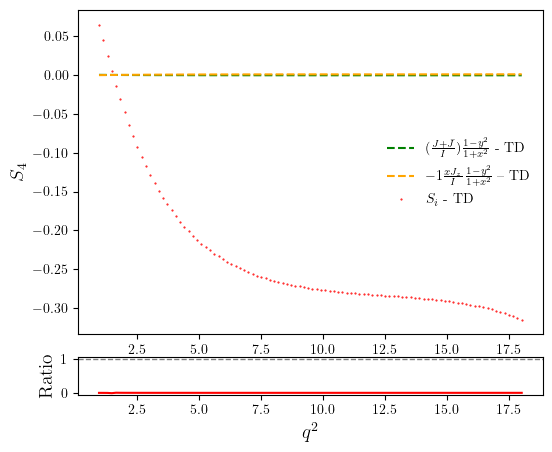

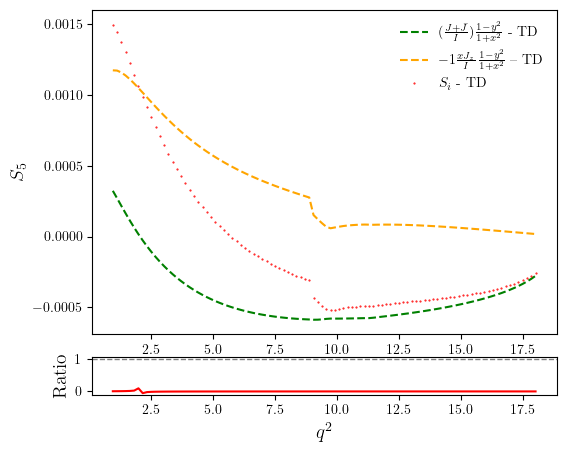

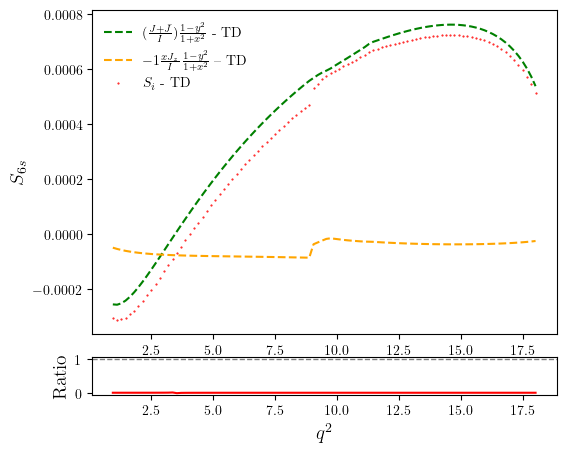

/var/folders/pt/q6q_m4313p5d5m48325ysw1c0000gn/T/ipykernel_21964/241260913.py:71: RuntimeWarning: invalid value encountered in divide
  ratio = np.array(obs_j_td + obs_s_td) / np.array(obs_j_std)


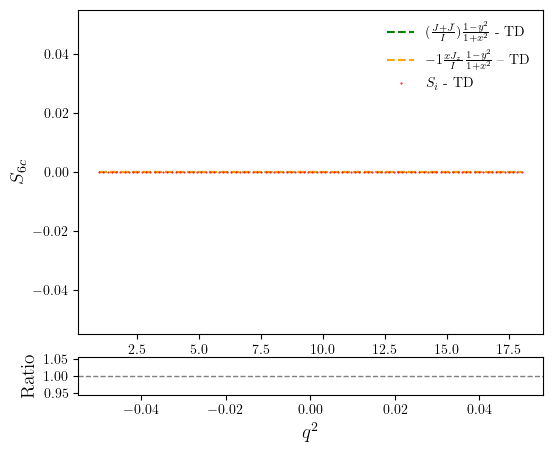

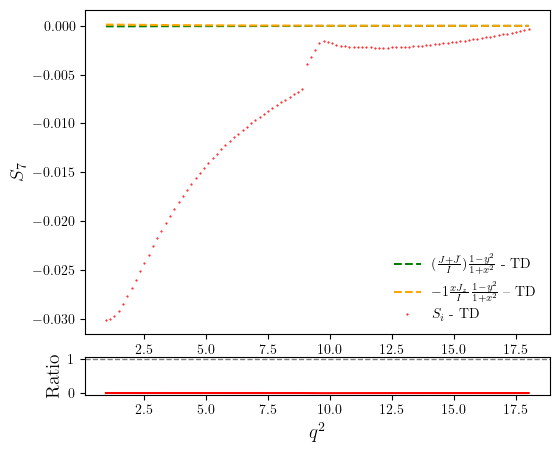

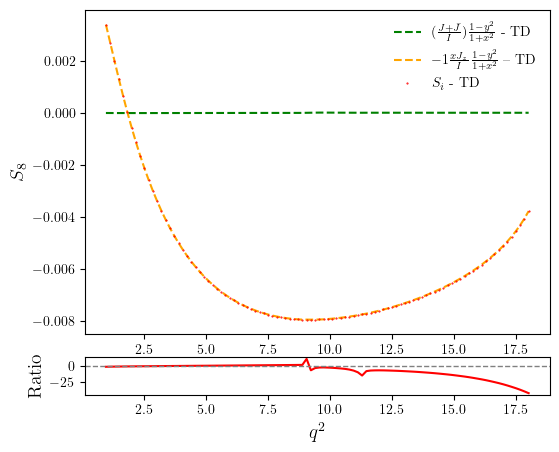

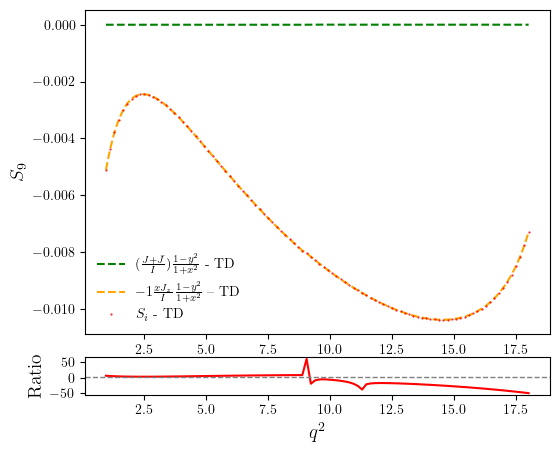

In [32]:
dGd2_ave_std = np.array([observables.BVll_obs(observables.dGdq2_ave, q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
dGd2_ave_td = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_ave_Bs, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
y = 0.0645
x = 26.79
for num in ['1s','1c','2s','2c',3,4,5,'6s','6c',7,8,9]:
#for num in [5]:
    sign = 1
    if num in [4, '6s', '6c', 7, 9]:
        sign = -1
    j_std, jbar_std  = [], []
    j_td, jbar_td, j_h_td, j_s_td   = [], [], [] ,[]

    for arr in js_std:
        j_std.append(arr[0][num])
        jbar_std.append(arr[1][num])
    for arr in js_td:
        j_td.append(arr[3][num])
        jbar_td.append(arr[4][num])
        j_h_td.append(arr[5][num])
        j_s_td.append(arr[6][num])
        
    Ai_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.S_experiment(J, J_bar, num), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    Ai_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    Wi_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.W_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    Hi_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.H_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    Ki_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.K_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    Zi_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.Z_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    j_std, j_td, jbar_std, jbar_td = np.array(j_std),np.array(j_td),np.array(jbar_std),np.array(jbar_td)
    j_h_td, j_s_td = np.array(j_h_td),np.array(j_s_td)
    
    obs_j_std = sign * (j_std + jbar_std)/ dGd2_ave_std / 2.
    obs_j_td = sign * (j_td + jbar_td)/ dGd2_ave_td / (1+x**2) / 2.
    obs_s_td = sign *  -1 * x*(j_s_td)/ dGd2_ave_td / (1+x**2) / 2.

    obs_h_td = sign * -1 * y*(j_h_td)/ dGd2_ave_td / (1-y**2) / 2.
    obs_j_td_2 = sign *  (j_td + jbar_td)/ dGd2_ave_td / (1-y**2) / 2.

    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    
    #ax1.plot(q2_arr, obs_j_std, label=r'$\frac{J_i+\bar{J}_i}{d\Gamma/dq^2}$ - std', color='k')
    ax1.plot(q2_arr, obs_j_td, label=r'$(\frac{J + \bar{J}}{I}) \frac{1-y^2}{1+x^2}$ - TD ', color='g', linestyle='dashed')
    #ax1.plot(q2_arr, obs_j_td_2, label=r'$(\frac{J + \bar{J}}{I})$ - TD ', color='b', linestyle='dashed')
    
    #ax1.plot(q2_arr, obs_j_td + obs_s_td, label=r'$(\frac{J - \bar{J}}{I} - \frac{x J_s}{I}) \frac{1-y^2}{1+x^2}$ - TD ', color='r')
    #ax1.plot(q2_arr, obs_j_td_2 + obs_h_td, label=r'$(\frac{J - \bar{J}}{I} - \frac{y J_h}{I})$ - TD ', color='g')
    #ax1.plot(q2_arr, obs_j_td, label=r'$\frac{J - \bar{J}}{I} \frac{1-y^2}{1+x^2}$ - TD ', color='magenta', linestyle='dashed')
    #ax1.plot(q2_arr, obs_j_td_2, label=r'$\frac{J - \bar{J}}{I} \frac{1}{1-y^2}$ - TD ', color='magenta', linestyle='dashed')
    ax1.plot(q2_arr, obs_s_td, label=r'$ -1 \frac{x J_z}{I} \frac{1-y^2}{1+x^2}$ -- TD ', color='orange', linestyle='dashed')
    #ax1.plot(q2_arr, obs_h_td, label=r'$ -1 \frac{y J_z}{I}$ -- TD ', color='red', linestyle='dashed')

    #ax1.errorbar(q2_arr, Ai_std, label=r'$S_i$ - std', color='k', fmt='.', markersize=1)
    ax1.errorbar(q2_arr, Ai_td, label=r'$S_i$ - TD', color='r', fmt='.', markersize=1)
   
    #ax1.errorbar(q2_arr, Wi_td, label=r'$W_i$ - TD', color='magenta', fmt='.', markersize=1)
    #ax1.errorbar(q2_arr, Hi_td, label=r'$H_i$ - TD', color='orange', fmt='.', markersize=1)
    #ax1.errorbar(q2_arr, Wi_td + Hi_td, label=r' - TD', color='orange', fmt='.', markersize=1)
    
    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel('$S_{'+str(num)+'}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = np.array(obs_j_td + obs_s_td) / np.array(obs_j_std)
    ax2.plot(q2_arr, ratio, label='Ratio (TD/std)', color='r')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

    plt.show()

## Check asymmetries

/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/qcdf_interpolate.py:33: UserWarning: The QCDF corrections should not be trusted for q2 above 6 GeV^2
  warnings.warn("The QCDF corrections should not be trusted for q2 above 6 GeV^2")
/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:74: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:83: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")


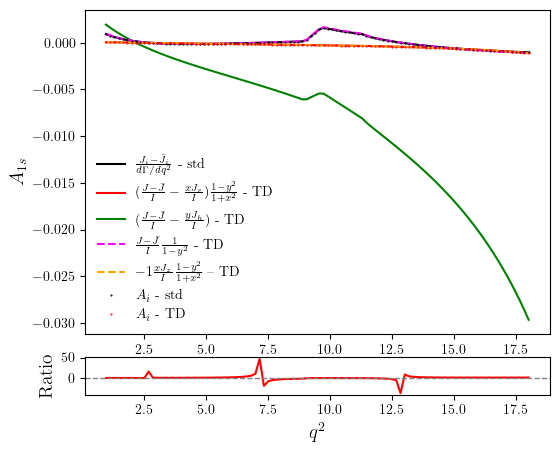

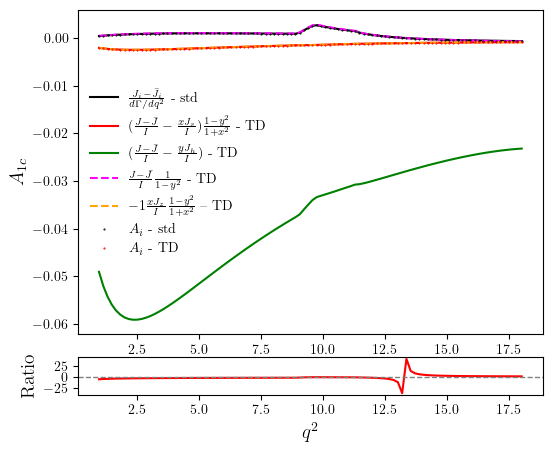

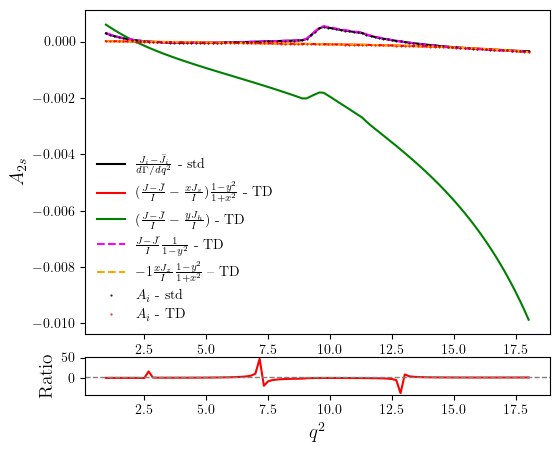

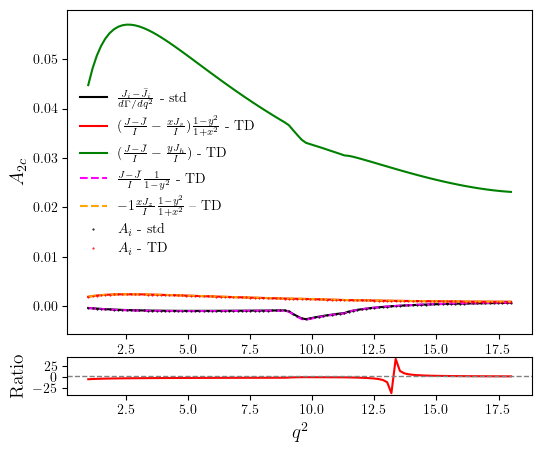

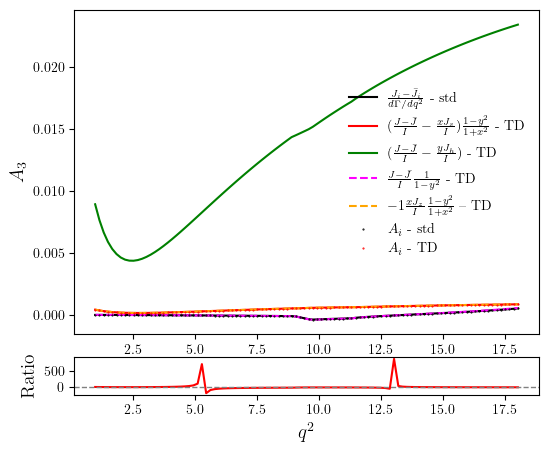

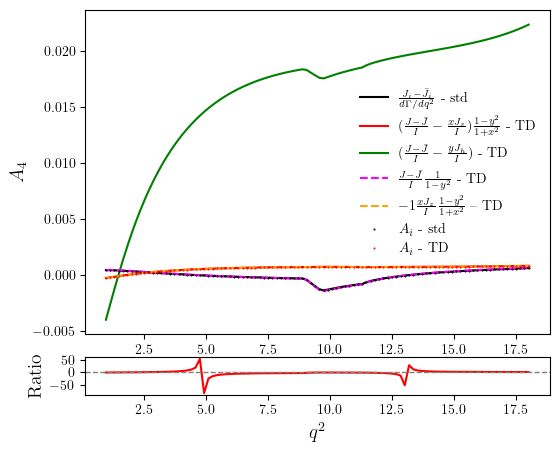

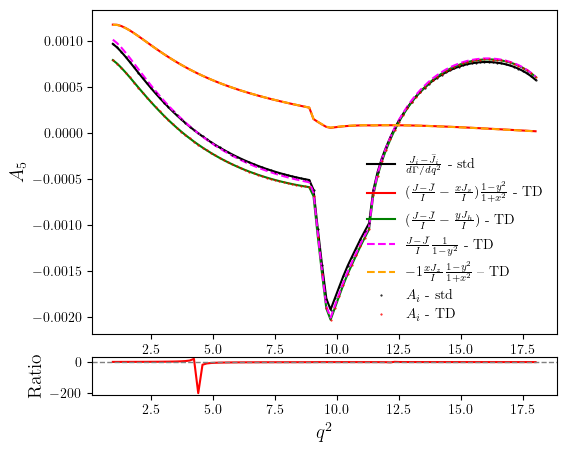

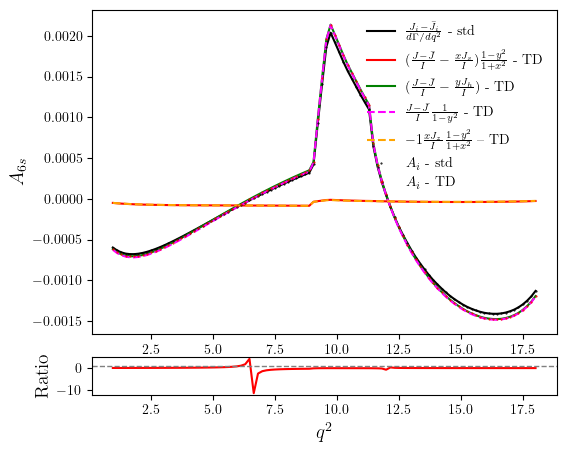

/var/folders/pt/q6q_m4313p5d5m48325ysw1c0000gn/T/ipykernel_21964/3716255894.py:65: RuntimeWarning: invalid value encountered in divide
  ratio = np.array(obs_j_td + obs_s_td) / np.array(obs_j_std)


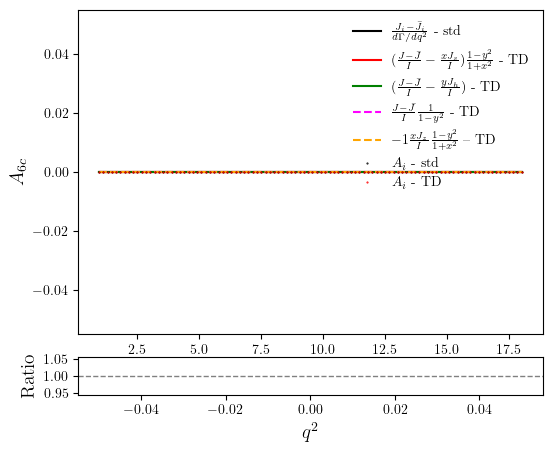

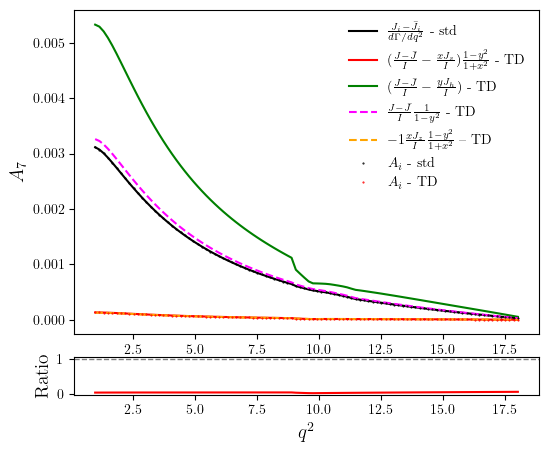

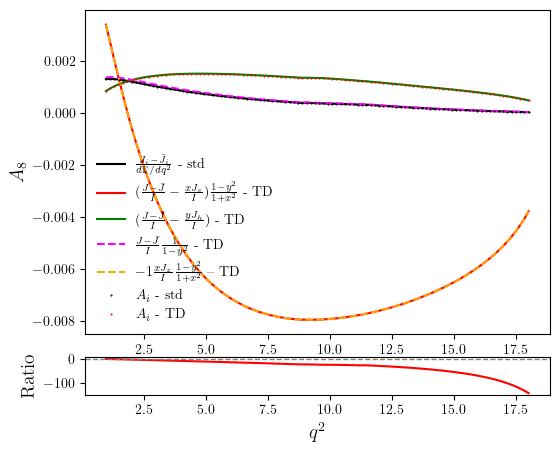

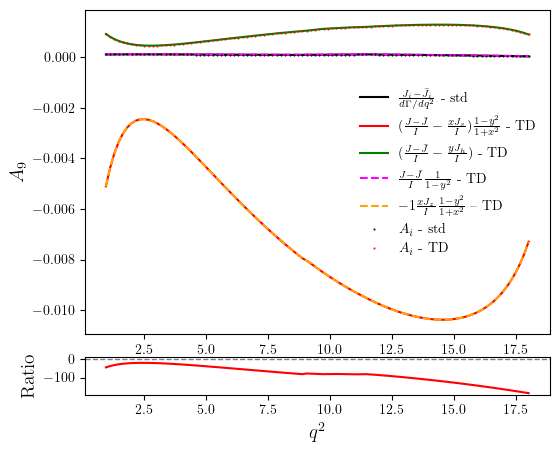

In [33]:
dGd2_ave_std = np.array([observables.BVll_obs(observables.dGdq2_ave, q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
dGd2_ave_td = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_ave_Bs, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
y = 0.0645
x = 26.79
for num in ['1s','1c','2s','2c',3,4,5,'6s','6c',7,8,9]:
#for num in [5]:
    sign = 1
    if num in [4, '6s', '6c', 7, 9]:
        sign = -1
    j_std, jbar_std  = [], []
    j_td, jbar_td, j_h_td, j_s_td   = [], [], [] ,[]

    for arr in js_std:
        j_std.append(arr[0][num])
        jbar_std.append(arr[1][num])
    for arr in js_td:
        j_td.append(arr[3][num])
        jbar_td.append(arr[4][num])
        j_h_td.append(arr[5][num])
        j_s_td.append(arr[6][num])
        
    Ai_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.A_experiment(J, J_bar, num), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    Ai_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    Wi_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.W_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    Hi_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.H_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    j_std, j_td, jbar_std, jbar_td = np.array(j_std),np.array(j_td),np.array(jbar_std),np.array(jbar_td)
    j_h_td, j_s_td = np.array(j_h_td),np.array(j_s_td)
    
    obs_j_std = sign * (j_std - jbar_std)/ dGd2_ave_std / 2.
    obs_j_td = sign * (j_td - jbar_td)/ dGd2_ave_td / (1+x**2) / 2.
    obs_s_td = sign *  -1 * x*(j_s_td)/ dGd2_ave_td / (1+x**2) / 2.

    obs_h_td = sign * -1 * y*(j_h_td)/ dGd2_ave_td / (1-y**2) / 2.
    obs_j_td_2 = sign *  (j_td - jbar_td)/ dGd2_ave_td / (1-y**2) / 2.

    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    
    ax1.plot(q2_arr, obs_j_std, label=r'$\frac{J_i-\bar{J}_i}{d\Gamma/dq^2}$ - std', color='k')
    ax1.plot(q2_arr, obs_j_td + obs_s_td, label=r'$(\frac{J - \bar{J}}{I} - \frac{x J_s}{I}) \frac{1-y^2}{1+x^2}$ - TD ', color='r')
    ax1.plot(q2_arr, obs_j_td_2 + obs_h_td, label=r'$(\frac{J - \bar{J}}{I} - \frac{y J_h}{I})$ - TD ', color='g')
    #ax1.plot(q2_arr, obs_j_td, label=r'$\frac{J - \bar{J}}{I} \frac{1-y^2}{1+x^2}$ - TD ', color='magenta', linestyle='dashed')
    ax1.plot(q2_arr, obs_j_td_2, label=r'$\frac{J - \bar{J}}{I} \frac{1}{1-y^2}$ - TD ', color='magenta', linestyle='dashed')
    ax1.plot(q2_arr, obs_s_td, label=r'$ -1 \frac{x J_z}{I} \frac{1-y^2}{1+x^2}$ -- TD ', color='orange', linestyle='dashed')

    ax1.errorbar(q2_arr, Ai_std, label=r'$A_i$ - std', color='k', fmt='.', markersize=1)
    ax1.errorbar(q2_arr, Ai_td, label=r'$A_i$ - TD', color='r', fmt='.', markersize=1)
   
    #ax1.errorbar(q2_arr, Wi_td, label=r'$W_i$ - TD', color='magenta', fmt='.', markersize=1)
    #ax1.errorbar(q2_arr, Hi_td, label=r'$H_i$ - TD', color='orange', fmt='.', markersize=1)
    #ax1.errorbar(q2_arr, Wi_td + Hi_td, label=r' - TD', color='orange', fmt='.', markersize=1)
    
    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel('$A_{'+str(num)+'}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = np.array(obs_j_td + obs_s_td) / np.array(obs_j_std)
    ax2.plot(q2_arr, ratio, label='Ratio (TD/std)', color='r')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

    plt.show()

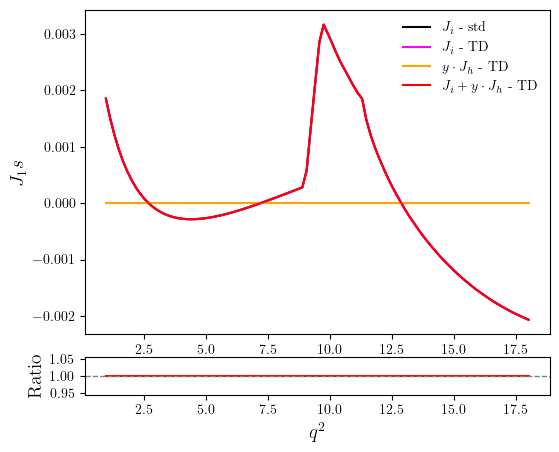

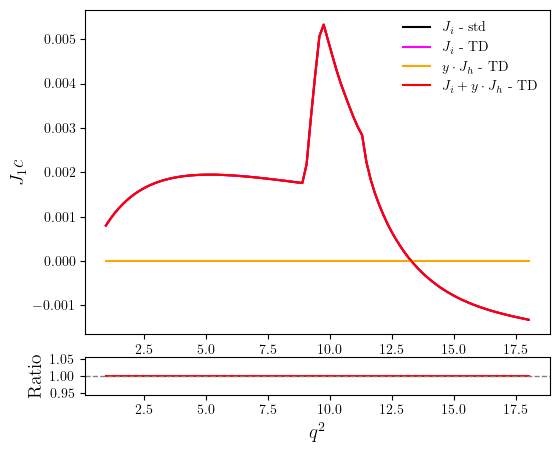

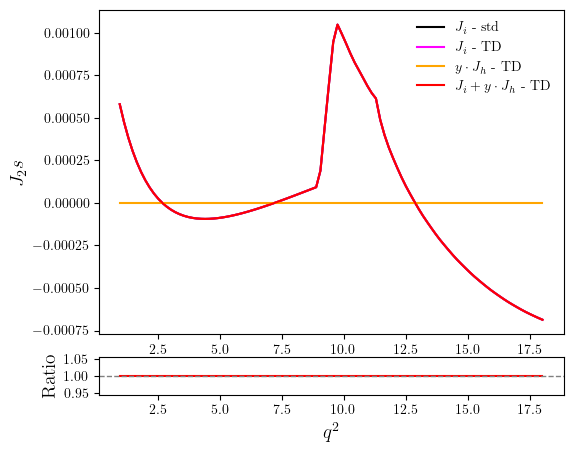

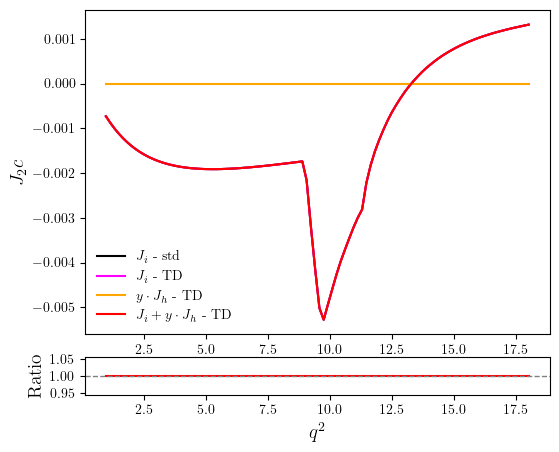

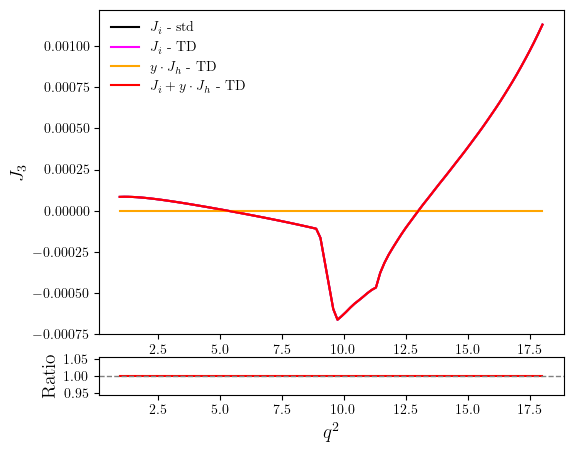

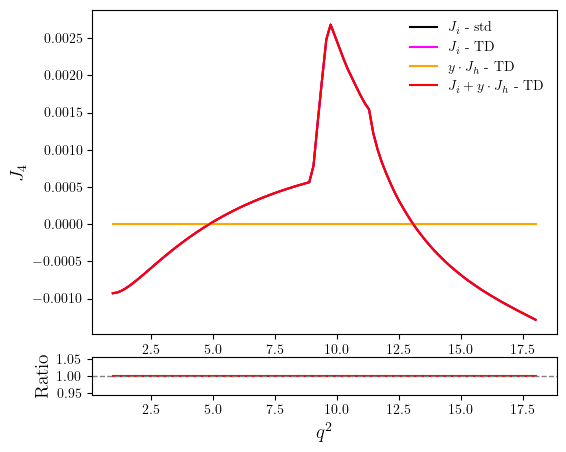

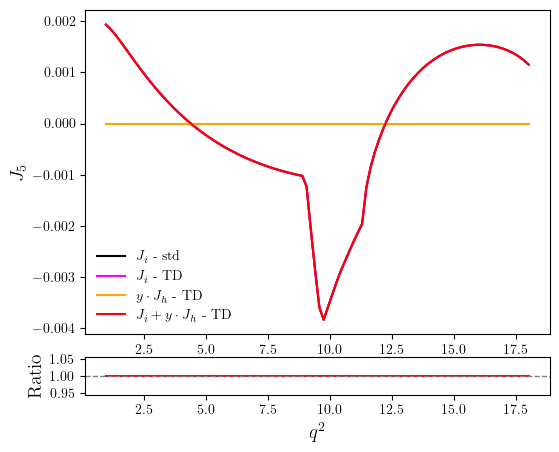

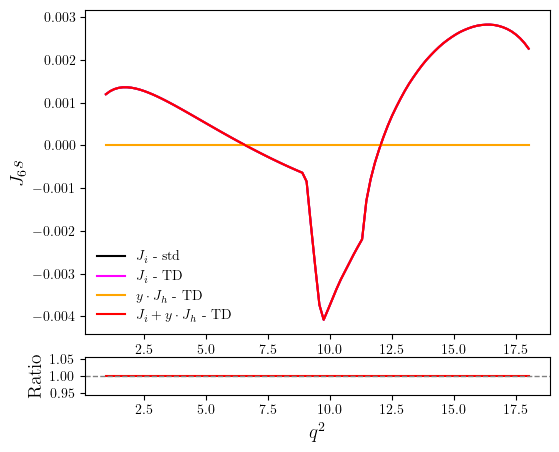

/var/folders/pt/q6q_m4313p5d5m48325ysw1c0000gn/T/ipykernel_21964/2643427508.py:45: RuntimeWarning: invalid value encountered in divide
  ratio = np.array(obs_j_std) / np.array(obs_j_td)


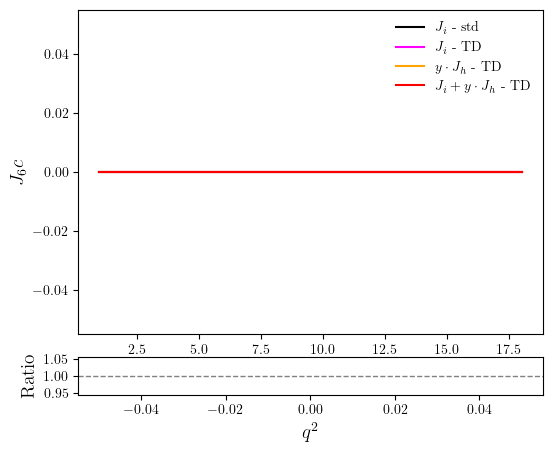

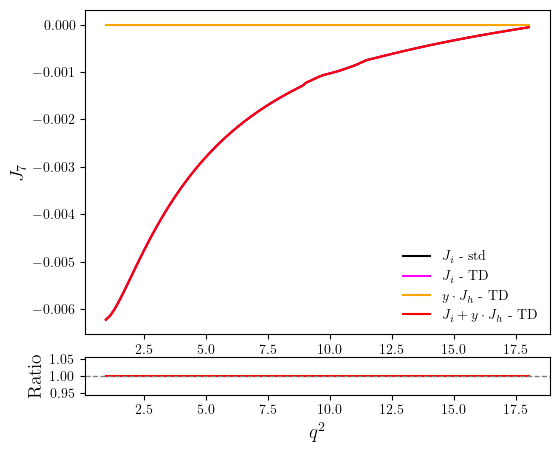

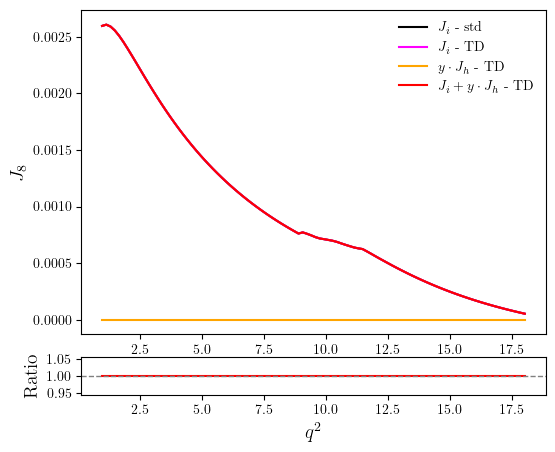

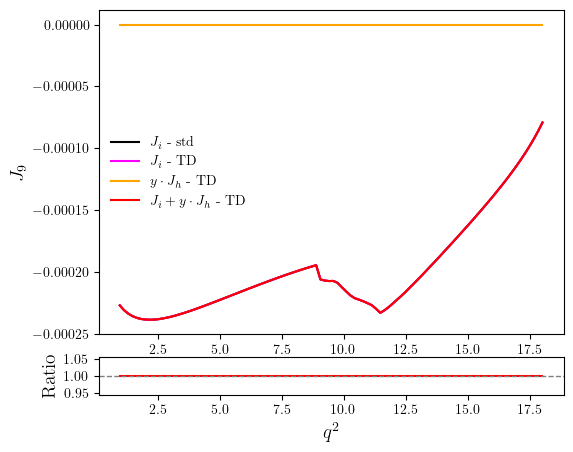

In [34]:
#start studying it in an unbinned way using test_bvll as an example
q2_min, q2_max = 0.98, 18
npoints = 100
q2_arr = np.linspace(q2_min, q2_max, npoints)

js_std = np.array([observables.BVll_obs(get_vector_of_all_Js, q2, B, V, l, wc_obj, par_y0)() for q2 in q2_arr])
js_td = np.array([observables_bs.bsvll_obs(get_vector_of_all_Js_h_and_s, q2, wc_obj, par_y0, B, V, l) for q2 in q2_arr])
dGd2_ave_std = np.array([observables.BVll_obs(observables.dGdq2_ave, q2, B, V, l, wc_obj, par_y0)() for q2 in q2_arr])
dGd2_ave_td = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_ave_Bs, q2, wc_obj, par_y0, B, V, l) for q2 in q2_arr])
y = 0.0
for num in ['1s','1c','2s','2c',3,4,5,'6s','6c',7,8,9]:
    j_std, jbar_std  = [], []
    j_td, jbar_td, j_h_td, j_s_td   = [], [], [] ,[]

    for arr in js_std:
        j_std.append(arr[0][num])
        jbar_std.append(arr[1][num])
    for arr in js_td:
        j_td.append(arr[3][num])
        jbar_td.append(arr[4][num])
        j_h_td.append(arr[5][num])
        j_s_td.append(arr[6][num])
    
    j_std, j_td, jbar_std, jbar_td = np.array(j_std),np.array(j_td),np.array(jbar_std),np.array(jbar_td)
    j_h_td, j_s_td = np.array(j_h_td),np.array(j_s_td)
    obs_j_std = (j_std - jbar_std)/ dGd2_ave_std
    obs_j_td = (j_td - jbar_td)/ dGd2_ave_td
    obs_h_td = y*(j_h_td)/ dGd2_ave_td
    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    ax1.plot(q2_arr, obs_j_std, label=r'$J_i$ - std', color='k')
    ax1.plot(q2_arr, obs_j_td, label=r'$J_i$ - TD ', color='magenta')
    ax1.plot(q2_arr, obs_h_td, label=r'$y\cdot J_h$ - TD ', color='orange')
    ax1.plot(q2_arr, obs_j_td+obs_h_td, label=r'$J_i + y\cdot J_h$ - TD ', color='r')
    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel(f'$J_{num}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = np.array(obs_j_std) / np.array(obs_j_td)
    ax2.plot(q2_arr, ratio, label='Ratio (TD/std)', color='r')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

    plt.show()

/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/qcdf_interpolate.py:33: UserWarning: The QCDF corrections should not be trusted for q2 above 6 GeV^2
  warnings.warn("The QCDF corrections should not be trusted for q2 above 6 GeV^2")
/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:74: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:83: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")


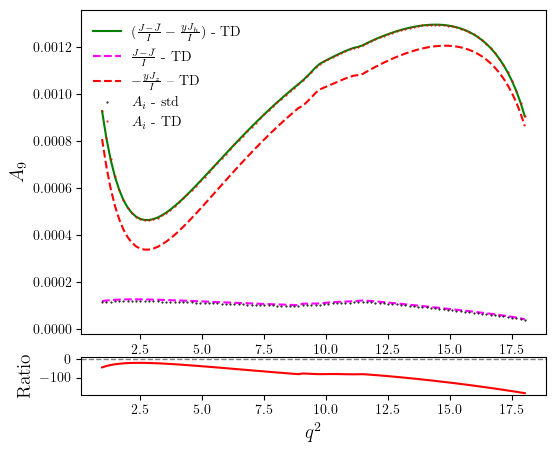

In [35]:
dGd2_ave_std = np.array([observables.BVll_obs(observables.dGdq2_ave, q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
dGd2_ave_td = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_ave_Bs, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
y = 0.0645
x = 26.79
#for num in ['1s','1c','2s','2c',3,4,5,'6s','6c',7,8,9]:
for num in [9]:
    sign = 1
    if num in [4, '6s', '6c', 7, 9]:
        sign = -1
    j_std, jbar_std  = [], []
    j_td, jbar_td, j_h_td, j_s_td   = [], [], [] ,[]

    for arr in js_std:
        j_std.append(arr[0][num])
        jbar_std.append(arr[1][num])
    for arr in js_td:
        j_td.append(arr[3][num])
        jbar_td.append(arr[4][num])
        j_h_td.append(arr[5][num])
        j_s_td.append(arr[6][num])
        
    Ai_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.A_experiment(J, J_bar, num), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    Ai_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    Wi_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.W_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    Hi_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.H_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    j_std, j_td, jbar_std, jbar_td = np.array(j_std),np.array(j_td),np.array(jbar_std),np.array(jbar_td)
    j_h_td, j_s_td = np.array(j_h_td),np.array(j_s_td)
    
    obs_j_std = sign * (j_std - jbar_std)/ dGd2_ave_std / 2.
    obs_j_td = sign * (j_td - jbar_td)/ dGd2_ave_td / (1+x**2) / 2.
    obs_s_td = sign *  -1 * x*(j_s_td)/ dGd2_ave_td / (1+x**2) / 2.

    obs_h_td = sign * -1 * y*(j_h_td)/ dGd2_ave_td / (1-y**2) / 2.
    obs_j_td_2 = sign *  (j_td - jbar_td)/ dGd2_ave_td / (1-y**2) / 2.

    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    
    #ax1.plot(q2_arr, obs_j_std, label=r'$\frac{J_i-\bar{J}_i}{d\Gamma/dq^2}$ - std', color='k')
    #ax1.plot(q2_arr, obs_j_td, label=r'$(\frac{J - \bar{J}}{I}) \frac{1-y^2}{1+x^2}$ - TD ', color='g', linestyle='dashed')
    #ax1.plot(q2_arr, obs_j_td_2, label=r'$(\frac{J - \bar{J}}{I})$ - TD ', color='b', linestyle='dashed')
    
    #ax1.plot(q2_arr, obs_j_td + obs_s_td, label=r'$(\frac{J - \bar{J}}{I} - \frac{x J_s}{I}) \frac{1-y^2}{1+x^2}$ - TD ', color='r')
    ax1.plot(q2_arr, obs_j_td_2 + obs_h_td, label=r'$(\frac{J - \bar{J}}{I} - \frac{y J_h}{I})$ - TD ', color='g')
    #ax1.plot(q2_arr, obs_j_td, label=r'$\frac{J - \bar{J}}{I} \frac{1-y^2}{1+x^2}$ - TD ', color='magenta', linestyle='dashed')
    ax1.plot(q2_arr, obs_j_td_2, label=r'$\frac{J - \bar{J}}{I}$ - TD ', color='magenta', linestyle='dashed')
    #ax1.plot(q2_arr, obs_s_td, label=r'$ - \frac{x J_z}{I} \frac{1-y^2}{1+x^2}$ -- TD ', color='orange', linestyle='dashed')
    ax1.plot(q2_arr, obs_h_td, label=r'$ - \frac{y J_z}{I}$ -- TD ', color='red', linestyle='dashed')

    ax1.errorbar(q2_arr, Ai_std, label=r'$A_i$ - std', color='k', fmt='.', markersize=1)
    ax1.errorbar(q2_arr, Ai_td, label=r'$A_i$ - TD', color='r', fmt='.', markersize=1)
   
    #ax1.errorbar(q2_arr, Wi_td, label=r'$W_i$ - TD', color='magenta', fmt='.', markersize=1)
    #ax1.errorbar(q2_arr, Hi_td, label=r'$H_i$ - TD', color='orange', fmt='.', markersize=1)
    #ax1.errorbar(q2_arr, Wi_td + Hi_td, label=r' - TD', color='orange', fmt='.', markersize=1)
    
    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel('$A_{'+str(num)+'}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = np.array(obs_j_td + obs_s_td) / np.array(obs_j_std)
    ax2.plot(q2_arr, ratio, label='Ratio (TD/std)', color='r')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

    plt.show()

### Obtain values for toy

In [ ]:
### Obtain values for toy

In [36]:
#q2_min, q2_max = 1.1, 6.    
#q2_min, q2_max = 1.1, 6.    
q2_min, q2_max = 6., 8.    
num_list = ['1s','1c','2s','2c',3,4,5,'6s','6c',7,8,9]

Ki_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.K_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}

Wi_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.W_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}

Hi_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.H_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}

Zi_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.Z_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}

Si_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}

Ai_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}

Si_std_dict = {num: flavio.physics.bdecays.bvll.observables.BVll_int_ratio(
        lambda J, J_bar: flavio.physics.bdecays.bvll.observables.S_experiment_num(J, J_bar, num),
        flavio.physics.bdecays.bvll.observables.SA_den, 
        q2_min, q2_max,  B, V, l, wc_obj, par_orig)()
           for num in num_list}
Ai_std_dict = {num: flavio.physics.bdecays.bvll.observables.BVll_int_ratio( 
        lambda J, J_bar: flavio.physics.bdecays.bvll.observables.A_experiment_num(J, J_bar, num),
        flavio.physics.bdecays.bvll.observables.SA_den, 
        q2_min, q2_max, B, V, l, wc_obj, par_orig)()
           for num in num_list}


/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/qcdf_interpolate.py:33: UserWarning: The QCDF corrections should not be trusted for q2 above 6 GeV^2
  warnings.warn("The QCDF corrections should not be trusted for q2 above 6 GeV^2")


In [37]:
print({f"K{ikey}": {"initial_value": ival, "min": -2.0, "max": 2.0 } for ikey, ival in Ki_dict.items()})
print({f"W{ikey}": {"initial_value": ival, "min": -2.0, "max": 2.0 } for ikey, ival in Wi_dict.items()})
print({f"H{ikey}": {"initial_value": ival, "min": -2.0, "max": 2.0 } for ikey, ival in Hi_dict.items()})
print({f"Z{ikey}": {"initial_value": ival, "min": -2.0, "max": 2.0 } for ikey, ival in Zi_dict.items()})


{'K1s': {'initial_value': 0.26695896410435677, 'min': -2.0, 'max': 2.0}, 'K1c': {'initial_value': 0.696802190620531, 'min': -2.0, 'max': 2.0}, 'K2s': {'initial_value': 0.08880388476823026, 'min': -2.0, 'max': 2.0}, 'K2c': {'initial_value': -0.6878685265174956, 'min': -2.0, 'max': 2.0}, 'K3': {'initial_value': -0.04582254113238522, 'min': -2.0, 'max': 2.0}, 'K4': {'initial_value': -0.27071344951423265, 'min': -2.0, 'max': 2.0}, 'K5': {'initial_value': -0.3975443403889841, 'min': -2.0, 'max': 2.0}, 'K6s': {'initial_value': 0.2901648656513666, 'min': -2.0, 'max': 2.0}, 'K6c': {'initial_value': 0, 'min': -2.0, 'max': 2.0}, 'K7': {'initial_value': -0.010316596218482956, 'min': -2.0, 'max': 2.0}, 'K8': {'initial_value': -0.004454615804607169, 'min': -2.0, 'max': 2.0}, 'K9': {'initial_value': -0.0009630908332561676, 'min': -2.0, 'max': 2.0}}
{'W1s': {'initial_value': -1.4402705336566853e-05, 'min': -2.0, 'max': 2.0}, 'W1c': {'initial_value': 0.0009876615312180007, 'min': -2.0, 'max': 2.0}, 'W

/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/qcdf_interpolate.py:33: UserWarning: The QCDF corrections should not be trusted for q2 above 6 GeV^2
  warnings.warn("The QCDF corrections should not be trusted for q2 above 6 GeV^2")
/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:74: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:83: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")


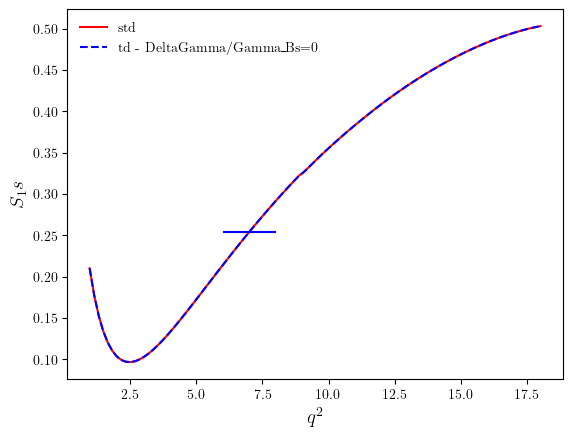

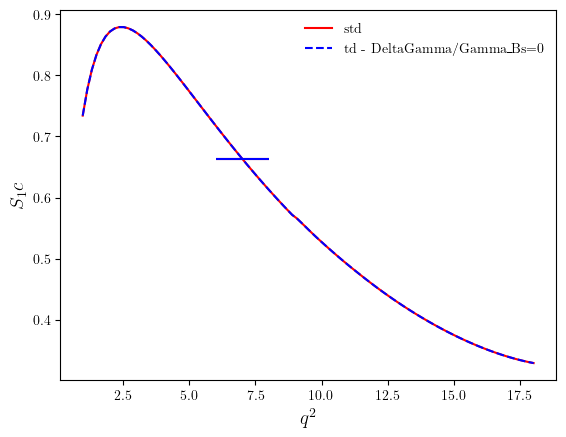

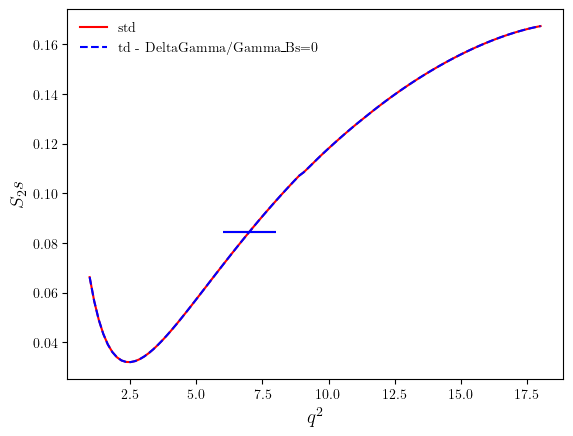

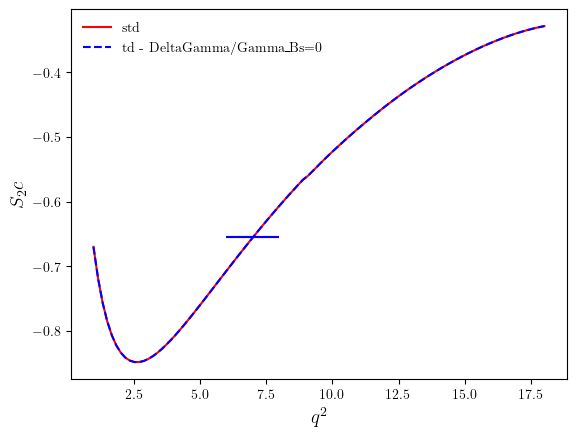

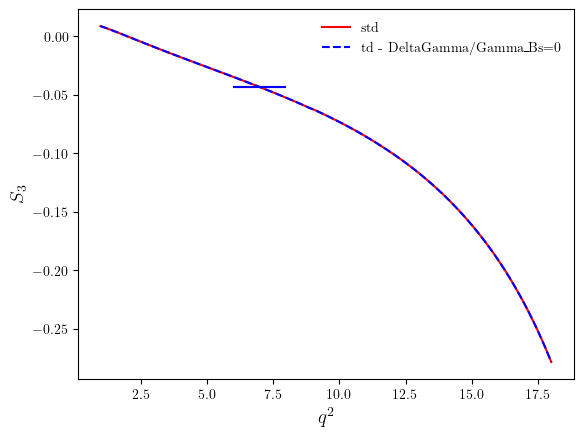

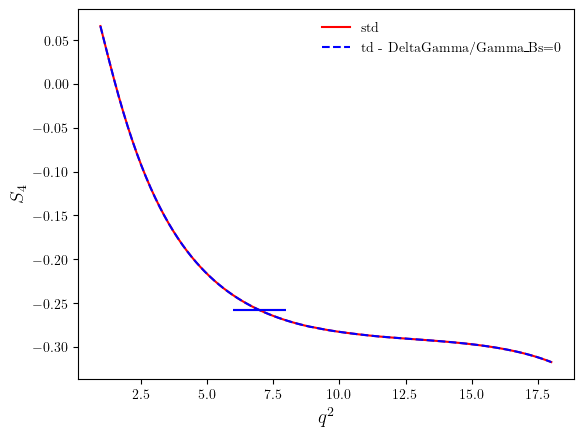

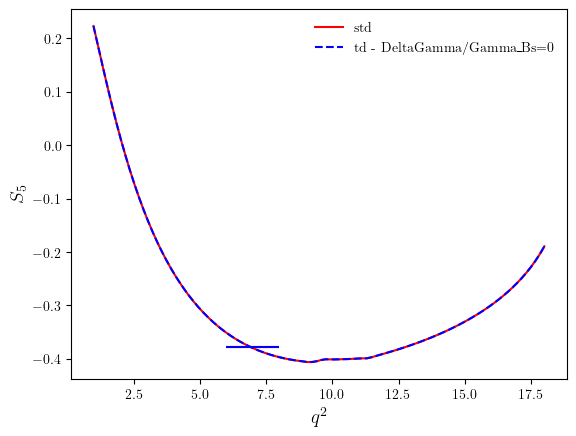

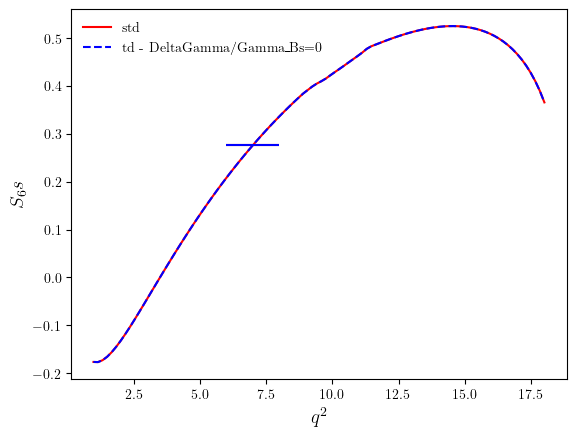

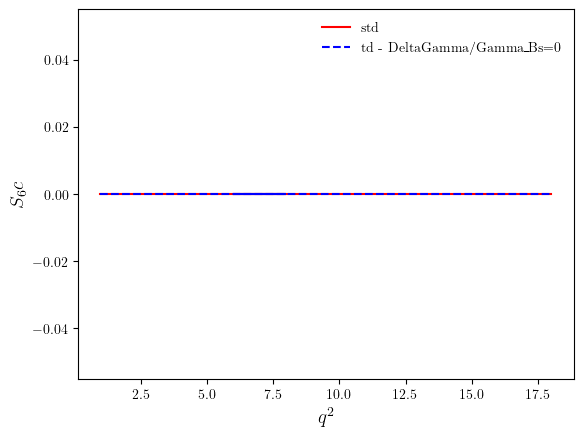

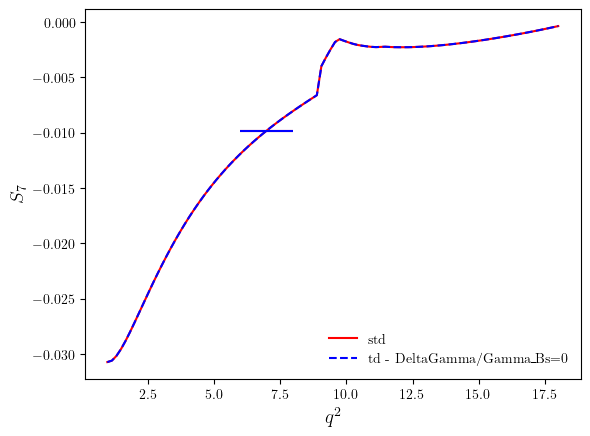

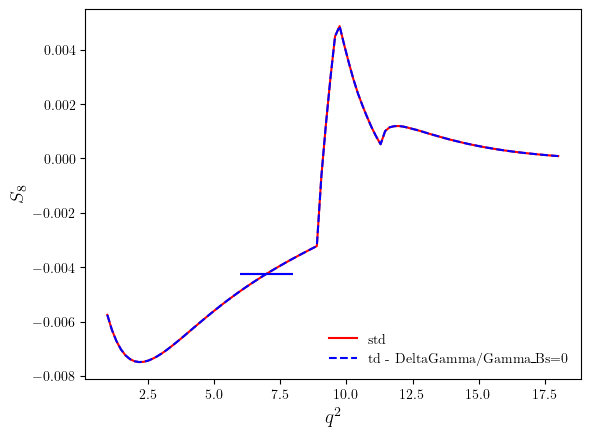

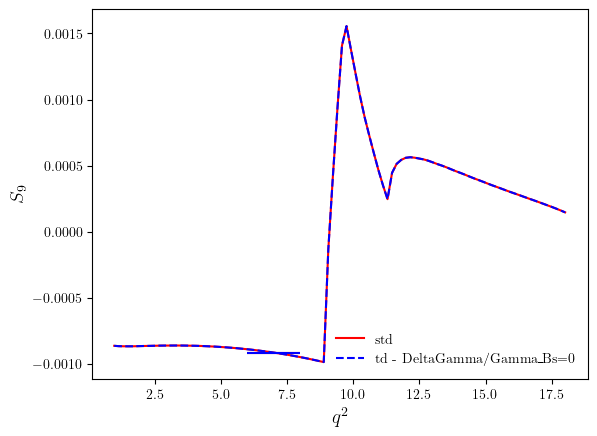

In [38]:
Si_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_y0, q2_min, q2_max)
           for num in num_list}

for iobs in ['1s','1c','2s','2c',3,4,5,'6s','6c',7,8,9]:
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.S_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_y0)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_y0, B, V, l) for q2 in q2_arr])

    plt.close('all')
    plt.plot(q2_arr, FL_std, label='std', color='r')
    plt.plot(q2_arr, FL_td, label='td - DeltaGamma/Gamma_Bs=0', color='b', linestyle='dashed')
    plt.legend(frameon=False)
    plt.xlabel(r'$q^2$')
    plt.ylabel(f'$S_{iobs}$')
    
    c = np.array([(q2_max+q2_min)/2.])
    w = np.array([(q2_max-q2_min)/2.])
    plt.errorbar(c, Si_std_dict[iobs], xerr=w, color='r')
    plt.errorbar(c, Si_dict[iobs], xerr=w, color='b')
    #plt.vlines([1.1,6])
    plt.show()

In [39]:
y = 0.0645
x = 26.79
Si_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}
Si_std_dict = {num: flavio.physics.bdecays.bvll.observables.BVll_int_ratio(
        lambda J, J_bar: flavio.physics.bdecays.bvll.observables.S_experiment_num(J, J_bar, num),
        flavio.physics.bdecays.bvll.observables.SA_den, 
        q2_min, q2_max,  B, V, l, wc_obj, par_orig)()
           for num in num_list}

Ki_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.K_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}

Wi_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.W_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}

Hi_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.H_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}

Zi_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.Z_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}

for iobs in ['1s','1c','2s','2c',3,4,5,'6s','6c',7,8,9]:
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.S_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, J, J_bar, J_h,  J_s: observables_bs.S_experiment_Bs(y, x, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    plt.close('all')
    plt.plot(q2_arr, FL_std, label='std', color='r')
    plt.plot(q2_arr, FL_td, label='td - DeltaGamma/Gamma_Bs=0', color='b', linestyle='dashed')
    plt.xlabel(r'$q^2$')
    plt.ylabel(f'$S_{iobs}$')
    
    c = np.array([(q2_max+q2_min)/2.])
    w = np.array([(q2_max-q2_min)/2.])
    plt.errorbar(c, Si_std_dict[iobs], xerr=w, color='r', label='int STD [1.1, 6]', fmt='*')
    plt.errorbar(c, Si_dict[iobs], xerr=w, color='b', label='int TD [1.1, 6]', fmt='^')
    plt.errorbar(c, Ki_dict[iobs] - y*Hi_dict[iobs], xerr=w, color='g', label='int K - y*H [1.1, 6]', fmt='.')
    #plt.errorbar(c, Ki_dict[iobs] - x*Zi_dict[iobs], xerr=w, color='magenta', label='int K - x*Z [1.1, 6]', fmt='.')
    #plt.errorbar(c, (Ki_dict[iobs] - x*Zi_dict[iobs])*(1-y**2)/(1+x**2), xerr=w, color='purple', label='int (K - x*Z)(1-y2)/(1+x2) [1.1, 6]', fmt='.')
    
    plt.legend(frameon=False)

    #plt.vlines([1.1,6])
    plt.show()

TypeError: <listcomp>.<lambda>() takes 6 positional arguments but 7 were given

In [40]:
Ai_tdi_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}
Ai_std_dict = {num: flavio.physics.bdecays.bvll.observables.BVll_int_ratio(
        lambda J, J_bar: flavio.physics.bdecays.bvll.observables.A_experiment_num(J, J_bar, num),
        flavio.physics.bdecays.bvll.observables.SA_den, 
        q2_min, q2_max,  B, V, l, wc_obj, par_orig)()
           for num in num_list}

Ki_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.K_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}

Wi_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.W_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}

Hi_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.H_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}

Zi_dict = {num: observables_bs.bsvll_obs_int_ratio_func( 
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.Z_experiment_num_Bs(y, x, gamma, J, J_bar, J_h, J_s, num),
           lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.SA_den_Bs(y, x, gamma, J, J_bar, J_h, J_s),
           B, V, l)(wc_obj, par_orig, q2_min, q2_max)
           for num in num_list}

for iobs in ['1s','1c','2s','2c',3,4,5,'6s','6c',7,8,9]:
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.A_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, J, J_bar, J_h,  J_s: observables_bs.A_experiment_Bs(y, x, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    plt.close('all')
    plt.plot(q2_arr, FL_std, label='std', color='r')
    plt.plot(q2_arr, FL_td, label='td - DeltaGamma/Gamma_Bs=0', color='b', linestyle='dashed')
    plt.xlabel(r'$q^2$')
    plt.ylabel(f'$A_{iobs}$')
    
    c = np.array([(q2_max+q2_min)/2.])
    w = np.array([(q2_max-q2_min)/2.])
    plt.errorbar(c, Ai_std_dict[iobs], xerr=w, color='r', label='int STD [1.1, 6]', fmt='*')
    plt.errorbar(c, Ai_dict[iobs], xerr=w, color='b', label='int TD [1.1, 6]', fmt='^')
    plt.errorbar(c, Wi_dict[iobs] - y*Hi_dict[iobs], xerr=w, color='g', label='int W - y*H [1.1, 6]', fmt='.')
    #plt.errorbar(c, Wi_dict[iobs] - x*Zi_dict[iobs], xerr=w, color='magenta', label='int W - x*Z [1.1, 6]', fmt='.')
    plt.errorbar(c, (Wi_dict[iobs] - x*Zi_dict[iobs])*(1-y**2)/(1+x**2), xerr=w, color='purple', label='int (W - x*Z)(1-y2)/(1+x2) [1.1, 6]', fmt='.')
    
    plt.legend(frameon=False)

    #plt.vlines([1.1,6])
    plt.show()

/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/qcdf_interpolate.py:33: UserWarning: The QCDF corrections should not be trusted for q2 above 6 GeV^2
  warnings.warn("The QCDF corrections should not be trusted for q2 above 6 GeV^2")


TypeError: <listcomp>.<lambda>() takes 6 positional arguments but 7 were given

In [ ]:
Si_dict[3]()


In [ ]:
for num in ['1s','1c','2s','2c',3,4,5,'6s','6c',7,8,9]:
    print("{}: {}".format(num, Si_dict[num] - Si_dict[num] +y*Hi_dict[num]))    
    print("{}: {} - {}".format(num, Si_dict[num],  Si_dict[num] +y*Hi_dict[num]))

In [ ]:
Si_dict

In [ ]:
Wi_dict

In [ ]:
Hi_dict

### Check constraints

In [41]:
q2=10
Ki_dict = {num: observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.K_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l)
           for num in num_list}
Hi_dict = {num: observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.H_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l)
           for num in num_list}

/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:74: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:83: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")


In [42]:
Si_std_dict = {num: observables.BVll_obs( lambda J, J_bar: observables.S_experiment(J, J_bar, num), q2, B, V, l, wc_obj, par_orig)()
           for num in num_list}
Si_td_dict = {num: observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l)
           for num in num_list}
    

/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:74: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")
/Users/mactzeni/Physics/Work/Analysis/bstophimumu-td-sensitivity/analysis/flavio/flavio/physics/bdecays/bvll/amplitudes.py:83: UserWarning: The predictions in the region of narrow charmonium resonances are not meaningful
  warnings.warn("The predictions in the region of narrow charmonium resonances are not meaningful")


In [ ]:
print(Si_std_dict['2c']+Si_std_dict['1c'])
#assert(Hi_dict['2c']+Hi_dict['1c'] < 1e-9)
print(Si_std_dict['2s']-Si_std_dict['1s']/3)
#assert(Hi_dict['2s']-Hi_dict['1s']/3 < 1e-9)
print(3/4*(2*Si_std_dict['1s']+Si_std_dict['1c'])-1/4*(2*Si_std_dict['2s']+Si_std_dict['2c'])-1)


print(Si_td_dict['2c']+Si_td_dict['1c'])
#assert(Hi_dict['2c']+Hi_dict['1c'] < 1e-9)
print(Si_td_dict['2s']-Si_td_dict['1s']/3)
#assert(Hi_dict['2s']-Hi_dict['1s']/3 < 1e-9)
print(3/4*(2*Si_td_dict['1s']+Si_td_dict['1c'])-1/4*(2*Si_td_dict['2s']+Si_td_dict['2c'])-1)



In [ ]:
print(Hi_dict['2c']+Hi_dict['1c'])
#assert(Hi_dict['2c']+Hi_dict['1c'] < 1e-9)
print(Hi_dict['2s']-Hi_dict['1s']/3)
#assert(Hi_dict['2s']-Hi_dict['1s']/3 < 1e-9)

print(Ki_dict['2c']+Ki_dict['1c'])
#assert(Hi_dict['2c']+Hi_dict['1c'] < 1e-9)
print(Ki_dict['2s']-Ki_dict['1s']/3)
#assert(Hi_dict['2s']-Hi_dict['1s']/3 < 1e-9)

print( 3/4*(2*(Ki_dict['1s'] + Hi_dict['1s'])+ (Ki_dict['1c'] + Hi_dict['1c']))
      -1/4*(2*(Ki_dict['2s'] + Hi_dict['2s'])+ (Ki_dict['2c'] + Hi_dict['2c']))
      -1)

print( 4/3*(Ki_dict['1s'] + Hi_dict['1s'])+
         + (Ki_dict['1c'] + Hi_dict['1c'])
      -1)


In [ ]:
# normalization condition looks good, however the approximations seem a bit worse than I would have naively expected

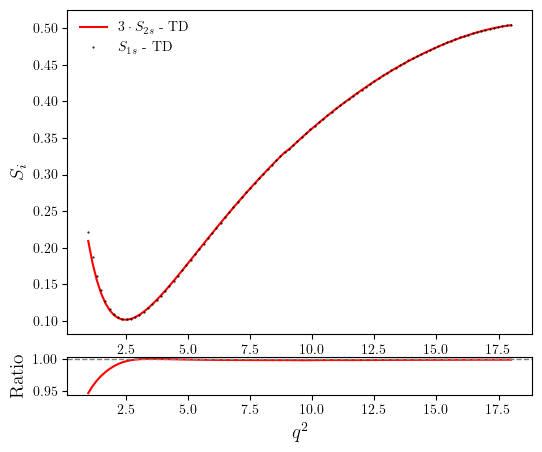

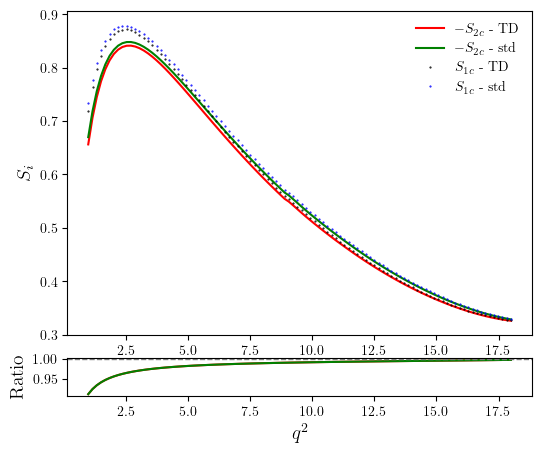

In [44]:
dGd2_ave_std = np.array([observables.BVll_obs(observables.dGdq2_ave, q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
dGd2_ave_td = np.array([observables_bs.bsvll_obs(observables_bs.dGdq2_ave_Bs, q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
y = 0.0645
Si_std_dict, Si_td_dict = {}, {}
Ki_std_dict, Hi_td_dict = {}, {}

for num in ['1s','1c','2s','2c',3,4,5,'6s','6c',7,8,9]:
    sign = 1
    if num in [4, '6s', '6c', 7, 9]:
        sign = -1
    j_std, jbar_std  = [], []
    j_td, jbar_td, j_h_td, j_s_td   = [], [], [] ,[]

    for arr in js_std:
        j_std.append(arr[0][num])
        jbar_std.append(arr[1][num])
    for arr in js_td:
        j_td.append(arr[3][num])
        jbar_td.append(arr[4][num])
        j_h_td.append(arr[5][num])
        j_s_td.append(arr[6][num])
    
    Si_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.S_experiment(J, J_bar, num), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    Si_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    
    Ki_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.K_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    Hi_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.H_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, num), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    Si_std_dict[num] = Si_std
    Si_td_dict[num] = Si_td
    
    Ki_std_dict[num] = Ki_td
    Hi_td_dict[num] = Hi_td
    
    
# Main plot
plt.close('all')
fig = plt.figure(figsize=figsize)
gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

# Main plot
ax1 = fig.add_subplot(gs[0:2, 0])

ax1.errorbar(q2_arr, Si_td_dict['1s'], label=r'$S_{1s}$ - TD', color='k', fmt='.', markersize=1)
ax1.plot(q2_arr, 3*Si_td_dict['2s'], label=r'$3\cdot S_{2s}$ - TD', color='r')
ax1.legend(frameon=False)
ax1.set_xlabel(r'$q^2$')
ax1.set_ylabel(f'$S_i$')

# Ratio plot
ax2 = fig.add_subplot(gs[2, 0])
ratio = 3*Si_td_dict['2s']/Si_td_dict['1s']
ax2.plot(q2_arr, ratio, label='Ratio (TD/std)', color='r')
ax2.set_xlabel(r'$q^2$')
ax2.set_ylabel('Ratio')
ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

plt.show()

# Main plot
plt.close('all')
fig = plt.figure(figsize=figsize)
gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

# Main plot
ax1 = fig.add_subplot(gs[0:2, 0])

ax1.errorbar(q2_arr, Si_td_dict['1c'], label=r'$S_{1c}$ - TD', color='k', fmt='.', markersize=1)
ax1.plot(q2_arr, -Si_td_dict['2c'], label=r'$-S_{2c}$ - TD', color='r')
ax1.errorbar(q2_arr, Si_std_dict['1c'], label=r'$S_{1c}$ - std', color='b', fmt='.', markersize=1)
ax1.plot(q2_arr, -Si_std_dict['2c'], label=r'$-S_{2c}$ - std', color='g')
ax1.legend(frameon=False)
ax1.set_xlabel(r'$q^2$')
ax1.set_ylabel(f'$S_i$')

# Ratio plot
ax2 = fig.add_subplot(gs[2, 0])
ratio = -Si_td_dict['2c']/Si_td_dict['1c']
ratio_std = -Si_std_dict['2c']/Si_std_dict['1c']
ax2.plot(q2_arr, ratio, label='Ratio (TD/std)', color='r')
ax2.plot(q2_arr, ratio_std, label='Ratio (TD/std)', color='g')
ax2.set_xlabel(r'$q^2$')
ax2.set_ylabel('Ratio')
ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference

plt.show()

### Check std flavio vs new change

In [ ]:
#start studying it in an unbinned way using test_bvll as an example
q2_min, q2_max = 0.98, 18
npoints = 100
q2_arr = np.linspace(q2_min, q2_max, npoints)
figsize=(6, 5)

tarray = np.linspace(0, 16*np.pi/(gamma*x), 9)

for iobs in [3, 4, 7,5, '6s', 8, 9]:
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.S_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    FL_original_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_original_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    #FL_td_int_t = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_int_t_Bs(tmin, tmax, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    #FL_td_Bsbar = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_experiment_int_t_Bs(tmin_Bsbar, tmax_Bsbar, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    ax1.plot(q2_arr, FL_std, label='std', color='r')
    ax1.plot(q2_arr, FL_td, label='td ', color='b')
    ax1.plot(q2_arr, FL_original_td, label=f'original S{iobs}', color='k', linestyle='dashed')

    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel(f'$S_{iobs}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = FL_td / FL_std
    ax2.plot(q2_arr, ratio, label='Ratio (std/td)', color='g')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference
    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.show()

for iobs in [3, 4, 7, 5, '6s', 8, 9]:
    FL_std = np.array([observables.BVll_obs(lambda J, J_bar: observables.A_experiment(J, J_bar, iobs), q2, B, V, l, wc_obj, par_orig)() for q2 in q2_arr])
    FL_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    FL_original_td = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.S_original_experiment_Bs(y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    #FL_td_int_t = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_int_t_Bs(tmin, tmax, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])
    #FL_td_Bsbar = np.array([observables_bs.bsvll_obs( lambda y, x, gamma, J, J_bar, J_h,  J_s: observables_bs.A_experiment_int_t_Bs(tmin_Bsbar, tmax_Bsbar, y, x, gamma, J, J_bar, J_h, J_s, iobs), q2, wc_obj, par_orig, B, V, l) for q2 in q2_arr])

    plt.close('all')
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 0.5])

    # Main plot
    ax1 = fig.add_subplot(gs[0:2, 0])
    ax1.plot(q2_arr, FL_std, label='std', color='r')
    ax1.plot(q2_arr, FL_td, label='td', color='b')
    ax1.plot(q2_arr, FL_original_td, label=f'original S{iobs}', color='k', linestyle='dashed')

    ax1.legend(frameon=False)
    ax1.set_xlabel(r'$q^2$')
    ax1.set_ylabel(f'$A_{iobs}$')

    # Ratio plot
    ax2 = fig.add_subplot(gs[2, 0])
    ratio = FL_td / FL_std
    ax2.plot(q2_arr, ratio, label='Ratio (std/td)', color='g')
    ax2.set_xlabel(r'$q^2$')
    ax2.set_ylabel('Ratio')
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)  # Horizontal line at y=1 for reference
    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.show()
    